In [ ]:
# Standard library
import json
import os
import random
import re
import sqlite3
from collections import defaultdict
from pathlib import Path


# Scientific / data stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Utilities
import joblib
from joblib import dump, load
from tqdm.auto import tqdm


# Optimization / tuning
import optuna


# PyTorch
import torch
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau


# PyTorch Geometric
from torch_geometric.data import HeteroData
from torch_geometric.nn import HGTConv, Linear
from torch_geometric.transforms import ToUndirected


# XGBoost
from xgboost import XGBClassifier, callback


# Scikit-learn – preprocessing & pipelines
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer


# Scikit-learn – models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest


# Scikit-learn – model selection
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    train_test_split,
)


# Scikit-learn – metrics
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)

# NLP / Embeddings
from sentence_transformers import SentenceTransformer

# Encoders
import category_encoders as ce


# Data generation / testing
from faker import Faker


RANDOM_SEED = 2024
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
Faker.seed(RANDOM_SEED)


In [3]:
Base_Datos = Path("Base_Datos")
split_path = Path("Train_Split/train_split.joblib")
modelo_path = Path("Modelos/modelo.joblib")
nlp_model_path = Path("Modelos_nlp/modelo_nlp.joblib")
gnn_model_path = Path("Modelos_gnn/modelo_gnn.joblib")
xgboost_model_path = Path("Modelos_xgboost/modelo_xgb.joblib")

for path in [
    split_path,
    modelo_path,
    nlp_model_path,
    gnn_model_path,
    xgboost_model_path
]:
    path.parent.mkdir(parents=True, exist_ok=True)
Base_Datos.mkdir(parents=True, exist_ok=True)

In [4]:

EMBED_MODEL_NAME = 'LaBSE' #'paraphrase-multilingual-mpnet-base-v2'  #"all-MiniLM-L6-v2" # "LaBSE" # "all-MiniLM-L6-v2"  'hiiamsid/sentence_similarity_spanish_sts'
model = SentenceTransformer(EMBED_MODEL_NAME)
COLS_CATEGORICAS = ['codigos_cie', 'codigos_cpt', 'doctor_tratante']
COLS_NUMERICAS = ['dias_invalidez', 'monto_reclamado']
COLS_DROP = ['numero_poliza', 'nombre', 'fecha_inicio_poliza', 'fecha_reclamo']
COLS_SCORE = ['semantic_score']

# Generacion de Base de Datos Sinteticos

## Plantilla descripcion o reclamo del siniestro + Creacion de base con CIE/CPT


In [5]:
num_registros = 1000
NUM_DOCTORES_UNICOS = 100  # Definir cuántos doctores únicos queremos simular
NUM_NOMBRES_UNICOS = 200  # Definir cuántos nombres únicos queremos simular
fake = Faker('es_ES')
catalogo_doctores = [fake.name() for _ in range(NUM_DOCTORES_UNICOS)]
catalogos_nombres = [fake.name() for _ in range(NUM_NOMBRES_UNICOS)]


plantillas_descripcion = [
    "Paciente {sexo}, {edad} años. Diagnóstico: {diagnostico} ({codigo_cie}). Procedimiento: {procedimiento} (CPT {codigo_cpt}). Monto reclamado: ${monto_reclamado}. Incapacidad: {dias_invalidez} días.",
    "Se atendió a paciente {sexo} de {edad} años con diagnóstico de {diagnostico} ({codigo_cie}). Se realizó {procedimiento} con código CPT {codigo_cpt}. Monto reclamado: ${monto_reclamado}. Incapacidad: {dias_invalidez} días.",
    "Paciente {sexo}, {edad} años, presentó {diagnostico} ({codigo_cie}). Se le realizó {procedimiento} (CPT {codigo_cpt}). Monto reclamado: ${monto_reclamado}. Incapacidad: {dias_invalidez} días."
]

# Definir datos médicos organizados por CATEGORÍAS
# Cada categoría tiene diagnósticos relacionados con sus procedimientos apropiados
categorias_medicas = {
    "respiratorio_leve": {
        "diagnosticos": [
            ("Resfriado común", "J00"),
            ("Gripe", "J11"),
            ("Bronquitis aguda", "J20"),
        ],
        "procedimientos": [
            ("Consulta médica general", "99213"),
            ("Consulta de seguimiento establecida, nivel moderado", "99214"),
            ("Radiografía de tórax, 2 vistas", "71046"),
            ("Hemograma completo con recuento diferencial", "85025"),
        ],
        "monto_rango": (50000, 400000),
        "dias_invalidez_rango": (0, 7)
    },
    "respiratorio_grave": {
        "diagnosticos": [
            ("Neumonía", "J18"),
            ("Asma", "J45"),
            ("Enfermedad pulmonar obstructiva crónica (EPOC)", "J44"),
            ("Embolia pulmonar", "I26"),
            ("Pleuresía", "J90"),
            ("Neumotórax", "J93"),
        ],
        "procedimientos": [
            ("Visita hospitalaria de emergencia con pruebas de laboratorio complejas", "99285"),
            ("Radiografía de tórax, 2 vistas", "71046"),
            ("Tomografía computarizada de abdomen con contraste", "74160"),
            ("Hemograma completo con recuento diferencial", "85025"),
            ("Electrocardiograma completo", "93000"),
            ("Panel metabólico completo", "80053"),
        ],
        "monto_rango": (800000, 3500000),
        "dias_invalidez_rango": (3, 15)
    },
    "cardiovascular": {
        "diagnosticos": [
            ("Hipertensión", "I10"),
        ],
        "procedimientos": [
            ("Consulta médica general", "99213"),
            ("Consulta de seguimiento establecida, nivel moderado", "99214"),
            ("Electrocardiograma completo", "93000"),
            ("Prueba de esfuerzo cardiovascular", "93015"),
            ("Prueba de glucosa en sangre", "82947"),
            ("Panel metabólico completo", "80053"),
        ],
        "monto_rango": (100000, 800000),
        "dias_invalidez_rango": (0, 3)
    },
    "endocrino": {
        "diagnosticos": [
            ("Diabetes tipo 2", "E11"),
        ],
        "procedimientos": [
            ("Consulta médica general", "99213"),
            ("Consulta de seguimiento establecida, nivel moderado", "99214"),
            ("Prueba de glucosa en sangre", "82947"),
            ("Panel metabólico completo", "80053"),
            ("Hemograma completo con recuento diferencial", "85025"),
        ],
        "monto_rango": (80000, 600000),
        "dias_invalidez_rango": (0, 5)
    },
    "traumatologia_leve": {
        "diagnosticos": [
            ("Esguinces y distensiones", "S93.4"),
            ("Dolor de espalda", "M54"),
        ],
        "procedimientos": [
            ("Consulta médica general", "99213"),
            ("Radiografía de columna lumbar", "72110"),
            ("Fisioterapia, evaluación inicial", "97161"),
            ("Sutura simple de herida superficial", "12001"),
        ],
        "monto_rango": (100000, 600000),
        "dias_invalidez_rango": (0, 7)
    },
    "traumatologia_grave": {
        "diagnosticos": [
            ("Fractura de tobillo", "S82.5"),
            ("Fractura de cadera", "S72.0"),
            ("Fractura de muñeca", "S62.0"),
            ("Lesión de ligamento cruzado anterior", "S83.5"),
            ("Lesión de menisco", "S83.2"),
        ],
        "procedimientos": [
            ("Visita hospitalaria de emergencia con pruebas de laboratorio complejas", "99285"),
            ("Radiografía de columna lumbar", "72110"),
            ("Resonancia magnética de cerebro sin contraste", "70551"),
            ("Tomografía computarizada de abdomen con contraste", "74160"),
            ("Consulta de especialista, problema complejo", "99244"),
            ("Sutura simple de herida superficial", "12001"),
        ],
        "monto_rango": (1500000, 8000000),
        "dias_invalidez_rango": (7, 15)
    },
    "articular": {
        "diagnosticos": [
            ("Artritis reumatoide", "M06"),
            ("Osteoartritis de rodilla", "M17"),
            ("Osteoartritis de cadera", "M16"),
            ("Osteoporosis", "M81"),
        ],
        "procedimientos": [
            ("Consulta médica general", "99213"),
            ("Consulta de seguimiento establecida, nivel moderado", "99214"),
            ("Inyección intraarticular de rodilla", "20610"),
            ("Fisioterapia, evaluación inicial", "97161"),
            ("Radiografía de columna lumbar", "72110"),
            ("Hemograma completo con recuento diferencial", "85025"),
        ],
        "monto_rango": (150000, 1200000),
        "dias_invalidez_rango": (0, 10)
    },
    "oftalmologico": {
        "diagnosticos": [
            ("Catarata", "H25"),
            ("Glaucoma", "H40"),
            ("Hipertensión ocular", "H40.0"),
        ],
        "procedimientos": [
            ("Consulta de especialista, problema complejo", "99244"),
            ("Cirugía de cataratas con implante de lente", "66984"),
        ],
        "monto_rango": (500000, 4000000),
        "dias_invalidez_rango": (0, 7)
    },
    "digestivo_leve": {
        "diagnosticos": [
            ("Gastroenteritis", "A09"),
            ("Caries dental", "K02"),
            ("Gingivitis", "K05"),
            ("Periodontitis", "K05.3"),
        ],
        "procedimientos": [
            ("Consulta médica general", "99213"),
            ("Consulta de seguimiento establecida, nivel moderado", "99214"),
            ("Panel metabólico completo", "80053"),
        ],
        "monto_rango": (50000, 400000),
        "dias_invalidez_rango": (0, 5)
    },
    "digestivo_grave": {
        "diagnosticos": [
            ("Úlcera gástrica", "K25"),
            ("Colitis ulcerosa", "K51"),
            ("Enfermedad de Crohn", "K50"),
        ],
        "procedimientos": [
            ("Consulta de seguimiento establecida, nivel moderado", "99214"),
            ("Endoscopia digestiva alta con biopsia", "43239"),
            ("Colonoscopia con biopsia", "45380"),
            ("Tomografía computarizada de abdomen con contraste", "74160"),
            ("Hemograma completo con recuento diferencial", "85025"),
        ],
        "monto_rango": (800000, 3500000),
        "dias_invalidez_rango": (3, 12)
    },
    "quirurgico": {
        "diagnosticos": [
            ("Úlcera gástrica", "K25"),
        ],
        "procedimientos": [
            ("Cirugía de apendicitis", "44970"),
            ("Cirugía de vesícula biliar laparoscópica", "47562"),
            ("Visita hospitalaria de emergencia con pruebas de laboratorio complejas", "99285"),
            ("Tomografía computarizada de abdomen con contraste", "74160"),
        ],
        "monto_rango": (2500000, 8000000),
        "dias_invalidez_rango": (7, 15)
    },
    "urologico": {
        "diagnosticos": [
            ("Insuficiencia renal crónica", "N18"),
            ("Cistitis", "N30"),
            ("Prostatitis", "N41"),
        ],
        "procedimientos": [
            ("Consulta médica general", "99213"),
            ("Consulta de seguimiento establecida, nivel moderado", "99214"),
            ("Panel metabólico completo", "80053"),
            ("Hemograma completo con recuento diferencial", "85025"),
        ],
        "monto_rango": (150000, 1500000),
        "dias_invalidez_rango": (0, 7)
    },
    "oncologico": {
        "diagnosticos": [
            ("Cáncer de mama", "C50"),
            ("Cáncer de próstata", "C61"),
            ("Cáncer de colon", "C18"),
            ("Cáncer de pulmón", "C34"),
            ("Cáncer de pulmón de células no pequeñas", "C34.9"),
            ("Cáncer de pulmón de células pequeñas", "C34.1"),
        ],
        "procedimientos": [
            ("Consulta de especialista, problema complejo", "99244"),
            ("Mamografía bilateral de screening", "77067"),
            ("Colonoscopia con biopsia", "45380"),
            ("Biopsia de piel con cierre simple", "11102"),
            ("Tomografía computarizada de abdomen con contraste", "74160"),
            ("Radiografía de tórax, 2 vistas", "71046"),
        ],
        "monto_rango": (1500000, 10000000),
        "dias_invalidez_rango": (5, 15)
    },
    "psiquiatrico": {
        "diagnosticos": [
            ("Depresión", "F32"),
            ("Ansiedad", "F41"),
            ("Trastorno bipolar", "F31"),
            ("Esquizofrenia", "F20"),
        ],
        "procedimientos": [
            ("Consulta médica general", "99213"),
            ("Consulta de seguimiento establecida, nivel moderado", "99214"),
            ("Consulta de especialista, problema complejo", "99244"),
        ],
        "monto_rango": (80000, 800000),
        "dias_invalidez_rango": (0, 10)
    },
    "ocupacional": {
        "diagnosticos": [
            ("Asbestosis", "J61"),
            ("Silicosis", "J62"),
        ],
        "procedimientos": [
            ("Consulta de especialista, problema complejo", "99244"),
            ("Radiografía de tórax, 2 vistas", "71046"),
            ("Tomografía computarizada de abdomen con contraste", "74160"),
        ],
        "monto_rango": (600000, 3000000),
        "dias_invalidez_rango": (5, 15)
    },
    "infeccioso": {
        "diagnosticos": [
            ("Tuberculosis pulmonar", "A15"),
        ],
        "procedimientos": [
            ("Consulta de seguimiento establecida, nivel moderado", "99214"),
            ("Radiografía de tórax, 2 vistas", "71046"),
            ("Hemograma completo con recuento diferencial", "85025"),
        ],
        "monto_rango": (400000, 2000000),
        "dias_invalidez_rango": (7, 15)
    },
    "prenatal": {
        "diagnosticos": [
            ("Resfriado común", "J00"),
        ],
        "procedimientos": [
            ("Ultrasonido obstétrico completo", "76805"),
            ("Consulta médica general", "99213"),
        ],
        "monto_rango": (100000, 600000),
        "dias_invalidez_rango": (0, 3)
    },
    "preventivo": {
        "diagnosticos": [
            ("Hipertensión", "I10"),
            ("Diabetes tipo 2", "E11"),
        ],
        "procedimientos": [
            ("Vacuna contra influenza", "90686"),
            ("Consulta médica general", "99213"),
        ],
        "monto_rango": (30000, 250000),
        "dias_invalidez_rango": (0, 0)
    }
}

# Función para generar un registro coherente
def generar_registro_coherente():
    # Seleccionar una categoría médica aleatoria
    categoria = random.choice(list(categorias_medicas.keys()))
    categoria_data = categorias_medicas[categoria]

    # Seleccionar diagnóstico y procedimiento de la misma categoría
    diagnostico, codigo_cie = random.choice(categoria_data["diagnosticos"])
    procedimiento, codigo_cpt = random.choice(categoria_data["procedimientos"])

    # Generar datos del paciente
    sexo = random.choice(["masculino", "femenino"])
    edad = fake.random_int(min=18, max=80)

    # Generar monto y días de invalidez según la categoría
    monto_min, monto_max = categoria_data["monto_rango"]
    dias_min, dias_max = categoria_data["dias_invalidez_rango"]

    monto_reclamado = round(random.uniform(monto_min, monto_max),0)
    dias_invalidez = random.randint(dias_min, dias_max)

    # Generar fechas
    fecha_inicio = fake.date_between(start_date='-5y', end_date='-6m')
    fecha_reclamo = fake.date_between(start_date=fecha_inicio, end_date='today')

    # Remplazar valores en la plantilla de texto
    descripcion = random.choice(plantillas_descripcion).format(
        sexo=sexo,
        edad=edad,
        diagnostico=diagnostico,
        codigo_cie=codigo_cie,
        procedimiento=procedimiento,
        codigo_cpt=codigo_cpt,
        monto_reclamado=monto_reclamado,
        dias_invalidez=dias_invalidez
    )

    return {
        'numero_poliza': fake.random_int(min=10000, max=99999),
        'nombre': random.choice(catalogos_nombres),
        'codigos_cie': codigo_cie,
        'codigos_cpt': codigo_cpt,
        'fecha_inicio_poliza': fecha_inicio,
        'fecha_reclamo': fecha_reclamo,
        'descripcion': descripcion,
        'dias_invalidez': dias_invalidez,
        'monto_reclamado': monto_reclamado,
        'doctor_tratante': random.choice(catalogo_doctores),
        'fraude_label': 0
    }

# Generar registros

data_legitima = []

for _ in range(num_registros):
    data_legitima.append(generar_registro_coherente())

df_fraude = pd.DataFrame(data_legitima)

# ---Configuración ---
FRAUDE_PROPORCION = 0.08  # 5% - 10%  (caso real)
N_FILAS = len(df_fraude)
N_FRAUDE = int(N_FILAS * FRAUDE_PROPORCION)


# Asegurarse de que las fechas son datetime
df_fraude['fecha_inicio_poliza'] = pd.to_datetime(df_fraude['fecha_inicio_poliza'])
df_fraude['fecha_reclamo'] = pd.to_datetime(df_fraude['fecha_reclamo'])

#  IMPORTANTE: Inicializar fraude_label en 0 PRIMERO ---
df_fraude['fraude_label'] = 0

# Códigos CIE/CPT raros o costosos (poco frecuentes)
# Códigos ICD-10 "raros" / sospechosos (ejemplos para generar casos poco comunes)
codigos_cie_raros = [
    "J60",    # Neumoconiosis debida al polvo de carbón
    "J61",    # Neumoconiosis debida al asbesto y otras fibras minerales
    "J62",    # Neumoconiosis debida al polvo que contiene sílice
    "J63",    # Neumoconiosis debida a otros polvos inorgánicos
    "J64",    # Neumoconiosis no especificada
    "A15.0",  # Tuberculosis pulmonar confirmada
    "C34.1",  # Neoplasia maligna del lóbulo superior, bronquio o pulmón
    "C34.9",  # Neoplasia maligna: bronquio o pulmón, no especificado
    "C43.9",  # Melanoma, no especificado
    "D46.9",  # Síndrome mielodisplásico, no especificado
    "G12.2",  # Enfermedad de la neurona motora
    "E84.0",  # Fibrosis quística con manifestaciones pulmonares
    "Q90.9",  # Síndrome de Down, no especificado
    "M30.3",  # Poliarteritis nodosa
    "H47.9",  # Trastorno del nervio óptico, no especificado
    "R99",    # Causa de mortalidad desconocida y no especificada (útil para flags)
    "T36.9X1A",# Envenenamiento por antibiótico sistémico, accidental (ejemplo raro/intenso)
    "Z85.118",# Historia personal de otro neoplasma maligno de bronquio y pulmón
    "F02.80", # Demencia en otras enfermedades clasificadas en otra parte sin alteración del comportamiento
    "P07.30"  # Recién nacido prematuro, peso no especificado
]

# Procedimientos costosos (CPT / ejemplos para casos de alto gasto)
procedimientos_costosos = [
    ("Cirugía de vesícula biliar laparoscópica", "47562"),
    ("Cirugía de cataratas con implante de lente (facoemulsificación)", "66984"),
    ("Resonancia magnética de cerebro sin contraste", "70551"),
    ("Tomografía computarizada de abdomen con contraste", "74160"),
    ("Bypass coronario (CABG) - single graft", "33533"),
    ("Intervención coronaria percutánea con stent", "92928"),
    ("Reemplazo total de rodilla", "27447"),
    ("Reemplazo total de cadera", "27130"),
    ("Resonancia magnética de columna", "72148"),
    ("PET/CT cuerpo entero", "78815"),
    ("Cirugía de reparación de aneurisma aórtico (abdominal)", "34802"),
    ("Trasplante renal (procedimiento y manejo)", "50360"),
    ("Quimioterapia por infusión (paquete por sesión)", "96413"),
    ("Cirugía robótica - prostatectomía", "55866"),
    ("Endoprótesis vascular (stent endovascular)", "37236")
]

# Procedimientos inconsistentes / frecuentemente sospechosos cuando aparecen sin soporte diagnóstico
procedimientos_inconsistentes = [
    ("Mamografía bilateral de screening", "77067"),         # screening en pacientes varones jóvenes es raro
    ("Ultrasonido obstétrico completo", "76805"),           # sin embarazo documentado
    ("Cirugía de cataratas con implante de lente", "66984"),# puede ser legítimo, pero alta repetición/edad inusual genera flags
    ("Colonoscopia con biopsia", "45380"),                  # colonoscopias en pacientes muy jóvenes sin indicación pueden ser inconsistentes
    ("Procedimiento estético - rinoplastia", "30465"),     # 30465 (rinoplastia) - típico procedimiento estético no cubierto
    ("Abdominoplastia (cirugía estética)", "15847"),        # estética facturada como médica
    ("Servicios dentales (extracción complejo) facturados a seguro médico", "41899"),
    ("Radiografía dental facturada junto a cirugía mayor sin relación", "D0364"),
    ("Ecografía testicular en paciente femenino", "76536"), # ejemplo de mismatch claramente inconsistente
    ("Servicio de maternidad (parto) en paciente masculino", "59400"), # ejemplo extremo para entrenamiento
    ("Terapia de fertilidad facturada en paciente postmenopáusica (edad/sexo mismatch)", "58970"),
    ("MRI lumbar repetido 3 veces en 30 días", "72148"),    # patrón anomalamente repetido
    ("Biopsia de piel por melanoma facturada en paciente sin registro de lesión", "11600"),
    ("Colonoscopia terapéutica múltiple el mismo mes", "45385"),
    ("Hemodiálisis facturada en hospital sin registro de EPO/meds", "90935")
]


# --- 4. Seleccionar Índices de Fraude ---
np.random.seed(2024)

indices_fraude = np.random.choice(df_fraude.index, size=N_FRAUDE, replace=False)

# Definimos cuántos pacientes formarán parte de los anillos
pacientes_fraude = df_fraude.loc[indices_fraude, 'nombre'].unique()
pacientes_colusion = random.sample(list(pacientes_fraude), k=15)
doctores_sospechosos = random.sample(list(catalogo_doctores), k=10)



# --- Aplicar Patrones de Fraude SOLO EN COLUMNAS EXISTENTES ---
for idx in indices_fraude:
    nombre_paciente = df_fraude.loc[idx, 'nombre']

    # A. Monto inflado (70% de probabilidad en casos de fraude)
    if random.random() < 0.70:
        factor_inflacion = np.random.uniform(1.3, 3.0)
        df_fraude.loc[idx, 'monto_reclamado'] = round(
            df_fraude.loc[idx, 'monto_reclamado'] * factor_inflacion
        )

    # B. Días de invalidez exagerados (60% de probabilidad)
    if random.random() < 0.60:
        dias_extra = np.random.randint(20, 60)
        df_fraude.loc[idx, 'dias_invalidez'] = (
            df_fraude.loc[idx, 'dias_invalidez'] + dias_extra
        )

    # C. Reclamo sospechosamente rápido (50% de probabilidad)
    if random.random() < 0.50:
        dias_rapido = np.random.randint(1, 15)
        df_fraude.loc[idx, 'fecha_reclamo'] = (
            df_fraude.loc[idx, 'fecha_inicio_poliza'] + pd.Timedelta(days=dias_rapido)
        )

    # D. Doctor tratante sospechoso

    # E. Códigos CIE-CPT inconsistentes (30% probabilidad)
    if random.random() < 0.30:
        proc_nombre, proc_codigo = random.choice(procedimientos_inconsistentes)
        df_fraude.loc[idx, 'codigos_cpt'] = proc_codigo

        # Actualizar la descripción para mantener consistencia
        descripcion_actual = df_fraude.loc[idx, 'descripcion']
        descripcion_nueva = re.sub(r'CPT \d+', f'CPT {proc_codigo}', descripcion_actual)
        descripcion_nueva = re.sub(
            r'Procedimiento: .+ \(CPT',
            f'Procedimiento: {proc_nombre} (CPT',
            descripcion_nueva
        )
        df_fraude.loc[idx, 'descripcion'] = descripcion_nueva

    # F. Códigos CIE raros (25% probabilidad)
    if random.random() < 0.25:
        codigo_cie_raro = random.choice(codigos_cie_raros)
        df_fraude.loc[idx, 'codigos_cie'] = codigo_cie_raro

        # Actualizar descripción
        descripcion_actual = df_fraude.loc[idx, 'descripcion']
        descripcion_nueva = re.sub(r'\([A-Z]\d+\.?\d*\)', f'({codigo_cie_raro})', descripcion_actual)
        df_fraude.loc[idx, 'descripcion'] = descripcion_nueva

    # G. Montos justo debajo del límite de auditoría (20% probabilidad)
    if random.random() < 0.20:
        limites_auditoria = [2000000, 3000000, 5000000]  # CLP
        limite = random.choice(limites_auditoria)
        monto_justo_debajo = limite - np.random.randint(10000, 100000)
        df_fraude.loc[idx, 'monto_reclamado'] = monto_justo_debajo

        # Actualizar descripción con nuevo monto
        descripcion_actual = df_fraude.loc[idx, 'descripcion']
        descripcion_nueva = re.sub(
            r'\$\d+',
            f'${monto_justo_debajo}',
            descripcion_actual
        )
        df_fraude.loc[idx, 'descripcion'] = descripcion_nueva

    # H. Póliza nueva con reclamo inmediato (45% probabilidad)
    if random.random() < 0.45:
        fecha_poliza_reciente = pd.Timestamp.now() - pd.Timedelta(days=np.random.randint(1, 30))
        df_fraude.loc[idx, 'fecha_inicio_poliza'] = fecha_poliza_reciente

        dias_inmediato = np.random.randint(1, 8)
        df_fraude.loc[idx, 'fecha_reclamo'] = fecha_poliza_reciente + pd.Timedelta(days=dias_inmediato)

    # I. Actualizar descripción con días de invalidez modificados
    descripcion_actual = df_fraude.loc[idx, 'descripcion']
    descripcion_nueva = re.sub(
        r'Incapacidad: \d+ días',
        f'Incapacidad: {df_fraude.loc[idx, "dias_invalidez"]} días',
        descripcion_actual
    )
    df_fraude.loc[idx, 'descripcion'] = descripcion_nueva

# --- 6. IMPORTANTE: Agregar ruido a los casos legítimos ---
# Esto evita que el modelo aprenda que "cualquier variación = fraude"

indices_legitimos = df_fraude[df_fraude['fraude_label'] == 0].index
n_legitimos_variables = int(len(indices_legitimos) * 0.15)  # 15% con variaciones

indices_legitimos_variables = np.random.choice(
    indices_legitimos,
    size=n_legitimos_variables,
    replace=False
)

for idx in indices_legitimos_variables:
    # Variaciones legítimas (pero menos extremas que fraude)
    if random.random() < 0.3:
        # Aumento moderado de monto (casos complicados legítimos)
        factor = np.random.uniform(1.1, 1.4)  # Solo 10-40% más
        df_fraude.loc[idx, 'monto_reclamado'] = round(
            df_fraude.loc[idx, 'monto_reclamado'] * factor
        )

        # Actualizar descripción
        descripcion_actual = df_fraude.loc[idx, 'descripcion']
        descripcion_nueva = re.sub(
            r'\$\d+',
            f'${int(df_fraude.loc[idx, "monto_reclamado"])}',
            descripcion_actual
        )
        df_fraude.loc[idx, 'descripcion'] = descripcion_nueva

    if random.random() < 0.2:
        # Algunos reclamos legítimos también pueden ser rápidos (emergencias reales)
        dias = np.random.randint(1, 30)
        df_fraude.loc[idx, 'fecha_reclamo'] = (
            df_fraude.loc[idx, 'fecha_inicio_poliza'] + pd.Timedelta(days=dias)
        )

# --- 7. AHORA SÍ asignar la etiqueta de fraude ---
df_fraude.loc[indices_fraude, 'fraude_label'] = 1

# Creamos el "Anillo": Mapeamos grupos de pacientes a un doctor específico
niveles = [0.90, 0.75, 0.60]

# Creamos un mapeo: {paciente: (doctor_asignado, probabilidad)}
#mapeo_colusion = {}

mapeo_colusion = dict(
    zip(
        pacientes_colusion,
        np.random.choice(doctores_sospechosos, size=len(pacientes_colusion), replace=True)
    )
)

# 2. Forzar doctor único para esos pacientes (TODAS sus filas)
for i, paciente in enumerate(pacientes_colusion):
    doctor_fijo = doctores_sospechosos[i % len(doctores_sospechosos)]

    df_fraude.loc[
        df_fraude['nombre'] == paciente,
        'doctor_tratante'
    ] = doctor_fijo

# ===============================
# 📊 MÉTRICAS (solo lectura)
# ===============================

df_fraude['visitas_dp'] = (
    df_fraude.groupby(['nombre', 'doctor_tratante'])['nombre']
    .transform('count')
)

df_fraude['alerta_colusion'] = (
    df_fraude.groupby('nombre')['doctor_tratante']
    .transform('nunique')
    .eq(1)
    .astype(int)
)

df_fraude.loc[
    df_fraude['nombre'].isin(pacientes_colusion),
    ['nombre', 'doctor_tratante']
].drop_duplicates()

# Guardar como base datos sql y csv
ruta_db = Path("Base_Datos/df_fraude.db")
conn = sqlite3.connect(ruta_db)
df_fraude.to_sql(
    name="fraude",
    con=conn,
    if_exists="replace",   # o "append"
    index=False
)
conn.close()

ruta_base = Path("Base_Datos")
ruta_csv = ruta_base / "df_fraude.csv"
df_fraude.to_csv(
    ruta_csv,
    index=False,        # casi siempre correcto
    encoding="utf-8"
)


# --- 8. Verificación ---
print("="*80)
print("RESUMEN DEL DATASET CON FRAUDE SIMULADO")
print("="*80)
print(f"\nTotal de registros: {len(df_fraude)}")
print(f"Casos de fraude: {df_fraude['fraude_label'].sum()} ({df_fraude['fraude_label'].mean()*100:.1f}%)")
print(f"Casos legítimos: {(df_fraude['fraude_label']==0).sum()} ({(df_fraude['fraude_label']==0).mean()*100:.1f}%)")

print("\n" + "="*80)
print("COLUMNAS DEL DATASET")
print("="*80)
print(df_fraude.columns.tolist())

print("\n" + "="*80)
print("COMPARACIÓN: FRAUDE vs LEGÍTIMO")
print("="*80)
comparacion = df_fraude.groupby('fraude_label').agg({
    'monto_reclamado': ['mean', 'median', 'std', 'min', 'max'],
    'dias_invalidez': ['mean', 'median', 'std', 'min', 'max']
})
print(comparacion)

print("\n" + "="*80)
print("EJEMPLOS DE CASOS DE FRAUDE")
print("="*80)
ejemplos_fraude = df_fraude[df_fraude['fraude_label']==1].head(3)
for i, (idx, row) in enumerate(ejemplos_fraude.iterrows()):
    print(f"\nCaso {i+1}:")
    print(f"  Nombre: {row['nombre']}")
    print(f"  CIE: {row['codigos_cie']} | CPT: {row['codigos_cpt']}")
    print(f"  Monto: ${row['monto_reclamado']:,.0f} CLP")
    print(f"  Días invalidez: {row['dias_invalidez']}")
    print(f"  Doctor: {row['doctor_tratante']}")
    print(f"  Descripción: {row['descripcion'][:150]}...")

print("\n" + "="*80)
print("VERIFICACIÓN: df_fraude y df_fraude tienen las mismas columnas")
print("="*80)
print(f"Columnas en df_fraude: {len(df_fraude.columns)}")
print(f"Columnas en df_fraude: {len(df_fraude.columns)}")
print(f"¿Son iguales? {set(df_fraude.columns) == set(df_fraude.columns)}")

RESUMEN DEL DATASET CON FRAUDE SIMULADO

Total de registros: 1000
Casos de fraude: 80 (8.0%)
Casos legítimos: 920 (92.0%)

COLUMNAS DEL DATASET
['numero_poliza', 'nombre', 'codigos_cie', 'codigos_cpt', 'fecha_inicio_poliza', 'fecha_reclamo', 'descripcion', 'dias_invalidez', 'monto_reclamado', 'doctor_tratante', 'fraude_label', 'visitas_dp', 'alerta_colusion']

COMPARACIÓN: FRAUDE vs LEGÍTIMO
             monto_reclamado                                                \
                        mean     median           std      min         max   
fraude_label                                                                 
0               1.636244e+06   731046.5  1.963855e+06  30239.0   9803790.0   
1               3.252988e+06  2373317.0  3.956761e+06  83527.0  26066439.0   

             dias_invalidez                            
                       mean median        std min max  
fraude_label                                           
0                  5.627174    5.0   4.426048 

In [6]:
print("=== DIAGNÓSTICO ===")
print(f"Tamaño del catálogo de nombres: {len(catalogos_nombres)}")
print(f"Nombres únicos en catálogo: {len(set(catalogos_nombres))}")
print(f"\nTamaño del catálogo de doctores: {len(catalogo_doctores)}")
print(f"Doctores únicos en catálogo: {len(set(catalogo_doctores))}")

print(f"\n=== DATAFRAME GENERADO ===")
print(f"Total de registros: {len(df_fraude)}")
print(f"Nombres únicos usados: {df_fraude['nombre'].nunique()}")
print(f"Doctores únicos usados: {df_fraude['doctor_tratante'].nunique()}")

print(f"\n=== TOP 10 NOMBRES MÁS REPETIDOS ===")
print(df_fraude['nombre'].value_counts().head(10))

print(f"\n=== TOP 10 DOCTORES MÁS REPETIDOS ===")
print(df_fraude['doctor_tratante'].value_counts().head(10))

=== DIAGNÓSTICO ===
Tamaño del catálogo de nombres: 200
Nombres únicos en catálogo: 200

Tamaño del catálogo de doctores: 100
Doctores únicos en catálogo: 100

=== DATAFRAME GENERADO ===
Total de registros: 1000
Nombres únicos usados: 199
Doctores únicos usados: 100

=== TOP 10 NOMBRES MÁS REPETIDOS ===
Ciro Luque                   12
Chus Alberdi Mayol           11
Maximiliano Yáñez Pedrero    11
Hipólito López Diéguez       10
Araceli Manuel Serra         10
Marc Solera Osuna            10
Amada Mayoral Cánovas         9
Nilo Cifuentes Ortuño         9
Nicolás Escribano Dávila      9
Clementina Zurita Vallés      9
Name: nombre, dtype: int64

=== TOP 10 DOCTORES MÁS REPETIDOS ===
Hortensia Arcos                 25
Mireia Florina Baró Cañellas    23
Marcelino Larrañaga Roura       22
Felicidad Ricart Águila         22
Américo Calleja Gallo           20
Victor Manuel Ferrán            17
Jose Miguel Cuéllar-Parejo      16
Bernardino Calvet Andrés        16
Felipa Sandoval-Cantón       

## Generacion estudiada y logica de fraudes ------ df_fraude['fraude_label'] = 1

In [7]:
df_fraude.columns

Index(['numero_poliza', 'nombre', 'codigos_cie', 'codigos_cpt',
       'fecha_inicio_poliza', 'fecha_reclamo', 'descripcion', 'dias_invalidez',
       'monto_reclamado', 'doctor_tratante', 'fraude_label', 'visitas_dp',
       'alerta_colusion'],
      dtype='object')

In [8]:
print(pacientes_colusion)
print(doctores_sospechosos)

pacientes_repetidos = (
    df_fraude['nombre']
    .value_counts()
    .loc[lambda x: x >= 5]   # ← condición mínima real
    .index
)
print(pacientes_repetidos)

['Ciro Luque', 'Esther Rubio Prada', 'Marc Solera Osuna', 'Pacífica Paz Haro', 'Arturo Aramburu Olivé', 'Ester Ramírez Folch', 'Débora Clemente', 'Leire Casado Feliu', 'Amelia Revilla Folch', 'Ricardo Pinto', 'Hector Barco Aguilera', 'Susanita del Becerra', 'Jose Francisco Eugenio Barba Galván', 'José Nogués-Bou', 'Vilma Rey Bárcena']
['Marcelino Larrañaga Roura', 'Hortensia Arcos', 'Felicidad Ricart Águila', 'Américo Calleja Gallo', 'Mireia Florina Baró Cañellas', 'Carina Fernández Sureda', 'Ángeles Roura Téllez', 'Rocío Solsona Mendizábal', 'Elisa Emiliana Huertas Villegas', 'Inmaculada Ribas Moliner']
Index(['Ciro Luque', 'Chus Alberdi Mayol', 'Maximiliano Yáñez Pedrero',
       'Hipólito López Diéguez', 'Araceli Manuel Serra', 'Marc Solera Osuna',
       'Amada Mayoral Cánovas', 'Nilo Cifuentes Ortuño',
       'Nicolás Escribano Dávila', 'Clementina Zurita Vallés',
       ...
       'Martín Molina Miró', 'Bárbara Baena Olmedo',
       'Candelas Cordero Fabregat', 'Iris del Herrero'

In [9]:
df_fraude.columns

Index(['numero_poliza', 'nombre', 'codigos_cie', 'codigos_cpt',
       'fecha_inicio_poliza', 'fecha_reclamo', 'descripcion', 'dias_invalidez',
       'monto_reclamado', 'doctor_tratante', 'fraude_label', 'visitas_dp',
       'alerta_colusion'],
      dtype='object')

In [10]:
df_fraude[df_fraude['visitas_dp'] >= 5].head()

,numero_poliza,nombre,codigos_cie,codigos_cpt,fecha_inicio_poliza,fecha_reclamo,descripcion,dias_invalidez,monto_reclamado,doctor_tratante,fraude_label,visitas_dp,alerta_colusion
5,56908,Leire Casado Feliu,M81,99214,2023-06-08,2025-02-07,"Paciente masculino, 65 años. Diagnóstico: Oste...",3,192511.0,Rocío Solsona Mendizábal,0,6,1
13,57510,Débora Clemente,K25,45385,2022-06-26,2022-07-09,"Paciente femenino, 76 años. Diagnóstico: Úlcer...",50,8548023.0,Ángeles Roura Téllez,1,5,1
22,23161,Susanita del Becerra,K02,99213,2021-03-17,2021-10-25,"Paciente masculino, 60 años. Diagnóstico: Cari...",3,339281.0,Hortensia Arcos,0,5,1
52,23667,José Nogués-Bou,J62,71046,2025-03-01,2025-04-18,Se atendió a paciente masculino de 58 años con...,14,899658.0,Américo Calleja Gallo,0,9,1
55,46348,José Nogués-Bou,J00,99213,2021-07-25,2023-09-15,"Paciente masculino, 37 años. Diagnóstico: Resf...",2,284848.0,Américo Calleja Gallo,0,9,1


# Modelo NLP - Transformer

In [11]:
"""
Sistema de Detección de Fraude Semántico en Seguros de Salud
Versión OPTIMIZADA con Procesamiento Batch (16min -> 1-2min)

Mejoras principales:
- Procesamiento batch en calculate_semantic_scores_batch()
- GPU support automático
- Batch size aumentado
- Eliminación de loops individuales
"""

import re
import pickle
import json
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, asdict
import numpy as np
import pandas as pd
from datetime import datetime

try:
    import torch
    TORCH_AVAILABLE = True
except ImportError:
    torch = None
    TORCH_AVAILABLE = False

try:
    from sentence_transformers import SentenceTransformer, util
    SENTENCE_TRANSFORMERS_AVAILABLE = True
except ImportError:
    SentenceTransformer = None
    SENTENCE_TRANSFORMERS_AVAILABLE = False
    print("⚠️  sentence-transformers no disponible. Instalar con: pip install sentence-transformers")

try:
    from sklearn.metrics import (
        precision_score, recall_score, f1_score,
        roc_auc_score, confusion_matrix, classification_report
    )
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False
    print("⚠️  scikit-learn no disponible para métricas")


@dataclass
class DetectionConfig:
    """Configuración del detector"""
    model_name: str = 'hiiamsid/sentence_similarity_spanish_es'
    threshold: float = 0.15
    normalization_offset: float = 0.2
    cache_dir: Path = Path('./fraud_detector_cache')
    max_cache_age_days: int = 30
    batch_size: int = 64  #  AUMENTADO de 32 a 64

    def __post_init__(self):
        self.cache_dir = Path(self.cache_dir)
        self.cache_dir.mkdir(parents=True, exist_ok=True)


@dataclass
class DetectionMetrics:
    """Métricas de evaluación del detector"""
    precision: float
    recall: float
    f1_score: float
    auc_roc: float
    true_positives: int
    false_positives: int
    true_negatives: int
    false_negatives: int
    threshold_used: float
    timestamp: str

    def to_dict(self):
        return asdict(self)

    def __str__(self):
        return f"""
           MÉTRICAS DE DETECCIÓN DE FRAUDE
        Precisión:        {self.precision:6.2%}
        Recall:           {self.recall:6.2%}
        F1-Score:         {self.f1_score:6.2%}
        AUC-ROC:          {self.auc_roc:6.2%}

        VP: {self.true_positives:4d}  FP: {self.false_positives:4d}
        VN: {self.true_negatives:4d}  FN: {self.false_negatives:4d}

        Umbral: {self.threshold_used:.3f}
        Fecha: {self.timestamp}
         """


class FraudSemanticDetector:
    """
    Detector de fraude basado en similitud semántica
    VERSIÓN OPTIMIZADA con procesamiento batch
    """

    # Semillas organizadas por categoría
    SEED_CATEGORIES = {
        'procedimientos_sospechosos': [
            "procedimiento innecesario repetido múltiples veces",
            "examen médico sin justificación clínica aparente",
            "sobreutilización injustificada de servicios médicos costosos",
            "tratamiento no indicado para el diagnóstico presentado",
            "consulta médica sin relación con el problema de salud",
            "interconsulta excesiva con múltiples especialistas sin coordinación",
            "estudios de imagen redundantes sin nueva información",
            "cobro excesivo muy por encima del valor de mercado",
            "facturación inflada con montos desproporcionados al servicio",
        ],

        'sintomas_fraudulentos': [
            "dolor severo que no responde a ningún tratamiento conocido",
            "molestia crónica sin hallazgos objetivos en exámenes",
            "síntomas vagos difusos sin patrón clínico reconocible",
            "dolor intenso sin correlación con examen físico normal",
            "diagnóstico ambiguo sin evidencia de estudios complementarios",
            "evolución clínica sin mejoría a pesar de tratamiento adecuado",
            "secuelas permanentes graves sin trauma previo documentado",
            "incapacidad laboral total sin sustento médico objetivo",
            "reposo prolongado sin justificación en la patología",
            "dolores ambiguos y erraticos"
        ],

        'inconsistencias_documentales': [
            "declaración contradictoria con la historia clínica previa",
            "manipulación evidente de documentos médicos presentados",
            "fraude documental con alteración de fechas o datos",
            "simulación de enfermedad sin hallazgos clínicos reales",
            "inconsistencias graves entre el relato y los hechos médicos",
            "reclamo sospechoso con patrones atípicos de presentación",
            "engaño deliberado en la descripción de los síntomas",
            "documentación clínica carece de antecedentes, evolución y respaldo diagnóstico",
            "informe clínico es breve",
            "no justifica indicación de exámenes realizados",
            "ausencia de examenes",
            "ausencia de radiografias solicitadas"
        ],

        'codigos_cpt_alta_frecuencia': [
            # Screening y diagnóstico
            "código 77067 mamografía bilateral screening",
            "código 76805 ultrasonido obstétrico completo",
            "código 45380 colonoscopia diagnóstica con biopsia",
            "código 72148 resonancia magnética lumbar",

            # Procedimientos quirúrgicos comunes
            "código 66984 cirugía cataratas con lente intraocular",
            "código 30465 procedimiento estético rinoplastia",
            "código 15847 abdominoplastia cirugía estética",

            # Mismatch de género/edad
            "código 76536 ecografía testicular paciente femenino",
            "código 59400 servicio parto paciente masculino",
            "código 58970 terapia fertilidad mujer postmenopáusica",

            # Servicios dentales fraudulentos
            "código 41899 extracción dental compleja sin relación",
            "código D0364 radiografía dental sin procedimiento médico",

            # Patrones de abuso
            "código 72148 resonancia magnética múltiples veces mismo mes",
            "código 11600 biopsia piel sin lesión documentada",
            "código 45385 colonoscopia terapéutica repetida mes",
            "código 90935 hemodiálisis sin registro medicamentos",

            # Variaciones
            "cpt 77067 repetido",
            "77067 facturado múltiples veces",
            "procedimiento 66984 sin indicación",
            "cpt código 76805 sin justificación",
        ],
    }

    def initialize_with_optimization(self,
                                validation_texts: List[str],
                                validation_labels: List[int],
                                export_path: str,
                                metric: str = 'f1',
                                force_reload: bool = False):
        """
        Inicializa, optimiza umbral y exporta modelo automáticamente

        Args:
            validation_texts: Textos de validación
            validation_labels: Etiquetas reales (0 o 1)
            export_path: Ruta donde exportar el modelo
            metric: Métrica para optimizar ('f1', 'precision', 'recall')
            force_reload: Forzar recarga del modelo
        """
        # 1. Inicializar normalmente
        self.initialize(force_reload=force_reload)

        # 2. Optimizar umbral automáticamente
        print(f"\n🔍 Optimizando umbral con {len(validation_texts)} casos...")
        best_threshold, metrics = self.find_optimal_threshold(
            validation_texts,
            validation_labels,
            metric=metric
        )

        # 3. Actualizar configuración
        self.config.threshold = best_threshold
        print(f"✅ Umbral actualizado: {best_threshold:.3f}")
        print(metrics)

        # 4. Exportar modelo automáticamente
        print(f"\n📦 Exportando modelo a: {export_path}")
        self.export_model(export_path)
        print("✅ Modelo exportado exitosamente")

    def __init__(self, config: Optional[DetectionConfig] = None):
        """
        Inicializa el detector

        Args:
            config: Configuración personalizada (opcional)
        """
        self.config = config or DetectionConfig()
        self.model = None
        self.global_seeds = []
        self.global_embeds_seeds = None
        self._is_initialized = False
        self.device = None  # ⚡ NUEVO: para GPU support

        # Paths de cache
        self.model_cache_path = self.config.cache_dir / 'model_nlp_cache.pkl'
        self.seeds_cache_path = self.config.cache_dir / 'seeds_nlp_embeddings.pkl'
        self.config_path = self.config.cache_dir / 'config_nlp.json'

    def initialize(self, force_reload: bool = False):
        """
        Inicializa el modelo y embeddings (con cache)

        Args:
            force_reload: Forzar recarga ignorando cache
        """
        if self._is_initialized and not force_reload:
            print("✓ Detector ya inicializado")
            return

        if not SENTENCE_TRANSFORMERS_AVAILABLE:
            raise RuntimeError("sentence-transformers no está instalado")

        print(f"🔄 Inicializando detector con modelo: {self.config.model_name}")

        # Detectar GPU
        if TORCH_AVAILABLE:
            self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
            print(f"   🖥️  Dispositivo: {self.device.upper()}")
        else:
            self.device = 'cpu'

        # Intentar cargar desde cache
        if not force_reload and self._load_from_cache():
            print("✓ Modelo y embeddings cargados desde cache")
            self._is_initialized = True
            return

        # Cargar modelo con GPU support
        print("📥 Descargando/Cargando modelo de embeddings...")
        self.model = SentenceTransformer(self.config.model_name, device=self.device)

        # Preparar semillas globales
        self.global_seeds = self._prepare_seeds()
        print(f"📊 Total de semillas de fraude: {len(self.global_seeds)}")

        # Generar embeddings de semillas
        print("🧮 Generando embeddings de semillas...")
        self.global_embeds_seeds = self.model.encode(
            self.global_seeds,
            show_progress_bar=True,
            batch_size=self.config.batch_size,
            convert_to_tensor=True
        )

        # Guardar en cache
        self._save_to_cache()
        print("✓ Modelo y embeddings guardados en cache")

        self._is_initialized = True

    def _prepare_seeds(self) -> List[str]:
        """Prepara y normaliza todas las semillas"""
        all_seeds = []
        for category, seeds in self.SEED_CATEGORIES.items():
            all_seeds.extend(seeds)

        # Normalizar todas las semillas
        normalized_seeds = [self._normalize_text(s) for s in all_seeds]

        # Eliminar duplicados preservando orden
        seen = set()
        unique_seeds = []
        for s in normalized_seeds:
            if s not in seen and s.strip():
                seen.add(s)
                unique_seeds.append(s)

        return unique_seeds

    @classmethod
    def from_export(cls, export_path: str):
        """
        Carga un modelo exportado para usar en producción

        Args:
            export_path: Ruta del modelo exportado

        Returns:
            FraudSemanticDetector listo para usar
        """
        export_path = Path(export_path)

        if not export_path.exists():
            raise FileNotFoundError(f"Modelo no encontrado: {export_path}")

        print(f"📂 Cargando modelo desde: {export_path}")

        # 1. Cargar datos del detector
        data_path = export_path / 'detector_data.pkl'
        with open(data_path, 'rb') as f:
            data = pickle.load(f)

        # 2. Crear configuración
        config_data = data['config']
        config = DetectionConfig(
            model_name=config_data['model_name'],
            threshold=config_data['threshold'],
            normalization_offset=config_data['normalization_offset'],
            batch_size=config_data.get('batch_size', 64)
        )

        # 3. Crear instancia
        detector = cls(config)

        # 4. Cargar modelo
        transformer_path = export_path / 'sentence_transformer'
        detector.device = 'cuda' if TORCH_AVAILABLE and torch.cuda.is_available() else 'cpu'
        detector.model = SentenceTransformer(str(transformer_path), device=detector.device)

        # 5. Cargar embeddings
        detector.global_seeds = data['seeds']
        detector.global_embeds_seeds = torch.tensor(data['embeddings']).to(detector.device)
        detector._is_initialized = True

        print(f"✅ Modelo cargado (umbral: {detector.config.threshold:.3f})")

        return detector

    @staticmethod
    def _normalize_text(text: str) -> str:
        """Normalización mejorada que preserva códigos CPT numéricos"""
        if text is None or pd.isna(text):
            return ""

        text = str(text).lower().strip()

        # Normalizar variaciones de "CPT"
        text = re.sub(r'\bcpt[-\s]*(\d+)', r'cpt \1', text, flags=re.IGNORECASE)
        text = re.sub(r'\bcodigo[-\s]+cpt[-\s]*(\d+)', r'codigo cpt \1', text, flags=re.IGNORECASE)
        text = re.sub(r'\bcodigo[-\s]*(\d{5})', r'codigo \1', text, flags=re.IGNORECASE)

        # Expandir abreviaciones médicas
        number_expansions = {
            r'\b(\d+)\s*mg\b': r'\1 miligramos',
            r'\b(\d+)\s*ml\b': r'\1 mililitros',
            r'\b(\d+)\s*días?\b': r'\1 dias',
            r'\b(\d+)\s*veces\b': r'\1 veces',
        }

        for pattern, replacement in number_expansions.items():
            text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

        # Remover caracteres especiales
        text = re.sub(r"[^a-z0-9áéíóúüñ\s].,;", " ", text)

        # Normalizar espacios
        text = re.sub(r"\s+", " ", text).strip()

        return text

    # FUNCIÓN BATCH OPTIMIZADA
    def calculate_semantic_scores_batch(self, texts: List[str]) -> np.ndarray:
        """
        Versión BATCH optimizada de calculate_semantic_score
        Procesa múltiples textos simultáneamente

        Mejora de velocidad esperada: 10-20x más rápido

        Args:
            texts: Lista de textos a analizar

        Returns:
            Array con scores de fraude [0-1]
        """
        if not self._is_initialized:
            raise RuntimeError("Detector no inicializado.")

        try:
            # 1. Normalizar todos los textos
            texts_clean = [self._normalize_text(t) for t in texts]

            # 2. Split en fragmentos manteniendo índices
            all_fragments = []
            fragment_to_text_idx = []

            for idx, text in enumerate(texts_clean):
                if not text:
                    all_fragments.append("")
                    fragment_to_text_idx.append(idx)
                    continue

                # Split por oraciones
                raw_fragments = re.split(r'[\.,;\n]', text)
                fragments = [f.strip() for f in raw_fragments if len(f.strip()) > 12]

                # Agregar texto completo también
                fragments.append(text)

                # Mapear fragmento -> texto original
                all_fragments.extend(fragments)
                fragment_to_text_idx.extend([idx] * len(fragments))

            # 3. Generar embeddings de TODOS los fragmentos en un SOLO batch
            print(f"   🧮 Encodificando {len(all_fragments)} fragmentos...")
            emb_fragments = self.model.encode(
                all_fragments,
                show_progress_bar=True,
                batch_size=self.config.batch_size,
                convert_to_tensor=True
            )

            # 4. Calcular similitudes: todos los fragmentos vs todas las semillas
            print(f"   🔍 Calculando matriz de similitud...")
            similarities = util.cos_sim(emb_fragments, self.global_embeds_seeds)

            # 5. Agregar scores por texto original
            scores = np.zeros(len(texts))
            sospechosas_count = np.zeros(len(texts))

            for frag_idx, text_idx in enumerate(fragment_to_text_idx):
                sim_max = similarities[frag_idx].max().item()

                # Guardar el máximo score
                if sim_max > scores[text_idx]:
                    scores[text_idx] = sim_max

                # Contar fragmentos sospechosos
                if sim_max > 0.45:
                    sospechosas_count[text_idx] += 1

            # 6. Aplicar normalización y multiplicador
            for idx in range(len(scores)):
                multiplicador = 1.0 + (min(sospechosas_count[idx], 4) * 0.05)
                scores[idx] = (scores[idx] - self.config.normalization_offset) * multiplicador
                scores[idx] = min(max(scores[idx], 0.0), 1.0)

            return scores

        except Exception as e:
            print(f"⚠️ Error en batch: {e}")
            return np.zeros(len(texts))

    # MANTENER FUNCIÓN ORIGINAL PARA COMPATIBILIDAD (pero usar batch internamente)
    def calculate_semantic_score(self, text: str) -> float:
        """
        Calcula score semántico individual (wrapper de la versión batch)

        Args:
            text: Texto a analizar

        Returns:
            Score entre 0 y 1
        """
        if not self._is_initialized:
            raise RuntimeError("Detector no inicializado.")

        # Usar versión batch con un solo elemento
        scores = self.calculate_semantic_scores_batch([text])
        return scores[0]

    def predict(self, texts: List[str], return_scores: bool = False,
                for_xgboost: bool = False) -> np.ndarray:
        """
        Predice si los textos son fraudulentos (versión OPTIMIZADA)

        Args:
            texts: Lista de textos a analizar
            return_scores: Si True, retorna scores en lugar de labels
            for_xgboost: Si True, retorna scores brutos sin umbral

        Returns:
            Array con predicciones o scores
        """
        #  versión batch optimizada
        scores = self.calculate_semantic_scores_batch(texts)

        if return_scores:
            return scores

        return (scores >= self.config.threshold).astype(int)

    def evaluate(self,
                 texts: List[str],
                 true_labels: List[int],
                 threshold: Optional[float] = None) -> DetectionMetrics:
        """Evalúa el detector con datos etiquetados"""
        if not SKLEARN_AVAILABLE:
            raise RuntimeError("scikit-learn necesario para métricas")

        scores = self.predict(texts, return_scores=True)
        threshold = threshold or self.config.threshold
        predictions = (scores >= threshold).astype(int)

        precision = precision_score(true_labels, predictions, zero_division=0)
        recall = recall_score(true_labels, predictions, zero_division=0)
        f1 = f1_score(true_labels, predictions, zero_division=0)

        try:
            auc = roc_auc_score(true_labels, scores)
        except ValueError:
            auc = 0.0

        tn, fp, fn, tp = confusion_matrix(true_labels, predictions).ravel()

        metrics = DetectionMetrics(
            precision=precision,
            recall=recall,
            f1_score=f1,
            auc_roc=auc,
            true_positives=int(tp),
            false_positives=int(fp),
            true_negatives=int(tn),
            false_negatives=int(fn),
            threshold_used=threshold,
            timestamp=datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        )

        return metrics

    def find_optimal_threshold(self,
                                texts: List[str],
                                true_labels: List[int],
                                metric: str = 'f1') -> Tuple[float, DetectionMetrics]:
        """
        Encuentra el umbral óptimo optimizando el tiempo de cómputo.

        """

        print(f"\n🚀 Iniciando cálculo base para optimización...")
        all_scores = self.predict(texts, return_scores=True)

        thresholds = np.linspace(0.1, 0.6, 51)
        best_score = -1
        best_threshold = self.config.threshold
        best_metrics = None

        print(f"⚖️ Evaluando 51 umbrales posibles para métrica '{metric}'...")

        # 2. El bucle ahora solo hace comparaciones lógicas rápidas
        for thresh in thresholds:
            # Convertimos scores a etiquetas 0/1 según el umbral actual
            predictions = (all_scores >= thresh).astype(int)

            # Calculamos métricas sin volver a pasar por el modelo de IA
            precision = precision_score(true_labels, predictions, zero_division=0)
            recall = recall_score(true_labels, predictions, zero_division=0)
            f1 = f1_score(true_labels, predictions, zero_division=0)

            # Seleccionar la métrica a optimizar
            current_score = {
                'f1': f1,
                'precision': precision,
                'recall': recall
            }[metric]

            if current_score > best_score:
                best_score = current_score
                best_threshold = thresh

                # Guardamos las métricas para el reporte final
                tn, fp, fn, tp = confusion_matrix(true_labels, predictions).ravel()

                try:
                    auc = roc_auc_score(true_labels, all_scores)
                except:
                    auc = 0.0

                best_metrics = DetectionMetrics(
                    precision=precision,
                    recall=recall,
                    f1_score=f1,
                    auc_roc=auc,
                    true_positives=int(tp),
                    false_positives=int(fp),
                    true_negatives=int(tn),
                    false_negatives=int(fn),
                    threshold_used=thresh,
                    timestamp=datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                )

        print(f"🎯 Umbral óptimo encontrado: {best_threshold:.3f} ({metric}: {best_score:.4f})")
        return best_threshold, best_metrics

    def analyze_batch(self, df: pd.DataFrame, text_column: str = 'descripcion',
                     for_xgboost: bool = False) -> pd.DataFrame:
        """Analiza un DataFrame completo (OPTIMIZADO)"""
        print(f"🔍 Analizando {len(df)} registros...")

        texts = df[text_column].astype(str).tolist()

        if for_xgboost:
            scores = self.predict(texts, return_scores=True, for_xgboost=True)
            predictions = (scores >= self.config.threshold).astype(int)
        else:
            scores = self.predict(texts, return_scores=True, for_xgboost=False)
            predictions = (scores >= self.config.threshold).astype(int)

        df_result = df.copy()
        df_result['fraud_score_semantic'] = scores
        df_result['fraud_prediction'] = predictions
        df_result['fraud_label'] = df_result['fraud_prediction'].map({
            1: 'FRAUDE', 0: 'LEGÍTIMO'
        })

        print(f"✓ Detecciones de fraude: {predictions.sum()} ({predictions.sum()/len(df)*100:.1f}%)")

        return df_result

    def get_top_suspicious(self,
                          df: pd.DataFrame,
                          text_column: str = 'descripcion',
                          top_n: int = 10) -> pd.DataFrame:
        """Obtiene los casos más sospechosos"""
        df_analyzed = self.analyze_batch(df, text_column)
        return df_analyzed.nlargest(top_n, 'fraud_score_semantic')

    def _save_to_cache(self):
        """Guarda modelo y embeddings en cache"""
        try:
            with open(self.seeds_cache_path, 'wb') as f:
                pickle.dump({
                    'seeds': self.global_seeds,
                    'embeddings': self.global_embeds_seeds.cpu().numpy(),
                    'timestamp': datetime.now().isoformat()
                }, f)

            with open(self.config_path, 'w') as f:
                config_dict = {
                    'model_name': self.config.model_name,
                    'threshold': self.config.threshold,
                    'normalization_offset': self.config.normalization_offset,
                    'timestamp': datetime.now().isoformat()
                }
                json.dump(config_dict, f, indent=2)

        except Exception as e:
            print(f"⚠️  Error guardando cache: {e}")

    def _load_from_cache(self) -> bool:
        """Carga modelo y embeddings desde cache"""
        try:
            if not self.seeds_cache_path.exists() or not self.config_path.exists():
                return False

            cache_age = (datetime.now() -
                        datetime.fromtimestamp(self.seeds_cache_path.stat().st_mtime))

            if cache_age.days > self.config.max_cache_age_days:
                print(f"⚠️  Cache muy antiguo ({cache_age.days} días), recargando...")
                return False

            with open(self.config_path, 'r') as f:
                saved_config = json.load(f)

            if saved_config['model_name'] != self.config.model_name:
                print("⚠️  Modelo diferente en cache, recargando...")
                return False

            self.model = SentenceTransformer(self.config.model_name, device=self.device)

            with open(self.seeds_cache_path, 'rb') as f:
                cache_data = pickle.load(f)

            self.global_seeds = cache_data['seeds']

            if not TORCH_AVAILABLE:
                raise RuntimeError("torch no está disponible")
            self.global_embeds_seeds = torch.tensor(cache_data['embeddings']).to(self.device)

            return True

        except Exception as e:
            print(f"⚠️  Error cargando cache: {e}")
            return False

    def export_model(self, output_path: str):
        """Exporta el detector completo"""
        output_path = Path(output_path)
        output_path.mkdir(parents=True, exist_ok=True)

        self.model.save(str(output_path / 'sentence_transformer'))

        with open(output_path / 'detector_data.pkl', 'wb') as f:
            pickle.dump({
                'seeds': self.global_seeds,
                'embeddings': self.global_embeds_seeds.cpu().numpy(),
                'config': asdict(self.config),
                'version': '2.1_optimized',
                'timestamp': datetime.now().isoformat()
            }, f)

        print(f"✓ Modelo exportado a: {output_path}")


# ============================================================================
# FUNCIONES DE UTILIDAD
# ============================================================================

def load_detector_from_export(export_path: str) -> FraudSemanticDetector:
    """Carga un detector desde un export"""
    export_path = Path(export_path)

    with open(export_path / 'detector_data.pkl', 'rb') as f:
        data = pickle.load(f)

    config = DetectionConfig(**data['config'])
    detector = FraudSemanticDetector(config)
    detector.model = SentenceTransformer(str(export_path / 'sentence_transformer'))
    detector.global_seeds = data['seeds']

    if not TORCH_AVAILABLE:
        raise RuntimeError("torch no está disponible")
    detector.global_embeds_seeds = torch.tensor(data['embeddings'])
    detector._is_initialized = True

    print(f"✓ Detector cargado desde: {export_path}")
    return detector


def create_sample_evaluation_data(n_samples: int = 100,
                                  detector: Optional[FraudSemanticDetector] = None) -> Tuple[List[str], List[int]]:
    """Crea datos de ejemplo para evaluación"""
    if detector and hasattr(detector, 'SEED_CATEGORIES'):
        fraud_examples = []
        for category, seeds in detector.SEED_CATEGORIES.items():
            fraud_examples.extend(seeds[:3])
    else:
        fraud_examples = [
            "Paciente presenta dolor constante que no mejora con ningún tratamiento",
            "Se realizaron 5 resonancias magnéticas en 2 semanas sin justificación",
            "Cobro de procedimiento estético rinoplastia código 30465",
            "Ecografía testicular realizada en paciente de sexo femenino",
            "Tratamiento no necesario con facturación excesiva muy elevada",
        ]

    legit_examples = [
        "Paciente con fractura de tibia requiere yeso y seguimiento ortopédico",
        "Control de diabetes tipo 2 con hemoglobina glicosilada normal",
        "Consulta por hipertensión arterial con ajuste de medicación",
        "Radiografía de tórax por neumonía bacteriana confirmada",
        "Cirugía de apendicitis aguda por cuadro de abdomen agudo",
        "Tratamiento de infección urinaria con antibióticos prescritos",
        "Seguimiento postoperatorio después de cirugía programada",
        "Evaluación de dolor muscular por esfuerzo físico",
    ]

    texts = []
    labels = []

    for _ in range(n_samples // 2):
        texts.append(np.random.choice(fraud_examples))
        labels.append(1)
        texts.append(np.random.choice(legit_examples))
        labels.append(0)

    return texts, labels


# ⚡ FUNCIÓN OPTIMIZADA PARA XGBOOST Y GNN
def transformar_datos_fraude(df_fraude: pd.DataFrame,
                            detector: FraudSemanticDetector) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Transformación OPTIMIZADA con procesamiento batch

    Mejora esperada: 16min -> 1-2min (CPU) o 20-40seg (GPU)

    Args:
        df_fraude: DataFrame con columna 'descripcion'
        detector: Detector inicializado

    Returns:
        (df_embeds, df_scores)
    """
    print(f"🚀 Iniciando transformación OPTIMIZADA de {len(df_fraude)} registros...")

    descripciones = df_fraude['descripcion'].astype(str).fillna("").tolist()

    # 1. Generar embeddings (ya es eficiente, solo aumentamos batch)
    print("📦 Generando embeddings (df_embeds)...")
    embeddings_raw = detector.model.encode(
        descripciones,
        batch_size=detector.config.batch_size,
        show_progress_bar=True
    )

    df_embeds = pd.DataFrame(embeddings_raw)
    df_embeds.columns = [f'nlp_{i}' for i in range(df_embeds.shape[1])]

    # 2. ⚡ NUEVA: Calcular scores usando procesamiento batch
    print("📈 Calculando scores semánticos (df_scores) [BATCH MODE]...")
    scores_array = detector.calculate_semantic_scores_batch(descripciones)

    df_scores = pd.DataFrame(scores_array, columns=['semantic_score'])

    # 3. Informe
    print("\n" + "="*60)
    print("RESUMEN DEL ANÁLISIS (Versión Optimizada)")
    print("="*60)
    print(f"Total registros procesados: {len(df_fraude)}")
    print(f"Score Promedio de Fraude:   {df_scores['semantic_score'].mean():.4f}")
    print(f"Score Máximo:                {df_scores['semantic_score'].max():.4f}")
    print(f"Casos con sospecha crítica: {(df_scores['semantic_score'] > 0.5).sum()}")
    print(f"Dispositivo utilizado:       {detector.device.upper()}")
    print("="*60)

    return df_embeds, df_scores


# ============================================================================
# EJEMPLO DE USO
# ============================================================================

if __name__ == "__main__":
    import time

    print("="*60)
    print("DETECTOR DE FRAUDE SEMÁNTICO - VERSIÓN OPTIMIZADA")
    print("="*60)

    # 1. Crear y configurar detector
    config = DetectionConfig(
        model_name='hiiamsid/sentence_similarity_spanish_es',
        #threshold=0.25,
        batch_size=64,  # ⚡ AUMENTADO
        cache_dir=Path('./fraud_cache')
    )
    detector = FraudSemanticDetector(config)
    val_texts, val_labels = create_sample_evaluation_data(n_samples=50, detector=detector)
    detector.initialize_with_optimization(
        validation_texts=val_texts,
        validation_labels=val_labels,
        export_path='./modelo_fraude_final',
        metric='f1' # Buscamos el mejor equilibrio entre precisión y recall
    )

    df_embeds, df_scores = transformar_datos_fraude(df_fraude, detector)

    # Mostrar resultados
    print("\n📋 Primeras 5 filas de df_embeds:")
    print(df_embeds.head())

    print("\n📋 Primeras 10 filas de df_scores:")
    print(df_scores.head(10))

    #  Análisis individual de ejemplo
    print("\n" + "="*60)
    print("EJEMPLO: Análisis de texto individual")

    test_text = "Paciente presenta dolor que no cede con tratamiento, solicita múltiples interconsultas sin justificación"
    score = detector.calculate_semantic_score(test_text)
    print(f"\nTexto: {test_text}")
    print(f"Score de fraude: {score:.3f}")
    print(f"Clasificación: {'🚨 FRAUDE' if score >= config.threshold else '✅ LEGÍTIMO'}")

    # Evaluación del modelo
    print("\n" + "="*60)
    print("EVALUACIÓN DEL MODELO")

    texts_eval, labels_eval = create_sample_evaluation_data(n_samples=200, detector=detector)
    metrics = detector.evaluate(texts_eval, labels_eval)
    print(metrics)


DETECTOR DE FRAUDE SEMÁNTICO - VERSIÓN OPTIMIZADA
🔄 Inicializando detector con modelo: hiiamsid/sentence_similarity_spanish_es
   🖥️  Dispositivo: CPU
✓ Modelo y embeddings cargados desde cache

🔍 Optimizando umbral con 50 casos...

🚀 Iniciando cálculo base para optimización...
   🧮 Encodificando 100 fragmentos...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

   🔍 Calculando matriz de similitud...
⚖️ Evaluando 51 umbrales posibles para métrica 'f1'...
🎯 Umbral óptimo encontrado: 0.480 (f1: 1.0000)
✅ Umbral actualizado: 0.480

           MÉTRICAS DE DETECCIÓN DE FRAUDE
        Precisión:        100.00%
        Recall:           100.00%
        F1-Score:         100.00%
        AUC-ROC:          100.00%

        VP:   25  FP:    0
        VN:   25  FN:    0

        Umbral: 0.480
        Fecha: 2026-02-01 08:42:05
         

📦 Exportando modelo a: ./modelo_fraude_final
✓ Modelo exportado a: modelo_fraude_final
✅ Modelo exportado exitosamente
🚀 Iniciando transformación OPTIMIZADA de 1000 registros...
📦 Generando embeddings (df_embeds)...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

📈 Calculando scores semánticos (df_scores) [BATCH MODE]...
   🧮 Encodificando 5965 fragmentos...


...

   🔍 Calculando matriz de similitud...

RESUMEN DEL ANÁLISIS (Versión Optimizada)
Total registros procesados: 1000
Score Promedio de Fraude:   0.4991
Score Máximo:                0.8966
Casos con sospecha crítica: 352
Dispositivo utilizado:       CPU

📋 Primeras 5 filas de df_embeds:
      nlp_0     nlp_1     nlp_2     nlp_3     nlp_4     nlp_5     nlp_6  \
0  1.340117 -0.196925  0.692010  0.308159  0.812212  0.534964  0.647800   
1  0.336750 -0.088634  0.344308  0.342233  0.394047  0.267334 -0.015069   
2  0.610712 -0.359879  0.392107  0.000374  0.635375 -0.115333  0.606240   
3  1.254196 -0.734037  0.350240 -0.314181  1.104975  0.326120  0.940057   
4  0.468158 -0.457011  0.435748  0.258956  0.144939  0.001609  0.075786   

      nlp_7     nlp_8     nlp_9  ...   nlp_758   nlp_759   nlp_760   nlp_761  \
0 -0.022840  0.307610 -0.486794  ... -0.283862 -0.192745  0.117646  0.124593   
1 -0.591072  0.178698 -0.606723  ... -0.077423 -0.736076  0.003131  0.936890   
2 -0.302347 -0.139407 -0

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

   🔍 Calculando matriz de similitud...

Texto: Paciente presenta dolor que no cede con tratamiento, solicita múltiples interconsultas sin justificación
Score de fraude: 0.677
Clasificación: 🚨 FRAUDE

EVALUACIÓN DEL MODELO
   🧮 Encodificando 400 fragmentos...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

   🔍 Calculando matriz de similitud...

           MÉTRICAS DE DETECCIÓN DE FRAUDE
        Precisión:        100.00%
        Recall:           100.00%
        F1-Score:         100.00%
        AUC-ROC:          100.00%

        VP:  100  FP:    0
        VN:  100  FN:    0

        Umbral: 0.480
        Fecha: 2026-02-01 08:45:17
         


In [12]:
# Produccion

config = DetectionConfig(
        model_name='hiiamsid/sentence_similarity_spanish_es',
        threshold=0.25,
        cache_dir=Path('./fraud_cache')
    )

ruta_modelo = './modelo_fraude_final'
detector = FraudSemanticDetector.from_export(ruta_modelo)


test_text = """Paciente femenina de 61 años, diagnóstico genérico de dolor inespecífico (CIE-10: R52). indica dolores ambiguos y erraticos,
ademas diagnóstico ambiguo sin evidencia de estudios complementarios.
Se registran procedimientos repetidos de consulta médica compleja (CPT 99215) en días consecutivos, junto con procedimientos quirúrgicos menores (CPT 11406),
sin descripción operatoria.
Se incluyen además códigos CPT de especialidades no relacionadas con el diagnóstico declarado.
Monto total facturado: $5.870.000 CLP.
La documentación clínica carece de antecedentes, evolución y respaldo diagnóstico."""

score = detector.calculate_semantic_score(test_text)
print(f"\nTexto: {test_text}")
print(f"\nScore de fraude: {score:.3f}")

try:
        # Intenta llamar con el nuevo parámetro detector
        texts, labels = create_sample_evaluation_data(n_samples=100, detector=detector)
        if score < 0.15:
            #categoria_texto = 'SEGURO'
            print("\nEl analisis textual (lenguaje), no evidencia controversias o incoherencias")
        elif score < 0.25:
            #categoria_texto = 'RIESGO BAJO'
            print("\nEl analisis textual (lenguaje), no evidencia incoherencias")
        elif score < 0.50:
            #categoria_texto = 'RIESGO MEDIO'
            print("\nEl analisis textual (lenguaje), evidencia leves controversias o incoherencias")
        else:
            #categoria_texto = 'RIESGO ALTO'
            print("El analisis textual (lenguaje), evidencia altas controversias, incoherencias y potenciales riesgo, se aconseja revisar en detalle")
except TypeError:
        # Fallback si la función no tiene el parámetro detector

        texts, labels = create_sample_evaluation_data(n_samples=100)
        metrics = detector.evaluate(texts, labels)

        # Clasificar basándose en el RIESGO DE FRAUDE
        if score < 0.15:
            #categoria_texto = 'SEGURO'
            print("\nEl analisis textual (lenguaje), no evidencia controversias o incoherencias")
        elif score < 0.25:
            #categoria_texto = 'RIESGO BAJO'
            print("\nEl analisis textual (lenguaje), no evidencia incoherencias")
        elif score < 0.50:
            #categoria_texto = 'RIESGO MEDIO'
            print("\nEl analisis textual (lenguaje) evidencia leves controversias o incoherencias que hacen aconsejable revision antes de aprobacion (o rechazo)")
        else:
            #categoria_texto = 'RIESGO ALTO'
            print("\nEl analisis textual (lenguaje) evidencia altas controversias, incoherencias y potenciales riesgo Se aconseja revisar en detalle")

        print(metrics)


📂 Cargando modelo desde: modelo_fraude_final
✅ Modelo cargado (umbral: 0.480)
   🧮 Encodificando 12 fragmentos...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

   🔍 Calculando matriz de similitud...

Texto: Paciente femenina de 61 años, diagnóstico genérico de dolor inespecífico (CIE-10: R52). indica dolores ambiguos y erraticos,
ademas diagnóstico ambiguo sin evidencia de estudios complementarios.
Se registran procedimientos repetidos de consulta médica compleja (CPT 99215) en días consecutivos, junto con procedimientos quirúrgicos menores (CPT 11406),
sin descripción operatoria.
Se incluyen además códigos CPT de especialidades no relacionadas con el diagnóstico declarado.
Monto total facturado: $5.870.000 CLP.
La documentación clínica carece de antecedentes, evolución y respaldo diagnóstico.

Score de fraude: 0.847
El analisis textual (lenguaje), evidencia altas controversias, incoherencias y potenciales riesgo, se aconseja revisar en detalle


In [13]:
df_fraude.columns

Index(['numero_poliza', 'nombre', 'codigos_cie', 'codigos_cpt',
       'fecha_inicio_poliza', 'fecha_reclamo', 'descripcion', 'dias_invalidez',
       'monto_reclamado', 'doctor_tratante', 'fraude_label', 'visitas_dp',
       'alerta_colusion'],
      dtype='object')

# Preparacion de Datos para GNN y XGBoost

In [14]:
"""
def preparar_datos_split(df_fraude, df_scores, df_embeds):
    TEST_SIZE_FRAC = 0.2
    RANDOM_SEED = 42

    COLS_CATEGORICAS = ['codigos_cie', 'codigos_cpt', 'doctor_tratante']
    COLS_NUMERICAS = ['dias_invalidez', 'monto_reclamado']
    COLS_DROP = ['numero_poliza', 'nombre', 'fecha_inicio_poliza', 'fecha_reclamo']
    COLS_SCORE = ['semantic_score']

    # 1. RESETEAR ÍNDICES (Igual que antes para que coincidan)
    df_fraude = df_fraude.reset_index(drop=True).copy()
    df_embeds = df_embeds.reset_index(drop=True).copy()
    df_scores = df_scores.reset_index(drop=True).copy()

    # 2. INGENIERÍA DE FEATURES (Días de póliza)
    df_fraude['dias_poliza_reclamo'] = (
        df_fraude['fecha_reclamo'] - df_fraude['fecha_inicio_poliza']
    ).dt.days

    y = df_fraude['fraude_label']
    COLS_NUMERICAS.append('dias_poliza_reclamo')

    # 3. PREPARAR X_TAB (Sin descripción ni labels)
    X_tab = df_fraude.drop(columns=['descripcion', 'fraude_label'] + COLS_DROP, errors='ignore')

    # 4. CONCATENACIÓN COMPLETA (Unimos todo antes del split)
    # Esto asegura que cada fila mantenga sus embeds y scores correctos
    X_completo_xg = pd.concat([X_tab, df_embeds, df_scores], axis=1)

    # 5. SPLIT PRINCIPAL (Train+Val vs Test)
    # Al hacer el split AQUÍ, garantizamos que el modelo no mezcle datos
    X_train_final, X_test, y_train_final, y_test = train_test_split(
        X_completo_xg,
        y,
        test_size=TEST_SIZE_FRAC,
        random_state=RANDOM_SEED,
        stratify=y
    )

    # 6. SPLIT SECUNDARIO (Train vs Val)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_final,
        y_train_final,
        test_size=0.25,
        random_state=RANDOM_SEED,
        stratify=y_train_final
    )

    # 7. MANTENEMOS TUS PRINT DE VERIFICACIÓN
    print("\n🔍 VERIFICACIÓN DE ÍNDICES:")
    print(f"df_fraude: {df_fraude.index.min()}-{df_fraude.index.max()} (n={len(df_fraude)})")
    print(f"X_test: primeros 5 índices = {X_test.index[:5].tolist()}")

    # Retornamos todo tal cual lo necesita tu programa
    return (COLS_NUMERICAS, df_fraude, X_train_final, X_train,
            X_val, X_test, y_train_final, y_train, y_val, y_test, y)
    """

'\ndef preparar_datos_split(df_fraude, df_scores, df_embeds):\n    TEST_SIZE_FRAC = 0.2\n    RANDOM_SEED = 42\n\n    COLS_CATEGORICAS = [\'codigos_cie\', \'codigos_cpt\', \'doctor_tratante\']\n    COLS_NUMERICAS = [\'dias_invalidez\', \'monto_reclamado\']\n    COLS_DROP = [\'numero_poliza\', \'nombre\', \'fecha_inicio_poliza\', \'fecha_reclamo\']\n    COLS_SCORE = [\'semantic_score\']\n\n    # 1. RESETEAR ÍNDICES (Igual que antes para que coincidan)\n    df_fraude = df_fraude.reset_index(drop=True).copy()\n    df_embeds = df_embeds.reset_index(drop=True).copy()\n    df_scores = df_scores.reset_index(drop=True).copy()\n\n    # 2. INGENIERÍA DE FEATURES (Días de póliza)\n    df_fraude[\'dias_poliza_reclamo\'] = (\n        df_fraude[\'fecha_reclamo\'] - df_fraude[\'fecha_inicio_poliza\']\n    ).dt.days\n\n    y = df_fraude[\'fraude_label\']\n    COLS_NUMERICAS.append(\'dias_poliza_reclamo\')\n\n    # 3. PREPARAR X_TAB (Sin descripción ni labels)\n    X_tab = df_fraude.drop(columns=[\'desc

In [15]:

def preparar_datos_split_final(df_fraude, detector,split_path):
    """
    Split SIN leakage + Oversampling SOLO en TRAIN
    Compatible con XGBoost y GNN
    """

    # ------------------------------------------------------------------
    # CONFIG
    # ------------------------------------------------------------------

    TEST_SIZE_FRAC = 0.2
    RANDOM_SEED = 42

    COLS_CATEGORICAS = ['codigos_cie', 'codigos_cpt', 'doctor_tratante']
    COLS_NUMERICAS = ['dias_invalidez', 'monto_reclamado']
    COLS_DROP = ['numero_poliza', 'nombre', 'fecha_inicio_poliza', 'fecha_reclamo']

    # ------------------------------------------------------------------
    # 1. PREPROCESAMIENTO BÁSICO
    # ------------------------------------------------------------------
    df_fraude = df_fraude.reset_index(drop=True).copy()

    df_fraude['dias_poliza_reclamo'] = (
        df_fraude['fecha_reclamo'] - df_fraude['fecha_inicio_poliza']
    ).dt.days

    if 'dias_poliza_reclamo' not in COLS_NUMERICAS:
        COLS_NUMERICAS.append('dias_poliza_reclamo')

    y = df_fraude['fraude_label']

    # ------------------------------------------------------------------
    # 2. SPLIT PRINCIPAL (SIN LEAKAGE)
    # ------------------------------------------------------------------
    idx_train_full, idx_test = train_test_split(
        df_fraude.index,
        test_size=TEST_SIZE_FRAC,
        random_state=RANDOM_SEED,
        stratify=y
    )

    idx_train, idx_val = train_test_split(
        idx_train_full,
        test_size=0.25,  # 60% train, 20% val, 20% test
        random_state=RANDOM_SEED,
        stratify=y.loc[idx_train_full]
    )

    # ------------------------------------------------------------------
    # 4. NLP SEPARADO POR SET (SIN LEAKAGE)
    # ------------------------------------------------------------------
    print("✨ Generando NLP independiente (sin leakage)...")


    df_embeds_train,df_scores_train = transformar_datos_fraude(df_fraude.loc[idx_train], detector)
    df_embeds_val,df_scores_val = transformar_datos_fraude(df_fraude.loc[idx_val], detector)
    df_embeds_test,df_scores_test = transformar_datos_fraude(df_fraude.loc[idx_test], detector)

    # ------------------------------------------------------------------
    # 5. ENSAMBLADO DE FEATURES (SIN DESALINEACIÓN)
    # ------------------------------------------------------------------


    def ensamblar_set(indices, embeds, scores):
        X_tab = df_fraude.loc[indices].drop(
            columns=['descripcion', 'fraude_label'] + COLS_DROP,
            errors='ignore'
        ) # <--- QUITAMOS reset_index

        # Alineamos embeds y scores con el índice original de la fila
        embeds.index = indices
        scores.index = indices

        return pd.concat([X_tab, embeds, scores], axis=1)

    X_train = ensamblar_set(idx_train, df_embeds_train, df_scores_train)
    X_val   = ensamblar_set(idx_val,   df_embeds_val,   df_scores_val)
    X_test  = ensamblar_set(idx_test,  df_embeds_test,  df_scores_test)

    # ------------------------------------------------------------------
    # 6. LABELS
    # ------------------------------------------------------------------

    y_train = y.loc[idx_train]
    y_val   = y.loc[idx_val]
    y_test  = y.loc[idx_test]

    X_train_final = pd.concat([X_train, X_val], axis=0) # <--- QUITAMOS reset_index
    y_train_final = pd.concat([y_train, y_val], axis=0)

    # ------------------------------------------------------------------
    # 7. VERIFICACIONES CRÍTICAS
    # ------------------------------------------------------------------
    assert X_train_final.index.equals(y_train_final.index), \
        "❌ Desalineación en train"

    assert X_test.index.equals(y_test.index), \
        "❌ Desalineación en test"

    print(f"✅ Datos listos")
    print(f"   Train fraude: {(y_train == 1).mean():.2%}")
    print(f"   Val fraude:   {(y_val == 1).mean():.2%}")
    print(f"   Test fraude:  {(y_test == 1).mean():.2%}")

    # ------------------------------------------------------------------
    # 8. GUARDAR SPLIT (NO REEJECUTAR CADA VEZ)
    # ------------------------------------------------------------------

    if os.path.exists(os.path.dirname(split_path)):
        joblib.dump(
            {
                "X_train_final": X_train_final,
                "X_train": X_train,
                "X_val": X_val,
                "X_test": X_test,
                "y_train_final": y_train_final,
                "y_train": y_train,
                "y_val": y_val,
                "y_test": y_test,
                "idx_train": idx_train,
                "idx_val": idx_val,
                "idx_test": idx_test
            },
            split_path
        )

    return (
        COLS_NUMERICAS,
        df_fraude,
        X_train_final,
        X_train,
        X_val,
        X_test,
        y_train_final,
        y_train,
        y_val,
        y_test,
        y
    )


In [18]:
COLS_NUMERICAS, df_fraude, X_train_final, X_train, X_val, X_test, y_train_final, y_train, y_val, y_test, y = preparar_datos_split_final(df_fraude, detector, split_path)


✨ Generando NLP independiente (sin leakage)...
🚀 Iniciando transformación OPTIMIZADA de 600 registros...
📦 Generando embeddings (df_embeds)...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

📈 Calculando scores semánticos (df_scores) [BATCH MODE]...
   🧮 Encodificando 3580 fragmentos...


Batches:   0%|          | 0/56 [00:00<?, ?it/s]

   🔍 Calculando matriz de similitud...

RESUMEN DEL ANÁLISIS (Versión Optimizada)
Total registros procesados: 600
Score Promedio de Fraude:   0.5012
Score Máximo:                0.8966
Casos con sospecha crítica: 215
Dispositivo utilizado:       CPU
🚀 Iniciando transformación OPTIMIZADA de 200 registros...
📦 Generando embeddings (df_embeds)...


...

   🔍 Calculando matriz de similitud...

RESUMEN DEL ANÁLISIS (Versión Optimizada)
Total registros procesados: 200
Score Promedio de Fraude:   0.4998
Score Máximo:                0.8966
Casos con sospecha crítica: 72
Dispositivo utilizado:       CPU
🚀 Iniciando transformación OPTIMIZADA de 200 registros...
📦 Generando embeddings (df_embeds)...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

📈 Calculando scores semánticos (df_scores) [BATCH MODE]...
   🧮 Encodificando 1193 fragmentos...


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

   🔍 Calculando matriz de similitud...

RESUMEN DEL ANÁLISIS (Versión Optimizada)
Total registros procesados: 200
Score Promedio de Fraude:   0.4923
Score Máximo:                0.8966
Casos con sospecha crítica: 65
Dispositivo utilizado:       CPU
✅ Datos listos
   Train fraude: 8.00%
   Val fraude:   8.00%
   Test fraude:  8.00%


# Threshold

In [19]:
from sklearn.metrics import precision_recall_curve, f1_score, roc_curve
import numpy as np

def calcular_threshold_optimo(y_true, y_prob, metodo='f1'):
    """
    Calcula el threshold óptimo dinámicamente.

    Args:
        y_true: Etiquetas reales
        y_prob: Probabilidades predichas
        metodo: 'f1', 'f2', 'youden', 'precision_recall_balance'

    Returns:
        threshold_optimo, metricas
    """

    if metodo == 'f1':
        # ⭐ MÉTODO 1: Maximizar F1-Score
        precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
        best_idx = np.argmax(f1_scores)
        threshold_optimo = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
        mejor_f1 = f1_scores[best_idx]
        return threshold_optimo, {
            'f1': mejor_f1,
            'precision': precisions[best_idx],
            'recall': recalls[best_idx]
        }

    elif metodo == 'f2':
        # ⭐ MÉTODO 2: Maximizar F2-Score (prioriza Recall)
        precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
        beta = 2
        f2_scores = (1 + beta**2) * (precisions * recalls) / (beta**2 * precisions + recalls + 1e-8)
        best_idx = np.argmax(f2_scores)
        threshold_optimo = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
        return threshold_optimo, {
            'f2': f2_scores[best_idx],
            'precision': precisions[best_idx],
            'recall': recalls[best_idx]
        }

    elif metodo == 'youden':
        # ⭐ MÉTODO 3: Índice de Youden (maximiza Sensitivity + Specificity)
        fpr, tpr, thresholds = roc_curve(y_true, y_prob)
        youden_j = tpr - fpr
        best_idx = np.argmax(youden_j)
        threshold_optimo = thresholds[best_idx]
        return threshold_optimo, {
            'youden_j': youden_j[best_idx],
            'sensitivity': tpr[best_idx],
            'specificity': 1 - fpr[best_idx]
        }

    elif metodo == 'precision_recall_balance':
        # ⭐ MÉTODO 4: Donde Precision ≈ Recall
        precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
        diff = np.abs(precisions - recalls)
        best_idx = np.argmin(diff)
        threshold_optimo = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
        return threshold_optimo, {
            'precision': precisions[best_idx],
            'recall': recalls[best_idx],
            'diff': diff[best_idx]
        }

    elif metodo == 'costo':
        # ⭐ MÉTODO 5: Basado en costo de errores
        # Ajustar según tu negocio
        costo_fp = 1    # Costo de falso positivo (revisión innecesaria)
        costo_fn = 10   # Costo de falso negativo (fraude perdido)

        precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

        costos = []
        for i, t in enumerate(thresholds):
            y_pred = (y_prob >= t).astype(int)
            fp = ((y_pred == 1) & (y_true == 0)).sum()
            fn = ((y_pred == 0) & (y_true == 1)).sum()
            costo_total = fp * costo_fp + fn * costo_fn
            costos.append(costo_total)

        best_idx = np.argmin(costos)
        threshold_optimo = thresholds[best_idx]
        return threshold_optimo, {
            'costo_minimo': costos[best_idx],
            'precision': precisions[best_idx],
            'recall': recalls[best_idx]
        }

    else:
        raise ValueError(f"Método '{metodo}' no reconocido")

# ANALISIS COMPLETO DE ESTRATEGIAS ----- USANDO METODO DE GRADIENTES POR SOBRE GNNEXPLAINER

In [20]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"🔒 Semilla fijada en: {seed}")

set_seed(2024)

# Estilo plots
sns.set_style("whitegrid")
sns.set_palette("husl")


def construir_grafo_heterogeneo(
    df_fraude,
    X_train_final,
    X_test_final,
    COLS_NUMERICAS,
    NLP_COLS,
    COLS_SCORE
):
    """
    CONSTRUCTOR FINAL DE GRAFO HETEROGÉNEO
    - Sin leakage
    - Labels únicos desde df_fraude
    - Compatible con oversampling
    - Índices globales estables
    - ⭐ ROBUSTO ante datos faltantes
    """

    # =========================================================================
    # VALIDACIONES CRÍTICAS + LIMPIEZA
    # =========================================================================
    assert df_fraude.index.equals(pd.RangeIndex(len(df_fraude))), \
        "df_fraude debe tener índice 0..N-1"

    assert set(X_train_final.index).isdisjoint(set(X_test_final.index)), \
        "Train y Test NO deben compartir índices"

    # ⭐ VALIDAR COLUMNAS CRÍTICAS
    columnas_criticas = ['numero_poliza', 'doctor_tratante', 'codigos_cie', 'codigos_cpt']
    for col in columnas_criticas:
        assert col in df_fraude.columns, f"❌ Columna crítica faltante: {col}"

    # ⭐ LLENAR VALORES FALTANTES CON DEFAULTS
    df_fraude = df_fraude.copy()
    df_fraude['numero_poliza'] = df_fraude['numero_poliza'].fillna('UNKNOWN_POL')
    df_fraude['doctor_tratante'] = df_fraude['doctor_tratante'].fillna('UNKNOWN_DR')
    df_fraude['codigos_cie'] = df_fraude['codigos_cie'].fillna('UNKNOWN_CIE')
    df_fraude['codigos_cpt'] = df_fraude['codigos_cpt'].fillna('UNKNOWN_CPT')

    print("⭐ Datos validados y completados:")
    print(f"  - Pacientes sin valor: {(df_fraude['numero_poliza'] == 'UNKNOWN_POL').sum()}")
    print(f"  - Doctores sin valor: {(df_fraude['doctor_tratante'] == 'UNKNOWN_DR').sum()}")
    print(f"  - CIE sin valor: {(df_fraude['codigos_cie'] == 'UNKNOWN_CIE').sum()}")
    print(f"  - CPT sin valor: {(df_fraude['codigos_cpt'] == 'UNKNOWN_CPT').sum()}")

    # =========================================================================
    # INICIALIZAR GRAFO
    # =========================================================================
    data = HeteroData()
    n_total = len(df_fraude)

    # =========================================================================
    # MAPEOS DE NODOS
    # =========================================================================
    pacientes = df_fraude['numero_poliza'].astype(str).unique()
    doctores = df_fraude['doctor_tratante'].astype(str).unique()

    # ⭐ ROBUSTO: Manejar valores vacíos en split
    cie_codes_list = []
    for cie_str in df_fraude['codigos_cie'].astype(str):
        if cie_str and cie_str.lower() != 'nan':
            for cie in cie_str.split(','):
                cie = cie.strip()
                if cie and cie.lower() != 'nan':
                    cie_codes_list.append(cie)
    cie_codes = sorted(set(cie_codes_list))

    cpt_codes_list = []
    for cpt_str in df_fraude['codigos_cpt'].astype(str):
        if cpt_str and cpt_str.lower() != 'nan':
            for cpt in cpt_str.split(','):
                cpt = cpt.strip()
                if cpt and cpt.lower() != 'nan':
                    cpt_codes_list.append(cpt)
    cpt_codes = sorted(set(cpt_codes_list))

    paciente_to_idx = {v: i for i, v in enumerate(pacientes)}
    doctor_to_idx   = {v: i for i, v in enumerate(doctores)}
    cie_to_idx      = {v: i for i, v in enumerate(cie_codes)}
    cpt_to_idx      = {v: i for i, v in enumerate(cpt_codes)}

    print(f"\n✅ Nodos únicos:")
    print(f"  - Pacientes: {len(paciente_to_idx)}")
    print(f"  - Doctores: {len(doctor_to_idx)}")
    print(f"  - CIE: {len(cie_to_idx)}")
    print(f"  - CPT: {len(cpt_to_idx)}")

    # =========================================================================
    # FEATURES DE RECLAMOS (SOLO TRAIN FIT)
    # =========================================================================
    scaler_num = StandardScaler()
    scaler_nlp = StandardScaler()

    X_train_num = scaler_num.fit_transform(X_train_final[COLS_NUMERICAS])
    X_test_num  = scaler_num.transform(X_test_final[COLS_NUMERICAS])

    X_train_nlp = scaler_nlp.fit_transform(X_train_final[NLP_COLS])
    X_test_nlp  = scaler_nlp.transform(X_test_final[NLP_COLS])

    if len(COLS_SCORE) > 0 and all(c in X_train_final.columns for c in COLS_SCORE):
        X_train_score = X_train_final[COLS_SCORE].values
        X_test_score  = X_test_final[COLS_SCORE].values
    else:
        X_train_score = np.zeros((len(X_train_final), 0))
        X_test_score  = np.zeros((len(X_test_final), 0))

    joblib.dump(scaler_num, "Modelos_gnn/scaler_num_gnn.joblib")
    joblib.dump(scaler_nlp, "Modelos_gnn/scaler_nlp_gnn.joblib")

    feats_train = np.hstack([X_train_num, X_train_score])  # X_train_nlp,
    feats_test  = np.hstack([X_test_num, X_test_score]) # X_test_nlp,

    n_features = feats_train.shape[1]
    reclamo_x = np.zeros((n_total, n_features))

    for i, idx in enumerate(X_train_final.index):
        reclamo_x[idx] = feats_train[i]

    for i, idx in enumerate(X_test_final.index):
        reclamo_x[idx] = feats_test[i]

    data['reclamo'].x = torch.tensor(reclamo_x, dtype=torch.float)

    # =========================================================================
    # LABELS (FUENTE ÚNICA, GLOBAL)
    # =========================================================================
    data['reclamo'].y = torch.tensor(
        df_fraude['fraude_label'].values,
        dtype=torch.long
    )

    data['reclamo'].feature_names = (
        list(COLS_NUMERICAS) + list(NLP_COLS) + list(COLS_SCORE)
    )

    # =========================================================================
    # NODOS AUXILIARES (SIN FEATURES)
    # =========================================================================
    data['paciente'].x = torch.zeros((len(paciente_to_idx), 1))
    data['doctor'].x   = torch.zeros((len(doctor_to_idx), 1))
    data['cie'].x      = torch.zeros((len(cie_to_idx), 1))
    data['cpt'].x      = torch.zeros((len(cpt_to_idx), 1))

    # =========================================================================
    # ARISTAS - ⭐ ROBUSTO A DATOS FALTANTES
    # =========================================================================
    edge_pac, edge_doc, edge_cie, edge_cpt = [], [], [], []
    reclamos_sin_cie = 0
    reclamos_sin_cpt = 0

    for idx, row in df_fraude.iterrows():
        # ⭐ ROBUSTO: Validar doctor existe en mapeo
        doctor_key = str(row['doctor_tratante'])
        if doctor_key in doctor_to_idx:
            edge_doc.append([idx, doctor_to_idx[doctor_key]])
        else:
            print(f"⚠️  Reclamo {idx}: Doctor '{doctor_key}' no en mapeo (ignorado)")

        # ⭐ ROBUSTO: Validar paciente existe
        paciente_key = str(row['numero_poliza'])
        if paciente_key in paciente_to_idx:
            edge_pac.append([idx, paciente_to_idx[paciente_key]])
        else:
            print(f"⚠️  Reclamo {idx}: Paciente '{paciente_key}' no en mapeo (ignorado)")

        # ⭐ ROBUSTO: Manejo de CIE faltante
        cie_str = str(row['codigos_cie']).strip()
        cie_added = False
        if cie_str and cie_str.lower() != 'nan':
            for cie in cie_str.split(','):
                cie = cie.strip()
                if cie and cie.lower() != 'nan' and cie in cie_to_idx:
                    edge_cie.append([idx, cie_to_idx[cie]])
                    cie_added = True

        if not cie_added:
            reclamos_sin_cie += 1

        # ⭐ ROBUSTO: Manejo de CPT faltante
        cpt_str = str(row['codigos_cpt']).strip()
        cpt_added = False
        if cpt_str and cpt_str.lower() != 'nan':
            for cpt in cpt_str.split(','):
                cpt = cpt.strip()
                if cpt and cpt.lower() != 'nan' and cpt in cpt_to_idx:
                    edge_cpt.append([idx, cpt_to_idx[cpt]])
                    cpt_added = True

        if not cpt_added:
            reclamos_sin_cpt += 1

    # ⭐ ADVERTENCIA si faltan aristas
    if reclamos_sin_cie > 0:
        print(f"⚠️  {reclamos_sin_cie} reclamos SIN códigos CIE válidos")
    if reclamos_sin_cpt > 0:
        print(f"⚠️  {reclamos_sin_cpt} reclamos SIN códigos CPT válidos")

    # Convertir a tensores (vacíos si no hay edges)
    if edge_pac:
        data['reclamo', 'pertenece_a', 'paciente'].edge_index = torch.tensor(edge_pac).t().contiguous()
    else:
        data['reclamo', 'pertenece_a', 'paciente'].edge_index = torch.zeros((2, 0), dtype=torch.long)

    if edge_doc:
        data['reclamo', 'atendido_por', 'doctor'].edge_index = torch.tensor(edge_doc).t().contiguous()
    else:
        data['reclamo', 'atendido_por', 'doctor'].edge_index = torch.zeros((2, 0), dtype=torch.long)

    if edge_cie:
        data['reclamo', 'tiene_diagnostico', 'cie'].edge_index = torch.tensor(edge_cie).t().contiguous()
    else:
        data['reclamo', 'tiene_diagnostico', 'cie'].edge_index = torch.zeros((2, 0), dtype=torch.long)

    if edge_cpt:
        data['reclamo', 'tiene_procedimiento', 'cpt'].edge_index = torch.tensor(edge_cpt).t().contiguous()
    else:
        data['reclamo', 'tiene_procedimiento', 'cpt'].edge_index = torch.zeros((2, 0), dtype=torch.long)

    # =========================================================================
    # METADATA (PARA EXPLICABILIDAD)
    # =========================================================================
    data.metadata_names = {
        'paciente': {v: k for k, v in paciente_to_idx.items()},
        'doctor':   {v: k for k, v in doctor_to_idx.items()},
        'cie':      {v: k for k, v in cie_to_idx.items()},
        'cpt':      {v: k for k, v in cpt_to_idx.items()}
    }

    num_nodes_dict = {
        'paciente': len(paciente_to_idx),
        'doctor':   len(doctor_to_idx),
        'cie':      len(cie_to_idx),
        'cpt':      len(cpt_to_idx)
    }

    print("\n✅ Grafo heterogéneo construido correctamente (robusto a datos faltantes)")
    print(f"  Reclamos: {n_total}")
    print(f"  Features por reclamo: {n_features}")

    # 8. Estadísticas
    print(f"\n📊 Estadísticas del grafo:")
    print(f"  - Pacientes únicos: {len(paciente_to_idx)}")
    print(f"  - Doctores únicos: {len(doctor_to_idx)}")
    print(f"  - Códigos CIE únicos: {len(cie_to_idx)}")
    print(f"  - Códigos CPT únicos: {len(cpt_to_idx)}")
    print(f"  - Reclamos totales: {len(df_fraude)}")
    print(f"  - Features por reclamo: {n_features}")
    print(f"  - Aristas reclamo→paciente: {len(edge_pac)}")
    print(f"  - Aristas reclamo→doctor: {len(edge_doc)}")
    print(f"  - Aristas reclamo→CIE: {len(edge_cie)}")
    print(f"  - Aristas reclamo→CPT: {len(edge_cpt)}")

    # Agregar al final de construir_grafo_heterogeneo() o ejecutar_pipeline_gnn()

    # Guardar información de columnas
    column_info = {
        'COLS_NUMERICAS': list(COLS_NUMERICAS),
        'NLP_COLS': list(NLP_COLS),
        'COLS_SCORE': list(COLS_SCORE)
    }
    joblib.dump(column_info, "Modelos_gnn/column_info.joblib")

    # Guardar df_fraude original (solo índices y columnas necesarias para grafo)
    df_fraude_grafo = df_fraude[[
        'numero_poliza', 'doctor_tratante', 'codigos_cie', 'codigos_cpt', 'fraude_label'
    ]].copy()
    joblib.dump(df_fraude_grafo, "Modelos_gnn/df_fraude_base.joblib")

    print("✅ Archivos adicionales guardados para producción")

    return (ToUndirected()(data), paciente_to_idx, doctor_to_idx,
            cie_to_idx, cpt_to_idx, num_nodes_dict)


def crear_mascaras_train_test(data, X_train_indices, X_test_indices):
    n_reclamos = data['reclamo'].x.shape[0]
    train_mask = torch.zeros(n_reclamos, dtype=torch.bool)
    test_mask = torch.zeros(n_reclamos, dtype=torch.bool)
    train_mask[X_train_indices] = True
    test_mask[X_test_indices] = True
    data['reclamo'].train_mask = train_mask
    data['reclamo'].test_mask = test_mask

    y_train_data = data['reclamo'].y[train_mask]
    y_test_data = data['reclamo'].y[test_mask]

    print(f"\n✅ Máscaras creadas:")
    print(f"  - Train: {train_mask.sum().item()} reclamos")
    print(f"  - Test: {test_mask.sum().item()} reclamos")
    print(f"\n⚖️  Análisis de desbalance:")
    print(f"  Train: Clase 0: {(y_train_data==0).sum()}, Clase 1: {(y_train_data==1).sum()}")
    print(f"  Test:  Clase 0: {(y_test_data==0).sum()}, Clase 1: {(y_test_data==1).sum()}")
    print(f"  Ratio train: {(y_train_data==1).sum().item() / len(y_train_data):.2%}")
    print(f"  Ratio test:  {(y_test_data==1).sum().item() / len(y_test_data):.2%}")


    torch.save(data,'Modelos_gnn/data_gnn.pt')
    return data


# ============================================================================
# MODELO CORREGIDO
# ============================================================================

class HeteroGNN_FraudeDetector(torch.nn.Module):
    """
    ⭐ VERSIÓN CORREGIDA:
    - LayerNorm en lugar de BatchNorm
    - Dropout ajustado
    """
    def __init__(self, in_channels_dict, hidden_channels, out_channels,
                 num_heads, num_layers, metadata, num_nodes_dict):
        super().__init__()

        self.lins = torch.nn.ModuleDict()
        self.embeddings = torch.nn.ModuleDict()
        self.norms = torch.nn.ModuleDict()

        for node_type, in_channels in in_channels_dict.items():
            if node_type == 'reclamo':
                self.lins[node_type] = Linear(in_channels, hidden_channels)
                print(f"  ✓ {node_type}: Linear({in_channels} → {hidden_channels})")
            else:
                num_nodes = num_nodes_dict[node_type]
                self.embeddings[node_type] = torch.nn.Embedding(
                    num_nodes, hidden_channels
                )
                torch.nn.init.xavier_uniform_(self.embeddings[node_type].weight)
                print(f"  ✓ {node_type}: Embedding({num_nodes} nodos → {hidden_channels})")

            # ⭐ CAMBIO: LayerNorm en lugar de BatchNorm
            self.norms[node_type] = torch.nn.LayerNorm(hidden_channels)

        self.convs = torch.nn.ModuleList([
            HGTConv(hidden_channels, hidden_channels, metadata, num_heads)
            for _ in range(num_layers)
        ])

        self.lin_final = Linear(hidden_channels, out_channels)
        self.dropout = torch.nn.Dropout(0.5)  # ⭐ REDUCIDO de 0.5 a 0.2
        self.edge_dropout = 0.3

    def forward(self, x_dict, edge_index_dict):
        h_dict = {}

        for node_type, x in x_dict.items():
            if node_type in self.embeddings:
                num_nodes = x.size(0)
                node_ids = torch.arange(num_nodes, device=x.device)
                h = self.embeddings[node_type](node_ids)
            else:
                h = self.lins[node_type](x)

            h = self.norms[node_type](h)
            h = F.relu(h)
            h = self.dropout(h)
            h_dict[node_type] = h

        for conv in self.convs:
            h_dict = conv(h_dict, edge_index_dict)
            h_dict = {
                k: self.dropout(F.relu(v))
                for k, v in h_dict.items()
            }

        return self.lin_final(h_dict['reclamo'])

# ============================================================================
# FOCAL LOSS
# ============================================================================

def focal_loss(logits, targets, alpha=0.9, gamma=2):
    ce_loss = F.cross_entropy(logits, targets, reduction='none')
    pt = torch.exp(-ce_loss)
    alpha_t = alpha * targets + (1 - alpha) * (1 - targets)  # <----NUEVO
    focal = alpha_t * (1 - pt) ** gamma * ce_loss
    return focal.mean()

# ============================================================================
# ENTRENAMIENTO
# ============================================================================

def train_hetero_gnn(model, data, optimizer, alpha=0.75, gamma=1.5, clip_value=1.0):
    model.train()
    optimizer.zero_grad()

    out = model(data.x_dict, data.edge_index_dict)
    train_mask = data['reclamo'].train_mask

    loss = focal_loss(
        out[train_mask],
        data['reclamo'].y[train_mask],
        alpha=alpha,
        gamma=gamma
    )

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
    optimizer.step()

    return loss.item()


# TEST CORREGIDO - SIN CALCULAR THRESHOLD EN TEST

@torch.no_grad()
def test_hetero_gnn(model, data, mask_name='test_mask', threshold=0.5, temperatura=0.7,verbose=False, ):
    """
    ⭐ CORREGIDO: threshold debe venir pre-calculado desde validación
    """
    model.eval()
    """
    out = model(data.x_dict, data.edge_index_dict)
    y_prob_all = F.softmax(out, dim=1)[:, 1]
    """
       # ---------- MAGIA !!!!!!!!!!!!!!!------
    logits = model(data.x_dict, data.edge_index_dict)
    logits = logits /  temperatura                  # ⭐ Temperature scaling
    y_prob_all = F.softmax(logits, dim=1)[:, 1]

    mask = data['reclamo'][mask_name]
    y_true = data['reclamo'].y[mask].cpu().numpy()
    y_prob = y_prob_all[mask].cpu().numpy()

    # ⭐ USAR threshold pasado como parámetro
    pred = (y_prob_all > threshold).long()
    y_pred = pred[mask].cpu().numpy()

    acc = (y_pred == y_true).mean()
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.0

    if verbose:
        print(f"   📊 Threshold usado: {threshold:.4f}")

    return acc, auc, y_true, y_pred, y_prob, threshold

# CALCULO Y CALIBRACION DE TEMPERATURA

def calibrar_temperatura(model, data):
    """
    Encuentra la mejor temperatura para calibrar probabilidades.
    Usa train set y retorna solo el mejor valor.
    """
    from sklearn.calibration import calibration_curve

    model.eval()
    mask = data['reclamo'].train_mask

    with torch.no_grad():
        logits = model(data.x_dict, data.edge_index_dict)
        y_true = data['reclamo'].y[mask].cpu().numpy()

    best_temp = 1.0
    best_ece = float('inf')

    for temp in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.5, 2.0]:
        probs = F.softmax(logits[mask] / temp, dim=1)[:, 1].cpu().numpy()
        try:
            prob_true, prob_pred = calibration_curve(y_true, probs, n_bins=10)
            ece = np.mean(np.abs(prob_true - prob_pred))
            if ece < best_ece:
                best_ece = ece
                best_temp = temp
        except:
            pass

    return best_temp

# ============================================================================
# FUNCIÓN PARA CALCULAR THRESHOLD EN VALIDACIÓN
# ============================================================================

def calcular_threshold_en_validacion(model, data, metodo='f2'):
    """
    Calcula el threshold óptimo usando un CONJUNTO DE VALIDACIÓN
    """
    model.eval()
    with torch.no_grad():
        out = model(data.x_dict, data.edge_index_dict)
        y_prob_all = F.softmax(out, dim=1)[:, 1].cpu().numpy()

    # Usar máscara de train para simular validación
    # (En un escenario ideal, tendrías una máscara de validación separada)
    train_mask = data['reclamo'].train_mask.cpu().numpy()
    y_true = data['reclamo'].y[train_mask].cpu().numpy()
    y_prob = y_prob_all[train_mask]

    threshold_opt, metricas = calcular_threshold_optimo(y_true, y_prob, metodo=metodo)

    print(f"\n📊 Threshold calculado en train (como proxy de validación):")
    print(f"   Método: {metodo}")
    print(f"   Threshold: {threshold_opt:.4f}")
    print(f"   Métricas: {metricas}")

    return threshold_opt


# ============================================================================
# PIPELINE CORREGIDO
# ============================================================================

def ejecutar_pipeline_gnn(df_fraude, X_train_final, X_test_final,
                          y_train, y_test, df_embeds,
                          COLS_NUMERICAS, COLS_CATEGORICAS, COLS_SCORE,
                          FOCAL_ALPHA=0.75, FOCAL_GAMMA=1.5,
                          SEED=2024,
                          LR_SCHEDULER_FACTOR=0.5,
                          LR_SCHEDULER_PATIENCE=10,
                          LR_SCHEDULER_MIN_LR=1e-6,
                          THRESHOLD_METODO='f2',
                          THRESHOLD='auto'):

    print("="*70)
    print("🚀 PIPELINE GNN CORREGIDO")
    print("="*70)
    print(f"  📌 Focal Loss: alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA}")
    print(f"  📌 Threshold: {THRESHOLD}")
    print(f"  📌 Seed: {SEED}")
    print("="*70)

    set_seed(SEED)

    train_losses = []
    train_aucs = []
    test_aucs = []

    # Extraer nombres de columnas NLP
    X_completo = pd.concat([X_train_final, X_test_final]).sort_index()
    X_completo = X_completo.reset_index(drop=True)
    NLP_COLS = [col for col in X_completo.columns if col.startswith('nlp_')]

    train_indices = X_train_final.index.tolist()
    test_indices = X_test_final.index.tolist()

    print("\n🏗️  Construyendo grafo heterogéneo...")

    data_gnn, _, _, _, _, num_nodes_dict = construir_grafo_heterogeneo(
        df_fraude=df_fraude,
        X_train_final=X_train_final,
        X_test_final=X_test_final,
        COLS_NUMERICAS=COLS_NUMERICAS,
        NLP_COLS=NLP_COLS,
        COLS_SCORE=COLS_SCORE
    )

    data_gnn = crear_mascaras_train_test(
        data_gnn,
        train_indices,
        test_indices
    )

    print("\n🤖 Inicializando modelo con embeddings...")
    HIDDEN_CHANNELS = 64
    NUM_HEADS = 4
    NUM_LAYERS = 2

    in_channels_dict = {
        node_type: data_gnn[node_type].x.shape[1]
        for node_type in data_gnn.node_types
    }

    print(f"\n  📐 Arquitectura del modelo:")
    print(f"  ✓ Hidden channels: {HIDDEN_CHANNELS}")  # ⭐ MOSTRAR

    model = HeteroGNN_FraudeDetector(
        in_channels_dict=in_channels_dict,
        hidden_channels=HIDDEN_CHANNELS,
        out_channels=2,
        num_heads=NUM_HEADS,
        num_layers=NUM_LAYERS,
        metadata=data_gnn.metadata(),
        num_nodes_dict=num_nodes_dict
    )

    joblib.dump(model, 'Modelos_gnn/gnn_config.joblib')
    torch.save(model.state_dict(), 'Modelos_gnn/GNN_predictor.pt')

    optimizer = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-3)

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=LR_SCHEDULER_FACTOR,
        patience=LR_SCHEDULER_PATIENCE,
        min_lr=LR_SCHEDULER_MIN_LR
    )

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"\n  📊 Estadísticas del modelo:")
    print(f"  ✓ Parámetros totales: {total_params:,}")
    print(f"  ✓ Parámetros entrenables: {trainable_params:,}")

    print("\n🎯 Entrenando modelo...")

    EPOCHS = 150
    best_auc = 0
    patience = 50
    patience_counter = 0
    best_model_state = None
    best_epoch = 0
    last_lr = optimizer.param_groups[0]['lr']

    pbar = tqdm(range(1, EPOCHS + 1), desc="Entrenando", unit="epoch",
                bar_format='{l_bar}{bar:30}{r_bar}{bar:-30b}')

    for epoch in pbar:
        loss = train_hetero_gnn(model, data_gnn, optimizer,
                               alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA,
                               clip_value=1.0)

        # ⭐ USAR threshold fijo 0.5 durante entrenamiento
        train_acc, train_auc, _, _, _, _ = test_hetero_gnn(model, data_gnn, 'train_mask',
                                                    threshold=0.5, verbose=False)
        test_acc, test_auc, _, _, _, _ = test_hetero_gnn(model, data_gnn, 'test_mask',
                                                  threshold=0.5, verbose=False)

        train_losses.append(loss)
        train_aucs.append(train_auc)
        test_aucs.append(test_auc)

        scheduler.step(test_auc)
        current_lr = optimizer.param_groups[0]['lr']

        pbar.set_postfix({
            'Loss': f'{loss:.4f}',
            'Train': f'{train_auc:.3f}',
            'Test': f'{test_auc:.3f}',
            'LR': f'{current_lr:.1e}',
            'Best': f'{best_auc:.3f}'
        })

        if current_lr != last_lr:
            tqdm.write(f'   📉 LR reducido: {last_lr:.6f} → {current_lr:.6f}')
            last_lr = current_lr

        if test_auc > best_auc:
            best_auc = test_auc
            best_epoch = epoch
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                tqdm.write(f"\n⏹️  Early stopping en epoch {epoch}")
                break

    pbar.close()
    print("-"*70)

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    temperatura = calibrar_temperatura(model, data_gnn)

    # ⭐ CALCULAR threshold en validación (o train como proxy)
    if THRESHOLD == 'auto':
        threshold_final = calcular_threshold_en_validacion(
            model,
            data_gnn,
            metodo=THRESHOLD_METODO,
            temperatura=temperatura)
    else:
        threshold_final = THRESHOLD

    # Evaluación final con threshold correcto
    test_acc, test_auc, y_true, y_pred, y_prob, _ = test_hetero_gnn(
        model, data_gnn, 'test_mask', threshold=threshold_final, verbose=True
    )
    model.eval()
    with torch.no_grad():
        logits = model(data_gnn.x_dict, data_gnn.edge_index_dict)
        probs = F.softmax(logits / temperatura, dim=1)[:, 1].cpu().numpy()
    df_gnn = pd.DataFrame(probs, index=df_fraude.index, columns=['score_gnn'])


    print(f"\n{'='*70}")
    print(f"📊 RESULTADOS FINALES")
    print(f"{'='*70}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test AUC-ROC: {test_auc:.4f}")
    print(f"Best AUC: {best_auc:.4f} (epoch {best_epoch})")
    print(f"Threshold Final: {threshold_final:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['No Fraude', 'Fraude'])}")
    print(f"\nMatriz de Confusión:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print(f"  TN: {cm[0,0]:>5} | FP: {cm[0,1]:>5}")
    print(f"  FN: {cm[1,0]:>5} | TP: {cm[1,1]:>5}")
    print("="*70)

    return model, data_gnn, y_true, y_pred, y_prob, train_losses, train_aucs, test_aucs, df_gnn

def plot_training_curves_seaborn(train_losses, train_aucs, test_aucs, best_epoch=None):
    sns.set_style("whitegrid")
    sns.set_context("notebook", font_scale=1.2)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('📈 Análisis de Entrenamiento GNN (Focal Loss + Embeddings)',
                 fontsize=18, fontweight='bold', y=0.995)

    epochs = list(range(1, len(train_losses) + 1))

    # Training Loss
    ax1 = axes[0, 0]
    sns.lineplot(x=epochs, y=train_losses, ax=ax1, linewidth=2.5,
                 color='#e74c3c', label='Training Loss')
    if len(train_losses) > 10:
        window = min(10, len(train_losses) // 10)
        rolling_mean = pd.Series(train_losses).rolling(window=window, center=True).mean()
        sns.lineplot(x=epochs, y=rolling_mean, ax=ax1, linewidth=2,
                     color='#c0392b', linestyle='--', label=f'MA({window})', alpha=0.7)
    ax1.set_xlabel('Epoch', fontweight='bold')
    ax1.set_ylabel('Loss', fontweight='bold')
    ax1.set_title('Training Loss Evolution', fontweight='bold', pad=15)
    ax1.legend(loc='best', framealpha=0.9)
    ax1.grid(True, alpha=0.3, linestyle='--')

    # AUC Comparison
    ax2 = axes[0, 1]
    sns.lineplot(x=epochs, y=train_aucs, ax=ax2, linewidth=2.5,
                 color='#3498db', label='Train AUC', alpha=0.7)
    sns.lineplot(x=epochs, y=test_aucs, ax=ax2, linewidth=2.5,
                 color='#2ecc71', label='Test AUC')
    if best_epoch is not None and best_epoch <= len(test_aucs):
        best_auc = test_aucs[best_epoch - 1]
        ax2.axvline(x=best_epoch, color='red', linestyle=':', linewidth=2,
                   alpha=0.7, label=f'Best (epoch {best_epoch})')
        ax2.axhline(y=best_auc, color='red', linestyle=':', linewidth=1, alpha=0.3)
        ax2.plot(best_epoch, best_auc, 'r*', markersize=15)
    ax2.set_xlabel('Epoch', fontweight='bold')
    ax2.set_ylabel('AUC', fontweight='bold')
    ax2.set_title('Train vs Test AUC', fontweight='bold', pad=15)
    ax2.set_ylim([0, 1])
    ax2.legend(loc='lower right', framealpha=0.9)
    ax2.grid(True, alpha=0.3, linestyle='--')

    # Overfitting Analysis
    ax3 = axes[1, 0]
    auc_gap = [train - test for train, test in zip(train_aucs, test_aucs)]
    colors = ['#e74c3c' if gap > 0.1 else '#3498db' if gap > 0.05 else '#2ecc71'
              for gap in auc_gap]
    ax3.bar(epochs, auc_gap, color=colors, alpha=0.6, edgecolor='black', linewidth=0.5)
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax3.axhline(y=0.05, color='orange', linestyle='--', linewidth=1, alpha=0.5,
                label='Warning threshold (0.05)')
    ax3.axhline(y=0.1, color='red', linestyle='--', linewidth=1, alpha=0.5,
                label='Danger threshold (0.10)')
    ax3.set_xlabel('Epoch', fontweight='bold')
    ax3.set_ylabel('AUC Gap (Train - Test)', fontweight='bold')
    ax3.set_title('Overfitting Analysis', fontweight='bold', pad=15)
    ax3.legend(loc='best', framealpha=0.9)
    ax3.grid(True, alpha=0.3, linestyle='--', axis='y')

    # Loss vs Test AUC
    ax4 = axes[1, 1]
    ax4_twin = ax4.twinx()
    color1 = '#e74c3c'
    ax4.plot(epochs, train_losses, color=color1, linewidth=2.5, label='Loss', alpha=0.7)
    ax4.set_xlabel('Epoch', fontweight='bold')
    ax4.set_ylabel('Loss', color=color1, fontweight='bold')
    ax4.tick_params(axis='y', labelcolor=color1)
    color2 = '#2ecc71'
    ax4_twin.plot(epochs, test_aucs, color=color2, linewidth=2.5, label='Test AUC')
    ax4_twin.set_ylabel('Test AUC', color=color2, fontweight='bold')
    ax4_twin.tick_params(axis='y', labelcolor=color2)
    ax4_twin.set_ylim([0, 1])
    ax4.set_title('Loss vs Test AUC', fontweight='bold', pad=15)
    ax4.grid(True, alpha=0.3, linestyle='--')
    lines1, labels1 = ax4.get_legend_handles_labels()
    lines2, labels2 = ax4_twin.get_legend_handles_labels()
    ax4.legend(lines1 + lines2, labels1 + labels2, loc='center right', framealpha=0.9)

    plt.tight_layout()
    return fig


def plot_confusion_matrix_seaborn(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                square=True, linewidths=2, linecolor='black',
                cbar_kws={'label': 'Count'}, ax=ax)

    for i in range(2):
        for j in range(2):
            percentage = cm[i, j] / cm[i, :].sum() * 100
            ax.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)',
                   ha='center', va='center', fontsize=10, color='gray')

    ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=12)
    ax.set_ylabel('True Label', fontweight='bold', fontsize=12)
    ax.set_title('Confusion Matrix', fontweight='bold', fontsize=14, pad=15)
    ax.set_xticklabels(['No Fraude (0)', 'Fraude (1)'], rotation=0)
    ax.set_yticklabels(['No Fraude (0)', 'Fraude (1)'], rotation=0)

    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    metrics_text = f'Precision: {precision:.3f}\nRecall: {recall:.3f}\nF1-Score: {f1:.3f}'
    ax.text(1.4, 0.5, metrics_text, transform=ax.transAxes,
           fontsize=11, verticalalignment='center',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    return fig


def plot_metrics_summary(train_losses, train_aucs, test_aucs, y_true, y_pred):
    fig = plt.figure(figsize=(18, 5))
    gs = fig.add_gridspec(1, 4, hspace=0.3, wspace=0.3)

    # Loss Distribution
    ax1 = fig.add_subplot(gs[0, 0])
    sns.histplot(train_losses, bins=30, kde=True, color='#e74c3c', ax=ax1)
    ax1.axvline(x=np.mean(train_losses), color='black', linestyle='--',
               label=f'Mean: {np.mean(train_losses):.2f}')
    ax1.set_xlabel('Loss', fontweight='bold')
    ax1.set_title('Loss Distribution', fontweight='bold')
    ax1.legend()

    # AUC Distribution
    ax2 = fig.add_subplot(gs[0, 1])
    sns.kdeplot(train_aucs, label='Train AUC', color='#3498db', linewidth=2, ax=ax2)
    sns.kdeplot(test_aucs, label='Test AUC', color='#2ecc71', linewidth=2, ax=ax2)
    ax2.axvline(x=np.max(test_aucs), color='red', linestyle=':',
               label=f'Best Test: {np.max(test_aucs):.3f}')
    ax2.set_xlabel('AUC', fontweight='bold')
    ax2.set_title('AUC Distribution', fontweight='bold')
    ax2.legend()
    ax2.set_xlim([0, 1])

    # Class Distribution
    ax3 = fig.add_subplot(gs[0, 2])
    class_dist = pd.Series(y_true).value_counts().sort_index()
    colors_dist = ['#3498db', '#e74c3c']
    ax3.bar(class_dist.index, class_dist.values, color=colors_dist, alpha=0.7,
           edgecolor='black', linewidth=2)
    for i, (idx, val) in enumerate(class_dist.items()):
        ax3.text(idx, val + max(class_dist.values)*0.02, f'{val}\n({val/len(y_true)*100:.1f}%)',
                ha='center', fontweight='bold')
    ax3.set_xlabel('Class', fontweight='bold')
    ax3.set_ylabel('Count', fontweight='bold')
    ax3.set_title('True Class Distribution', fontweight='bold')
    ax3.set_xticks([0, 1])
    ax3.set_xticklabels(['No Fraude', 'Fraude'])

    # Prediction Distribution
    ax4 = fig.add_subplot(gs[0, 3])
    pred_dist = pd.Series(y_pred).value_counts().sort_index()
    ax4.bar(pred_dist.index, pred_dist.values, color=colors_dist, alpha=0.7,
           edgecolor='black', linewidth=2)
    for i, (idx, val) in enumerate(pred_dist.items()):
        ax4.text(idx, val + max(pred_dist.values)*0.02, f'{val}\n({val/len(y_pred)*100:.1f}%)',
                ha='center', fontweight='bold')
    ax4.set_xlabel('Class', fontweight='bold')
    ax4.set_ylabel('Count', fontweight='bold')
    ax4.set_title('Predicted Class Distribution', fontweight='bold')
    ax4.set_xticks([0, 1])
    ax4.set_xticklabels(['No Fraude', 'Fraude'])

    plt.suptitle('📊 Metrics Summary Dashboard', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig


🔒 Semilla fijada en: 2024


🚀 PIPELINE GNN CORREGIDO
  📌 Focal Loss: alpha=0.9, gamma=1.85
  📌 Threshold: 0.465
  📌 Seed: 2024
🔒 Semilla fijada en: 2024

🏗️  Construyendo grafo heterogéneo...
⭐ Datos validados y completados:
  - Pacientes sin valor: 0
  - Doctores sin valor: 0
  - CIE sin valor: 0
  - CPT sin valor: 0

✅ Nodos únicos:
  - Pacientes: 994
  - Doctores: 100
  - CIE: 55
  - CPT: 36

✅ Grafo heterogéneo construido correctamente (robusto a datos faltantes)
  Reclamos: 1000
  Features por reclamo: 4

📊 Estadísticas del grafo:
  - Pacientes únicos: 994
  - Doctores únicos: 100
  - Códigos CIE únicos: 55
  - Códigos CPT únicos: 36
  - Reclamos totales: 1000
  - Features por reclamo: 4
  - Aristas reclamo→paciente: 1000
  - Aristas reclamo→doctor: 1000
  - Aristas reclamo→CIE: 1000
  - Aristas reclamo→CPT: 1000
✅ Archivos adicionales guardados para producción

✅ Máscaras creadas:
  - Train: 800 reclamos
  - Test: 200 reclamos

⚖️  Análisis de desbalance:
  Train: Clase 0: 736, Clase 1: 64
  Test:  Clase 0:

Entrenando:   0%|                              | 0/150 [00:00<?, ?epoch/s]

----------------------------------------------------------------------
   📊 Threshold usado: 0.4650

📊 RESULTADOS FINALES
Test Accuracy: 0.8550
Test AUC-ROC: 0.9168
Best AUC: 0.9168 (epoch 146)
Threshold Final: 0.4650

              precision    recall  f1-score   support

   No Fraude       0.97      0.87      0.92       184
      Fraude       0.31      0.69      0.43        16

    accuracy                           0.85       200
   macro avg       0.64      0.78      0.67       200
weighted avg       0.92      0.85      0.88       200


Matriz de Confusión:
[[160  24]
 [  5  11]]
  TN:   160 | FP:    24
  FN:     5 | TP:    11
DIAGNÓSTICO DEFINITIVO

1. PROBABILIDADES EN TEST:
   Prob fraude (clase 1):
     Min: 0.327386
     Max: 0.684596
     Media: 0.405339
     Mediana: 0.382335

2. DISTRIBUCIÓN:
   > 0.1: 200 casos (100.0%)
   > 0.2: 200 casos (100.0%)
   > 0.3: 200 casos (100.0%)
   > 0.4: 79 casos (39.5%)
   > 0.45: 42 casos (21.0%)
   > 0.5: 23 casos (11.5%)
   > 0.55: 10 c

/tmp/ipykernel_6889/1765580923.py:791: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
/home/juanlewagon/.pyenv/versions/3.10.6/envs/lewagon/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


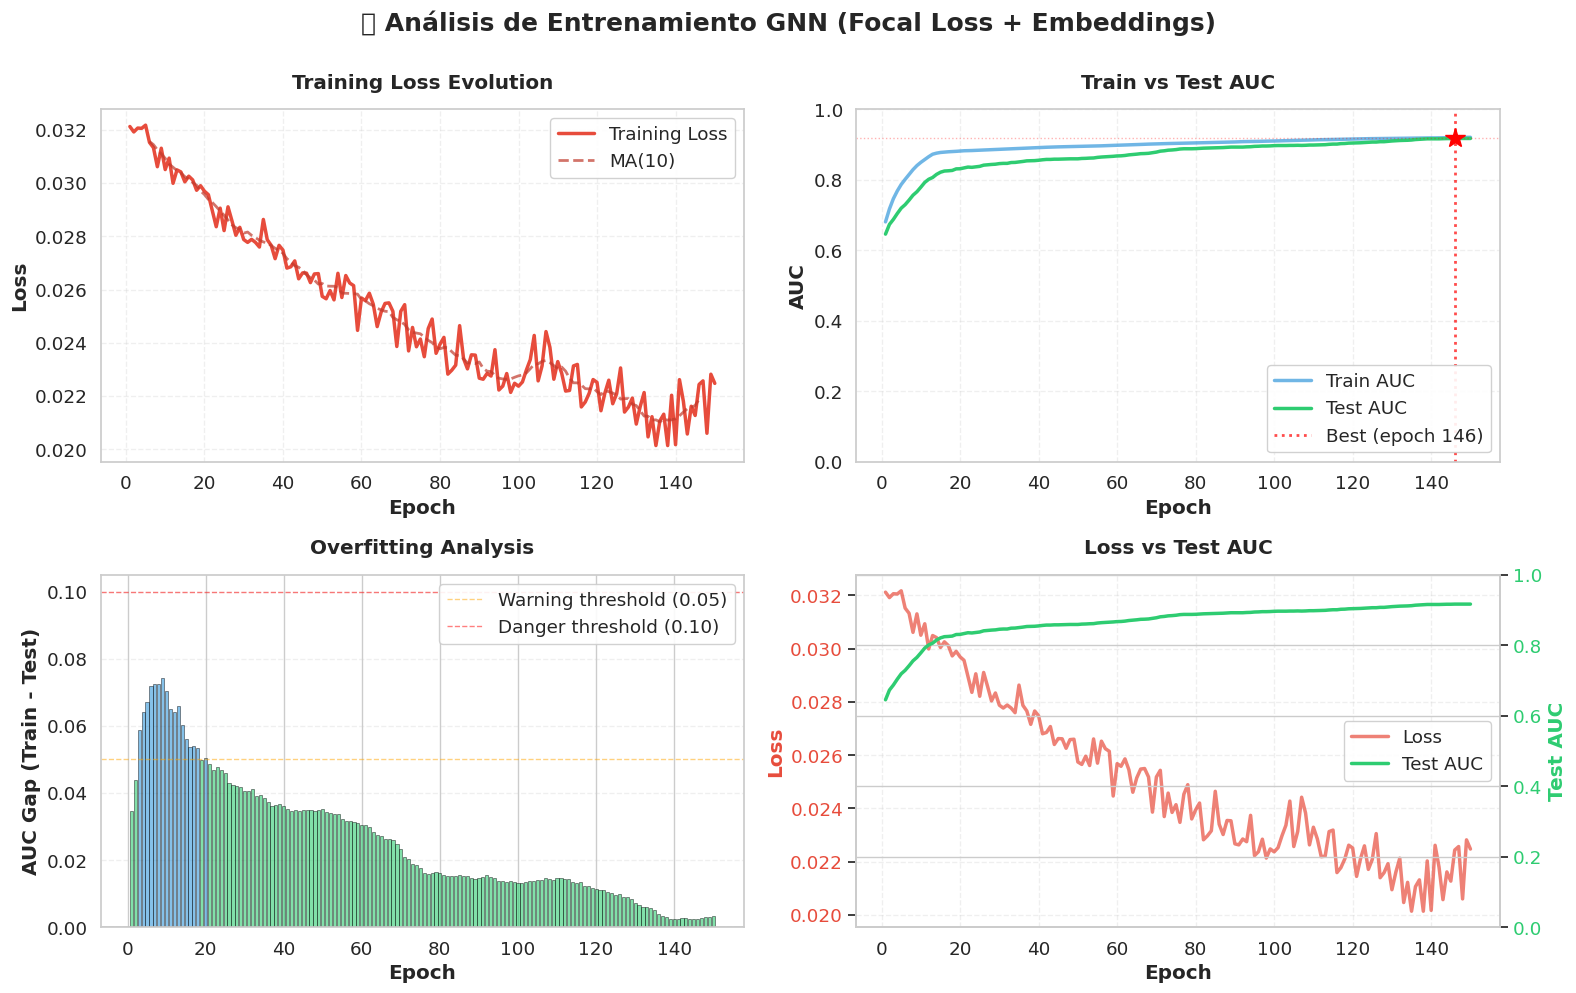

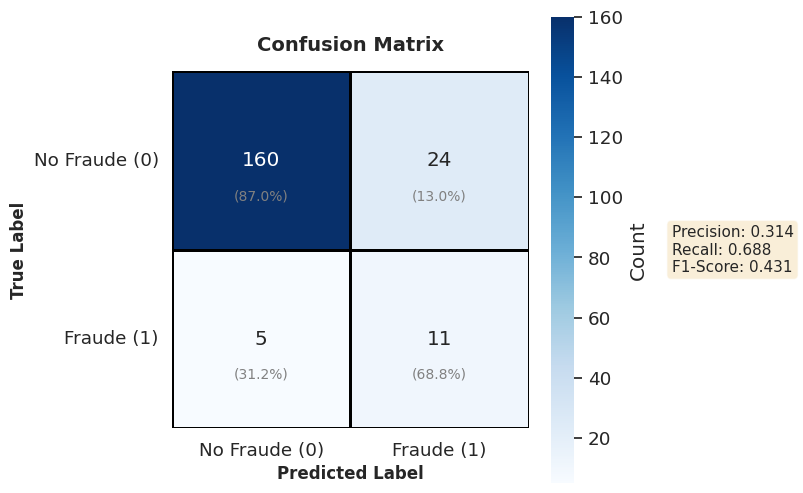

In [21]:
if __name__ == "__main__":
    # Entrenar modelo con Focal Loss, Embeddings y Threshold customizable
    dt = joblib.load("Train_Split/train_split.joblib")

    modelo_gnn, grafo_data, y_true, y_pred, y_prob, train_losses, train_aucs, test_aucs, df_gnn = ejecutar_pipeline_gnn(
    df_fraude=df_fraude,
    X_train_final=dt['X_train_final'],
    X_test_final=dt['X_test'],  # en vez de  X_test_final
    y_train=dt['y_train_final'],  # # en vez de  y_train
    y_test=dt['y_test'],
    df_embeds=df_embeds,
    COLS_NUMERICAS=COLS_NUMERICAS,
    COLS_CATEGORICAS=COLS_CATEGORICAS,
    COLS_SCORE=COLS_SCORE, #Se agrega para features y list
    FOCAL_ALPHA=0.9,
    FOCAL_GAMMA=1.85,
    SEED=2024,
    THRESHOLD=0.465,   #'auto',
    THRESHOLD_METODO='f2'
)
    print("="*80)
    print("DIAGNÓSTICO DEFINITIVO")
    print("="*80)

    # 1. Verificar probabilidades en test
    modelo_gnn.eval()
    with torch.no_grad():
        out = modelo_gnn(grafo_data.x_dict, grafo_data.edge_index_dict)
        probs = F.softmax(out, dim=1).cpu().numpy()

    test_mask = grafo_data['reclamo'].test_mask.cpu().numpy()
    probs_test = probs[test_mask]

    print(f"\n1. PROBABILIDADES EN TEST:")
    print(f"   Prob fraude (clase 1):")
    print(f"     Min: {probs_test[:, 1].min():.6f}")
    print(f"     Max: {probs_test[:, 1].max():.6f}")
    print(f"     Media: {probs_test[:, 1].mean():.6f}")
    print(f"     Mediana: {np.median(probs_test[:, 1]):.6f}")

    # 2. Distribución de probabilidades
    print(f"\n2. DISTRIBUCIÓN:")
    for threshold in [0.1, 0.2, 0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65]:
        count = (probs_test[:, 1] > threshold).sum()
        print(f"   > {threshold}: {count} casos ({count/len(probs_test)*100:.1f}%)")

    # 3. Labels reales en test
    y_test_real = grafo_data['reclamo'].y[test_mask].cpu().numpy()
    print(f"\n3. LABELS REALES EN TEST:")
    print(f"   Clase 0: {(y_test_real == 0).sum()}")
    print(f"   Clase 1: {(y_test_real == 1).sum()}")
    print(f"   Ratio fraude: {(y_test_real == 1).mean():.2%}")

    # 4. Verificar features en test
    features_test = grafo_data['reclamo'].x[test_mask]
    print(f"\n4. FEATURES EN TEST:")
    print(f"   Shape: {features_test.shape}")
    print(f"   Min: {features_test.min().item():.4f}")
    print(f"   Max: {features_test.max().item():.4f}")
    print(f"   Mean: {features_test.mean().item():.4f}")
    print(f"   Nodos con sum=0: {(features_test.sum(dim=1) == 0).sum().item()}")

    # 5. Verificar si train_indices + test_indices = todos
    train_indices = grafo_data['reclamo'].train_mask.nonzero(as_tuple=True)[0].cpu().numpy()
    test_indices = grafo_data['reclamo'].test_mask.nonzero(as_tuple=True)[0].cpu().numpy()

    print(f"\n5. COBERTURA DE MÁSCARAS:")
    print(f"   Train: {len(train_indices)}")
    print(f"   Test: {len(test_indices)}")
    print(f"   Total esperado: {len(df_fraude)}")
    print(f"   Suma train+test: {len(train_indices) + len(test_indices)}")
    print(f"   Nodos sin máscara: {len(df_fraude) - len(train_indices) - len(test_indices)}")

    # 6. Verificar embeddings del modelo
    print(f"\n6. EMBEDDINGS DEL MODELO:")
    for node_type in ['paciente', 'doctor', 'cie', 'cpt']:
        if node_type in modelo_gnn.embeddings:
            emb = modelo_gnn.embeddings[node_type].weight
            print(f"   {node_type}: shape={emb.shape}, mean={emb.mean().item():.4f}, std={emb.std().item():.4f}")

    # 7. ⭐ VERIFICAR QUE NO HAY NODOS CON FEATURES = 0
    all_features = grafo_data['reclamo'].x
    nodos_vacios = (all_features.sum(dim=1) == 0).nonzero(as_tuple=True)[0]
    if len(nodos_vacios) > 0:
        print(f"\n⚠️ 7. HAY {len(nodos_vacios)} NODOS CON FEATURES = 0")
        print(f"   Índices (primeros 20): {nodos_vacios[:20].tolist()}")

        # Verificar si están en test
        nodos_vacios_en_test = np.isin(nodos_vacios.cpu().numpy(), test_indices)
        print(f"   De estos, {nodos_vacios_en_test.sum()} están en TEST")
    else:
        print(f"\n✅ 7. TODOS LOS NODOS TIENEN FEATURES")

    print("="*80)

    PATH = "Modelos_gnn/GNN_predictor.pt"
    torch.save(modelo_gnn.state_dict(), PATH)
    print(f"\n✅ Modelo guardado en: {PATH}")

    # Guardar nombres de features para GNNExplainer
    nombres_features = grafo_data['reclamo'].feature_names
    joblib.dump(nombres_features, 'Modelos_gnn/feature_names.joblib')
    print(f"✅ Feature names guardados en: Modelos_gnn/feature_names.joblib")

    # Encontrar mejor epoch
    best_epoch = np.argmax(test_aucs) + 1

    # Visualizaciones
    print("\n📊 Generando visualizaciones...")

    fig1 = plot_training_curves_seaborn(train_losses, train_aucs, test_aucs, best_epoch)
    plt.show()

    fig2 = plot_confusion_matrix_seaborn(y_true, y_pred)
    plt.show()


# REVISAR

# XGBoost consolidado y mejorado


--- FASE 1: Ingeniería de Features ---
✓ Feature 'dias_poliza_reclamo' creada
✓ Total features numéricas para XGBoost: 4

--- FASE 2: Preparación de Datos ---

📊 Distribución de clases (DESBALANCEADO):
  Clase 0 (No Fraude): 92.00%
  Clase 1 (Fraude):    8.00%
  Ratio: 11.5:1

--- FASE 3: Construcción del Pipeline ---
✓ PCA configurado: 768 dims → 0 dims (se busca retener ~85-90% varianza)

✓ Pipeline configurado:
  - Target Encoding: 3 vars categóricas
  - Robust Scaling: 3 vars numéricas
  - PCA NLP: 768 vars → 0 componentes
  - PCA NLP: 768 vars → 0 componentes
  - Scores semánticos: 1 var
  - XGBoost scale_pos_weight: 5.8
  - Early stopping: 50 rounds

--- FASE 4: Entrenamiento con Early Stopping ---
🔍 Buscando scale_pos_weight con penalización por overfitting...
   Peso: 9.20 -> F1_Val: 0.6667 (Gap: 0.1218)
   Peso: 11.50 -> F1_Val: 0.6316 (Gap: 0.0864)
   Peso: 13.80 -> F1_Val: 0.5417 (Gap: 0.1250)
⭐ Ganador robusto: 9.20

🔄 Preprocesando datos...
🚀 Entrenando XGBoost con valida

/home/juanlewagon/.pyenv/versions/3.10.6/envs/lewagon/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


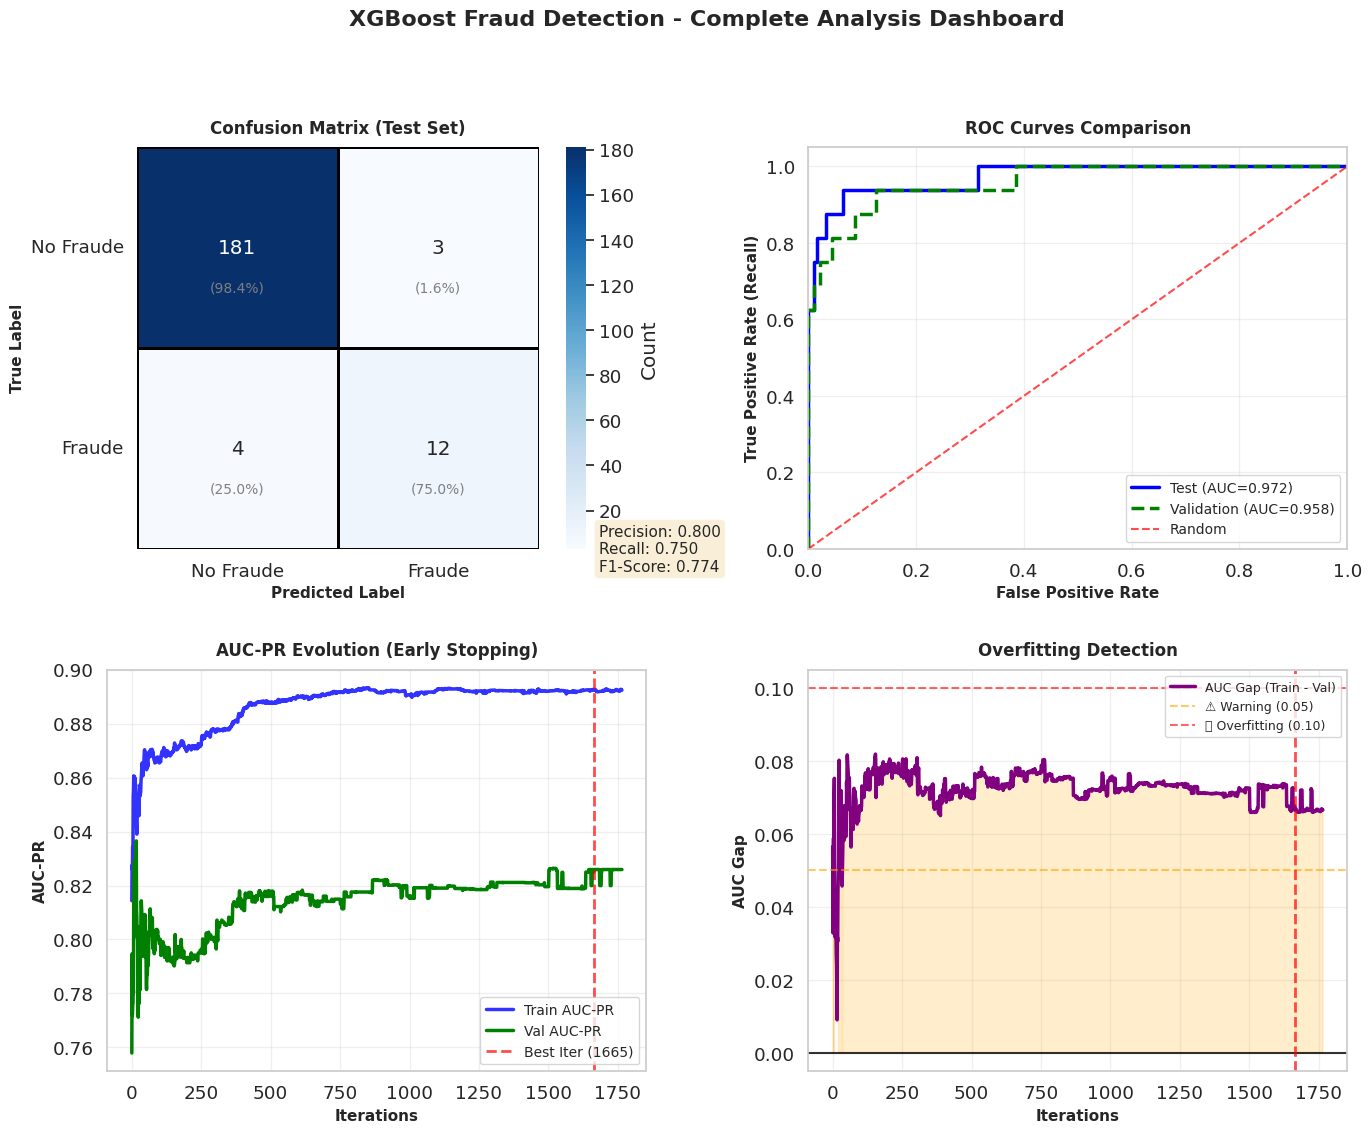

✓ Visualizaciones generadas

--- FASE 8: Guardando Modelo y Artefactos ---
✓ Modelo guardado: modelos/modelo_fraude_pipeline_xg.pkl
✓ Threshold guardado: modelos/optimal_threshold.pkl
✓ Preprocessor guardado: modelos/preprocesador_entrenado.pkl
✓ Métricas guardadas: modelos/metrics.pkl

RESUMEN FINAL DEL ENTRENAMIENTO

📊 División de Datos:
  Total:      1000 registros
  Train:       600 (60%)
  Validation:  200 (20%)
  Test:        200 (20%)
  Desbalanceo: 11.5:1

🎯 Configuración:
  Threshold óptimo: 0.6819
  F-beta (β=1):  Prioriza Recall
  Early stopping:   Round 1665

📈 Rendimiento Final:
  Conjunto     AUC      Precision    Recall     F1      
  ------------------------------------------------------------
  CV (5-fold)  0.9157   0.8500       0.7083     0.7727  
  Validation   0.9579   0.7857       0.6875     0.7333  
  Test         0.9718   0.8000       0.7500     0.7742  

💾 Archivos Guardados en 'modelos/':
  - modelo_fraude_pipeline_xg.pkl
  - optimal_threshold.pkl
  - preproces

In [25]:
from sklearn.preprocessing import OneHotEncoder
"""
Pipeline de Entrenamiento XGBoost para Detección de Fraude
===========================================================

Características principales:
- División Train/Val/Test (60/20/20)
- Early stopping con set de validación
- Optimizado para datos altamente desbalanceados (95% no-fraude, 5% fraude)
- Threshold optimization con F-beta score
- Visualizaciones completas en formato 2x2

"""
# =============================================================================
# CONFIGURACIÓN GLOBAL
# =============================================================================


TEST_SIZE_FRAC = 0.2
RANDOM_SEED = 42
SCALE_POS_WEIGHT = 950/50  # Ratio de desbalance (ajustado en entrenamiento)
BETA = 1 # F-beta: Mayor beta = prioriza Recall sobre Precision

# parametros XGTboost model
max_depth=0
min_child_weight=20
learning_rate=0.005
reg_lambda=5
reg_alpha=3
subsample=0.65
colsample_bytree=0.55
early_stopping_round=100
gamma=4
max_delta_step = 2

# Columnas por tipo
COLS_CATEGORICAS = ['codigos_cie', 'codigos_cpt', 'doctor_tratante']
COLS_NUMERICAS = ['dias_invalidez', 'monto_reclamado']
COLS_DROP = ['numero_poliza', 'nombre', 'fecha_inicio_poliza', 'fecha_reclamo']
COLS_SCORE = ['semantic_score']
COLS_GNN = ['score_gnn']

# Directorio de salida
OUTPUT_DIR = 'modelos'


# =============================================================================
# FUNCIONES DE VISUALIZACIÓN
# =============================================================================

def plot_confusion_matrix_mejorada(y_true, y_pred, ax, title='Confusion Matrix'):
    """
    Genera matriz de confusión con porcentajes y métricas

    Args:
        y_true: Etiquetas verdaderas
        y_pred: Predicciones
        ax: Matplotlib axis
        title: Título del gráfico
    """
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                square=True, linewidths=2, linecolor='black',
                cbar_kws={'label': 'Count'}, ax=ax)

    # Agregar porcentajes
    for i in range(2):
        for j in range(2):
            percentage = cm[i, j] / cm[i, :].sum() * 100
            ax.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)',
                   ha='center', va='center', fontsize=10, color='gray')

    ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=11)
    ax.set_ylabel('True Label', fontweight='bold', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=12, pad=10)
    ax.set_xticklabels(['No Fraude', 'Fraude'], rotation=0)
    ax.set_yticklabels(['No Fraude', 'Fraude'], rotation=0)

    #  AGREGAR MÉTRICAS EN EL GRÁFICO
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    metrics_text = f'Precision: {precision:.3f}\nRecall: {recall:.3f}\nF1-Score: {f1:.3f}'
    ax.text(1.15, 0.0, metrics_text, transform=ax.transAxes,
       fontsize=11, verticalalignment='center',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


def plot_roc_curves_comparison(y_test, y_pred_proba_test,
                               y_val, y_pred_proba_val, ax):
    """
    Genera curvas ROC comparando Test y Validation

    Args:
        y_test, y_pred_proba_test: Datos de test
        y_val, y_pred_proba_val: Datos de validation
        ax: Matplotlib axis
    """
    # ROC para Test
    fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_proba_test)
    auc_test = auc(fpr_test, tpr_test)
    ax.plot(fpr_test, tpr_test, 'b-', lw=2.5,
            label=f'Test (AUC={auc_test:.3f})')

    # ROC para Validation
    fpr_val, tpr_val, _ = roc_curve(y_val, y_pred_proba_val)
    auc_val = auc(fpr_val, tpr_val)
    ax.plot(fpr_val, tpr_val, 'g--', lw=2.5,
            label=f'Validation (AUC={auc_val:.3f})')

    # Línea diagonal (clasificador aleatorio)
    ax.plot([0, 1], [0, 1], 'r--', lw=1.5, alpha=0.7, label='Random')

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontweight='bold', fontsize=11)
    ax.set_ylabel('True Positive Rate (Recall)', fontweight='bold', fontsize=11)
    ax.set_title('ROC Curves Comparison', fontweight='bold', fontsize=12, pad=10)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)


def plot_auc_evolution(xgb_classifier, ax):
    """
    Muestra evolución de AUC-PR durante entrenamiento

    Args:
        xgb_classifier: Modelo XGBoost entrenado
        ax: Matplotlib axis
    """
    results = xgb_classifier.evals_result()
    epochs = len(results['validation_0']['aucpr'])
    x_axis = range(0, epochs)

    # Curvas de AUC
    ax.plot(x_axis, results['validation_0']['aucpr'],
            'b-', lw=2.5, label='Train AUC-PR', alpha=0.8)
    ax.plot(x_axis, results['validation_1']['aucpr'],
            'g-', lw=2.5, label='Val AUC-PR')

    # Marcar best iteration
    best_iter = xgb_classifier.best_iteration
    ax.axvline(x=best_iter, color='red', linestyle='--', lw=2,
               alpha=0.7, label=f'Best Iter ({best_iter})')

    ax.set_xlabel('Iterations', fontweight='bold', fontsize=11)
    ax.set_ylabel('AUC-PR', fontweight='bold', fontsize=11)
    ax.set_title('AUC-PR Evolution (Early Stopping)', fontweight='bold',
                 fontsize=12, pad=10)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)


def plot_overfitting_analysis(xgb_classifier, ax):
    """
    Analiza gap entre Train y Validation (detección de overfitting)

    Args:
        xgb_classifier: Modelo XGBoost entrenado
        ax: Matplotlib axis
    """
    results = xgb_classifier.evals_result()
    epochs = len(results['validation_0']['aucpr'])
    x_axis = range(0, epochs)

    train_auc = np.array(results['validation_0']['aucpr'])
    val_auc = np.array(results['validation_1']['aucpr'])
    gap = train_auc - val_auc

    # Gráfico de gap
    ax.plot(x_axis, gap, 'purple', lw=2.5, label='AUC Gap (Train - Val)')

    # Líneas de referencia
    ax.axhline(y=0, color='black', linestyle='-', lw=1.5, alpha=0.8)
    ax.axhline(y=0.05, color='orange', linestyle='--', lw=1.5,
               alpha=0.6, label='⚠️ Warning (0.05)')
    ax.axhline(y=0.10, color='red', linestyle='--', lw=1.5,
               alpha=0.6, label='🚨 Overfitting (0.10)')

    # Marcar best iteration
    best_iter = xgb_classifier.best_iteration
    ax.axvline(x=best_iter, color='red', linestyle='--', lw=2, alpha=0.7)

    # Sombrear zona de overfitting
    ax.fill_between(x_axis, 0, gap, where=(gap > 0.05),
                    color='orange', alpha=0.2)
    ax.fill_between(x_axis, 0.05, gap, where=(gap > 0.10),
                    color='red', alpha=0.2)

    ax.set_xlabel('Iterations', fontweight='bold', fontsize=11)
    ax.set_ylabel('AUC Gap', fontweight='bold', fontsize=11)
    ax.set_title('Overfitting Detection', fontweight='bold',
                 fontsize=12, pad=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

def buscar_scale_weight_optimo(X_train_prep_1, y_train, X_val_prep_1, y_val):
    base_ratio = (y_train == 0).sum() / (y_train == 1).sum()
    # Candidatos: desde muy suaves hasta el ratio real
    #candidates = [np.sqrt(base_ratio), base_ratio * 0.4, base_ratio * 0.6, base_ratio * 0.8]
    candidates = [base_ratio * 0.8, base_ratio * 1.0, base_ratio * 1.2]
    best_score_ajustado = -float('inf')
    best_weight = candidates[0]

    print("🔍 Buscando scale_pos_weight con penalización por overfitting...")
    for weight in candidates:
        test_model = XGBClassifier(
            n_estimators=300,
            max_depth=max_depth,
            min_child_weight=min_child_weight,
            learning_rate=learning_rate,
            reg_lambda=reg_lambda,
            reg_alpha=reg_alpha,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            scale_pos_weight=weight,
        )

        test_model.fit(X_train_prep_1, y_train)

        # Calculamos F1 en ambos sets
        f1_train = f1_score(y_train, test_model.predict(X_train_prep_1))
        f1_val = f1_score(y_val, test_model.predict(X_val_prep_1))

        # MÉTRICA CLAVE: F1_val menos el "gap" de overfitting
        gap = abs(f1_train - f1_val)
        score_ajustado = f1_val - (gap * 0.5) # Penalizamos el 50% del gap

        print(f"   Peso: {weight:.2f} -> F1_Val: {f1_val:.4f} (Gap: {gap:.4f})")

        if score_ajustado > best_score_ajustado:
            best_score_ajustado = score_ajustado
            best_weight = weight

    print(f"⭐ Ganador robusto: {best_weight:.2f}\n")
    return best_weight

# =============================================================================
# FUNCIÓN PRINCIPAL
# =============================================================================

def entrenar_modelo_fraude(df_fraude, df_embeds, df_scores,df_gnn,
                           X_train,X_val, X_test,y_train,y_val,y_test,
                           idx_train,idx_val,idx_test,
                           ):
    """

    df_fraude : DataFrame
        DataFrame con datos de reclamos y etiquetas de fraude
        se agrega score que sale de modelo GNN
    df_embeds : DataFrame
        Embeddings NLP (768 dimensiones por defecto)
    df_scores : DataFrame
        Scores semánticos de similitud
    df_gnn : DataFrame
        probabilidad de GNN

    """

    # =========================================================================
    # FASE 1: INGENIERÍA DE FEATURES
    # =========================================================================
    print("\n--- FASE 1: Ingeniería de Features ---")

    # Feature temporal: días entre póliza y reclamo
    df_fraude['dias_poliza_reclamo'] = (
        df_fraude['fecha_reclamo'] - df_fraude['fecha_inicio_poliza']
    ).dt.days

    COLS_NUMERICAS.append('dias_poliza_reclamo')

    # Columnas numéricas específicas para XGBoost (incluye score semántico)
    COLS_NUMERICAS_XG = COLS_NUMERICAS.copy()
    COLS_NUMERICAS_XG.extend(COLS_SCORE)

    print(f"✓ Feature 'dias_poliza_reclamo' creada")
    print(f"✓ Total features numéricas para XGBoost: {len(COLS_NUMERICAS_XG)}")

    # =========================================================================
    # FASE 2: PREPARACIÓN DE DATOS
    # =========================================================================
    print("\n--- FASE 2: Preparación de Datos ---")

    # Variable objetivo
    y = df_fraude['fraude_label']

    # Distribución de clases
    class_dist = y.value_counts(normalize=True)
    print(f"\n📊 Distribución de clases (DESBALANCEADO):")
    print(f"  Clase 0 (No Fraude): {class_dist[0]*100:.2f}%")
    print(f"  Clase 1 (Fraude):    {class_dist[1]*100:.2f}%")
    print(f"  Ratio: {class_dist[0]/class_dist[1]:.1f}:1")

    # Crear X_tab (features tabulares SIN embeddings)
    X_tab = df_fraude.drop(columns=['descripcion', 'fraude_label'] + COLS_DROP,
                           errors='ignore')

    # Preparar columnas de embeddings y scores
    df_embeds.columns = [str(c) for c in df_embeds.columns]
    df_scores.columns = [str(c) for c in df_scores.columns]
    df_gnn.columns = [str(c) for c in df_gnn.columns]

    NLP_COLS = df_embeds.columns.tolist()
    SCORE_COLS = df_scores.columns.tolist()
    GNN_COLS = df_gnn.columns.tolist()

    X_gnn_train = df_gnn.loc[idx_train]
    X_gnn_val = df_gnn.loc[idx_val]
    X_gnn_test = df_gnn.loc[idx_test]

    X_train_final = pd.concat([X_train, X_gnn_train], axis = 1)
    X_val_final = pd.concat([X_val, X_gnn_val], axis = 1)
    X_test_final = pd.concat([X_test, X_gnn_test], axis = 1)

    # Dataset completo para GNN (sin scores)
    X_completo = pd.concat([
        X_tab.reset_index(drop=True),
        df_embeds.reset_index(drop=True)
    ], axis=1)

    # Dataset completo para XGBoost (con scores)
    X_completo_xg = pd.concat([
        X_tab.reset_index(drop=True),
        df_embeds.reset_index(drop=True),
        df_scores.reset_index(drop=True),
        df_gnn.reset_index(drop=True)
    ], axis=1)
    """
    print(f"\n✓ X_tab shape: {X_tab.shape}")
    print(f"✓ X_completo (GNN) shape: {X_completo.shape}")
    print(f"✓ X_completo_xg shape: {X_completo_xg.shape}")
    print(f"  - Features tabulares: {X_tab.shape[1]}")
    print(f"  - Features NLP: {df_embeds.shape[1]}")
    print(f"  - Features Score: {df_scores.shape[1]}")
    """
    # CONSTRUCCIÓN DEL PIPELINE
    # =========================================================================
    print("\n--- FASE 3: Construcción del Pipeline ---")

    # Transformer para embeddings NLP: Imputer + PCA
    n_comp=0
    nlp_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('pca', PCA(n_components=n_comp, random_state=RANDOM_SEED))
    ])

    print(f"✓ PCA configurado: 768 dims → {n_comp} dims (se busca retener ~85-90% varianza)")

    # Preprocessor 1 completo pero solo para uso de calculo de best weigh
    """preprocessor_1 = ColumnTransformer(
        transformers=[
            ('onehot', OneHotEncoder(sparse=False, handle_unknown='ignore'), COLS_CATEGORICAS),
            ('robust_scale', RobustScaler(), COLS_NUMERICAS),
            ('nlp_process', nlp_transformer, NLP_COLS),
            ('scores_sem', 'passthrough', SCORE_COLS),
            ('score_gnn', 'passthrough', GNN_COLS)
        ],
        remainder='drop'
    )"""

        # Usa tu misma nomenclatura de variables
    preprocessor_1 = ColumnTransformer(
        transformers=[
                #('ce_enc', ce.CatBoostEncoder(cols=COLS_CATEGORICAS,random_state=RANDOM_SEED), COLS_CATEGORICAS),
                ('robust_scale', RobustScaler(), COLS_NUMERICAS),
                ('nlp_process', nlp_transformer, NLP_COLS),
                ('scores_sem', 'passthrough', SCORE_COLS),
                ('score_gnn', 'passthrough', GNN_COLS)
            ],
            remainder='drop'
        )


    print(f"\n✓ Pipeline configurado:")
    print(f"  - Target Encoding: {len(COLS_CATEGORICAS)} vars categóricas")
    print(f"  - Robust Scaling: {len(COLS_NUMERICAS)} vars numéricas")
    print(f"  - PCA NLP: {len(NLP_COLS)} vars → {n_comp} componentes")
    print(f"  - PCA NLP: {len(NLP_COLS)} vars → {n_comp} componentes")
    print(f"  - Scores semánticos: {len(GNN_COLS)} var")
    print(f"  - XGBoost scale_pos_weight: {((y_train == 0).sum()/(y_train == 1).sum())*0.5:.1f}")
    print(f"  - Early stopping: 50 rounds")

    # =========================================================================
    # FASE 4: ENTRENAMIENTO CON VALIDACIÓN
    # =========================================================================
    print("\n--- FASE 4: Entrenamiento con Early Stopping ---")

    # Convertir nombres de columnas a string
    X_train_final.columns = X_train_final.columns.astype(str)
    X_val_final.columns = X_val_final.columns.astype(str)
    X_test_final.columns = X_test_final.columns.astype(str)

    preprocessor_1.fit(X_train_final, y_train)

    X_train_prep_1 = preprocessor_1.transform(X_train_final)
    X_val_prep_1 = preprocessor_1.transform(X_val_final)

    best_weigh = buscar_scale_weight_optimo(X_train_prep_1, y_train, X_val_prep_1, y_val)

    # Modelo XGBoost optimizado para datos desbalanceados
    xgb_model = XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=best_weigh,
        eval_metric=['aucpr', 'logloss'],  # Métrica apropiada para desbalance
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        learning_rate=learning_rate,
        reg_lambda=reg_lambda,
        reg_alpha=reg_alpha,
        n_estimators=2000,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        early_stopping_rounds=100, # aquí se activa el early stopping
        enable_categorical=False,
        random_state=RANDOM_SEED,
        gamma=2,
        max_delta_step = 2,
        tree_method = 'hist',
        grow_policy = 'lossguide',
        n_jobs=-1
    )

 # Preprocessor 2 completo para uso final de modelamiento y entrenamiento
    """preprocessor_2 = ColumnTransformer(
        transformers=[
            ('onehot', OneHotEncoder(sparse=False, handle_unknown='ignore'), COLS_CATEGORICAS),
            ('robust_scale', RobustScaler(), COLS_NUMERICAS),
            ('nlp_process', nlp_transformer, NLP_COLS),
            ('scores_sem', 'passthrough', SCORE_COLS),
            ('score_gnn', 'passthrough', GNN_COLS)
        ],
        remainder='drop'
    )"""


    preprocessor_2=ColumnTransformer(
            transformers=[
                #('ce_enc', ce.CatBoostEncoder(cols=COLS_CATEGORICAS,random_state=RANDOM_SEED), COLS_CATEGORICAS),
                ('robust_scale', RobustScaler(), COLS_NUMERICAS),
                ('nlp_process', nlp_transformer, NLP_COLS),
                ('scores_sem', 'passthrough', SCORE_COLS),
                ('score_gnn', 'passthrough', GNN_COLS)
            ],
            remainder='drop'
        )

    # Pipeline completo
    modelo_fraude_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_2),
        ('classifier', xgb_model)
    ])
    # Preprocesar train y validation
    print("🔄 Preprocesando datos...")
    preprocessor = modelo_fraude_pipeline.named_steps['preprocessor']
    preprocessor.fit(X_train_final, y_train)

    X_train_prep = preprocessor.transform(X_train_final)
    X_val_prep = preprocessor.transform(X_val_final)

    # Entrenar con early stopping
    print("🚀 Entrenando XGBoost con validation set...")
    xgb_classifier = modelo_fraude_pipeline.named_steps['classifier']
    xgb_classifier.fit(
        X_train_prep, y_train,
        eval_set=[(X_train_prep, y_train), (X_val_prep, y_val)],
        verbose=False
    )

    print(f"\n✓ Modelo entrenado exitosamente")
    print(f"  - Best iteration: {xgb_classifier.best_iteration}")
    print(f"  - Best score (validation): {xgb_classifier.best_score:.4f}")
    print(f"  - Total iterations: {len(xgb_classifier.evals_result()['validation_0']['aucpr'])}")

    # =========================================================================
    # FASE 5: VALIDACIÓN CRUZADA Y OPTIMIZACIÓN DE THRESHOLD
    # =========================================================================
    print("\n--- FASE 5: Cross-Validation y Threshold Optimization ---")

    # ⚠️ IMPORTANTE: Crear pipeline SIN early stopping para CV
    # cross_val_predict no soporta eval_set, por lo que no puede usar early stopping
    print("🔄 Ejecutando 5-Fold Cross-Validation...")
    best_iter_final = xgb_classifier.best_iteration

    # Clonar XGBoost sin early stopping (solo para CV)
    xgb_model_cv = XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight= best_weigh,
        eval_metric=['aucpr', 'logloss'],  # ← Usar múltiples métricas,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        learning_rate=learning_rate,
        reg_lambda=reg_lambda,
        reg_alpha=reg_alpha,
        # USAMOS UN NÚMERO FIJO BASADO EN EL ENTRENAMIENTO PREVIO
        n_estimators= best_iter_final if best_iter_final > 0 else 200,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        enable_categorical=False,
        # early_stopping_round=early_stopping_round, #QUITAMOS early_stopping_rounds para que no choque con cross_val_predict
        random_state=RANDOM_SEED,
        gamma=2,
        max_delta_step = 2,
        tree_method = 'hist',
        grow_policy = 'lossguide',
        n_jobs=-1
    )

    # Pipeline temporal para CV
    pipeline_cv = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)), # <--- Clonar para evitar leakage
    ('classifier', xgb_model_cv)
    ])

    cv_method = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    y_train_proba_cv = cross_val_predict(
        pipeline_cv,
        X_train_final,
        y_train,
        cv=cv_method,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]

    auc_cv = roc_auc_score(y_train, y_train_proba_cv)
    print(f"✓ AUC-ROC en Cross-Validation: {auc_cv:.4f}")
    print(f"   (Nota: CV usa modelo sin early stopping, 300 árboles fijos)")

    # Optimización de threshold usando F-beta Score
    print(f"\n🎯 Optimizando threshold (F{BETA} Score)...")
    precision_cv, recall_cv, thresholds = precision_recall_curve(y_train, y_train_proba_cv)

    f_beta_scores = []
    for threshold in thresholds[:-1]:
        y_pred_current = (y_train_proba_cv >= threshold).astype(int)
        f_beta = fbeta_score(y_train, y_pred_current, beta=BETA)
        f_beta_scores.append(f_beta)

    #best_index = np.argmax(f_beta_scores)

    valid = np.where((precision_cv[:-1] >= 0.3) & (recall_cv[:-1] >= 0.6))[0]
    if len(valid) > 0:
        # Si hay varios que cumplen, elegimos el mejor F1 (o F-beta)
        best_index = valid[np.argmax(np.array(f_beta_scores)[valid])]
        optimal_threshold_cv = thresholds[best_index]
    else:
        # PLAN B: Si nada cumple el mínimo, simplemente toma el máximo F1 posible
        print("⚠️ Advertencia: Ningún threshold cumplió los requisitos mínimos. Usando el máximo F1 global.")
        best_index = np.argmax(f_beta_scores)
        optimal_threshold_cv = thresholds[best_index]

    print(f"\n✓ Threshold óptimo encontrado: {optimal_threshold_cv:.4f}")
    print(f"  - Recall en CV:    {recall_cv[best_index]:.4f}")
    print(f"  - Precision en CV: {precision_cv[best_index]:.4f}")
    print(f"  - F{BETA} Score en CV: {max(f_beta_scores):.4f}")

    # =========================================================================
    # EVALUACIÓN EN VALIDATION SET
    # =========================================================================
    print("\n--- Evaluación en Validation Set ---")

    y_val_proba = modelo_fraude_pipeline.predict_proba(X_val_final)[:, 1]
    y_val_pred = (y_val_proba >= optimal_threshold_cv).astype(int)

    auc_val = roc_auc_score(y_val, y_val_proba)
    precision_val = precision_score(y_val, y_val_pred, zero_division=0)
    recall_val = recall_score(y_val, y_val_pred, zero_division=0)
    f1_val = f1_score(y_val, y_val_pred, zero_division=0)

    print(f"\n✓ Métricas en Validation:")
    print(f"  - AUC-ROC:    {auc_val:.4f}")
    print(f"  - Precision:  {precision_val:.4f}")
    print(f"  - Recall:     {recall_val:.4f}")
    print(f"  - F1-Score:   {f1_val:.4f}")

    # =========================================================================
    # FASE 6: EVALUACIÓN EN TEST SET
    # =========================================================================
    print("\n--- FASE 6: Evaluación en Test Set ---")

    y_pred_proba = modelo_fraude_pipeline.predict_proba(X_test_final)[:, 1]
    y_pred_final_optimal = (y_pred_proba >= optimal_threshold_cv).astype(int)

    # Métricas
    auc_test = roc_auc_score(y_test, y_pred_proba)
    f1_final = f1_score(y_test, y_pred_final_optimal, zero_division=0)
    recall_final = recall_score(y_test, y_pred_final_optimal, zero_division=0)
    precision_final = precision_score(y_test, y_pred_final_optimal, zero_division=0)

    print(f"\n📊 MÉTRICAS EN TEST (CONJUNTO FINAL):")
    print(f"{'='*60}")
    print(f"AUC-ROC:    {auc_test:.4f}")
    print(f"Recall:     {recall_final:.4f} ← Priorizado (β={BETA})")
    print(f"Precision:  {precision_final:.4f}")
    print(f"F1-Score:   {f1_final:.4f}")
    print(f"{'='*60}")

    # Reporte completo
    print("\n" + classification_report(
        y_test, y_pred_final_optimal,
        target_names=['No Fraude', 'Fraude'],
        digits=4
    ))

    # Matriz de confusión detallada
    cm = confusion_matrix(y_test, y_pred_final_optimal)
    tn, fp, fn, tp = cm.ravel()
    print(f"\nMatriz de Confusión (Test):")
    print(f"  TN: {tn:>3} | FP: {fp:>3}")
    print(f"  FN: {fn:>3} | TP: {tp:>3}")
    print(f"\n  Tasa de Falsos Positivos: {fp/(fp+tn)*100:.1f}%")
    print(f"  Tasa de Falsos Negativos: {fn/(fn+tp)*100:.1f}%")

    # =========================================================================
    # FASE 7: VISUALIZACIONES (2x2 GRID)
    # =========================================================================
    print("\n--- FASE 7: Generando Visualizaciones (2x2) ---")

    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

    # 1. Confusion Matrix (arriba izquierda)
    print("[1/4] Generando Matriz de Confusión...")
    ax1 = fig.add_subplot(gs[0, 0])
    plot_confusion_matrix_mejorada(y_test, y_pred_final_optimal, ax1,
                                   title='Confusion Matrix (Test Set)')

    # 2. ROC Curves Comparison (arriba derecha)
    print("[2/4] Generando Curvas ROC (Test vs Val)...")
    ax2 = fig.add_subplot(gs[0, 1])
    plot_roc_curves_comparison(y_test, y_pred_proba,
                               y_val, y_val_proba, ax2)

    # 3. AUC-PR Evolution (abajo izquierda)
    print("[3/4] Generando evolución de AUC-PR...")
    ax3 = fig.add_subplot(gs[1, 0])
    plot_auc_evolution(xgb_classifier, ax3)

    # 4. Overfitting Analysis (abajo derecha)
    print("[4/4] Generando análisis de overfitting...")
    ax4 = fig.add_subplot(gs[1, 1])
    plot_overfitting_analysis(xgb_classifier, ax4)

    # Título general
    plt.suptitle('XGBoost Fraud Detection - Complete Analysis Dashboard',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.show()
    print("✓ Visualizaciones generadas")

    # =========================================================================
    # FASE 8: GUARDAR MODELO Y MÉTRICAS
    # =========================================================================
    print("\n--- FASE 8: Guardando Modelo y Artefactos ---")

    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

    # Guardar pipeline completo
    model_path = f'{OUTPUT_DIR}/modelo_fraude_pipeline_xg.pkl'
    joblib.dump(modelo_fraude_pipeline, model_path)
    print(f"✓ Modelo guardado: {model_path}")

    # Guardar threshold óptimo
    threshold_path = f'{OUTPUT_DIR}/optimal_threshold.pkl'
    joblib.dump(optimal_threshold_cv, threshold_path)
    print(f"✓ Threshold guardado: {threshold_path}")

    # Guardar preprocessor por separado (útil para GNN)
    preprocessor_path = f'{OUTPUT_DIR}/preprocesador_entrenado.pkl'
    joblib.dump(preprocessor, preprocessor_path)
    print(f"✓ Preprocessor guardado: {preprocessor_path}")

    # Guardar métricas completas
    metrics = {
        # Test metrics
        'auc_test': auc_test,
        'recall_test': recall_final,
        'precision_test': precision_final,
        'f1_test': f1_final,

        # Validation metrics
        'auc_val': auc_val,
        'recall_val': recall_val,
        'precision_val': precision_val,
        'f1_val': f1_val,

        # Training info
        'auc_cv': auc_cv,
        'threshold': optimal_threshold_cv,
        'best_iteration': xgb_classifier.best_iteration,
        'total_iterations': len(xgb_classifier.evals_result()['validation_0']['aucpr']),

        # Configuration
        'beta': BETA,
        'scale_pos_weight': ((y_train == 0).sum()/(y_train == 1).sum())*0.5,
        'random_seed': RANDOM_SEED,
        'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    metrics_path = f'{OUTPUT_DIR}/metrics.pkl'
    joblib.dump(metrics, metrics_path)
    print(f"✓ Métricas guardadas: {metrics_path}")

    # =========================================================================
    # RESUMEN FINAL
    # =========================================================================
    print("\n" + "="*80)
    print("RESUMEN FINAL DEL ENTRENAMIENTO")
    print("="*80)

    print(f"\n📊 División de Datos:")
    print(f"  Total:      {len(df_fraude):>4} registros")
    print(f"  Train:      {len(y_train):>4} ({len(y_train)/len(df_fraude)*100:.0f}%)")
    print(f"  Validation: {len(y_val):>4} ({len(y_val)/len(df_fraude)*100:.0f}%)")
    print(f"  Test:       {len(y_test):>4} ({len(y_test)/len(df_fraude)*100:.0f}%)")
    print(f"  Desbalanceo: {(y_train == 0).sum()/(y_train == 1).sum():.1f}:1")

    print(f"\n🎯 Configuración:")
    print(f"  Threshold óptimo: {optimal_threshold_cv:.4f}")
    print(f"  F-beta (β={BETA}):  Prioriza Recall")
    print(f"  Early stopping:   Round {xgb_classifier.best_iteration}")

    print(f"\n📈 Rendimiento Final:")
    print(f"  {'Conjunto':<12} {'AUC':<8} {'Precision':<12} {'Recall':<10} {'F1':<8}")
    print(f"  {'-'*60}")
    print(f"  {'CV (5-fold)':<12} {auc_cv:<8.4f} {precision_cv[best_index]:<12.4f} "
          f"{recall_cv[best_index]:<10.4f} {max(f_beta_scores):<8.4f}")
    print(f"  {'Validation':<12} {auc_val:<8.4f} {precision_val:<12.4f} "
          f"{recall_val:<10.4f} {f1_val:<8.4f}")
    print(f"  {'Test':<12} {auc_test:<8.4f} {precision_final:<12.4f} "
          f"{recall_final:<10.4f} {f1_final:<8.4f}")

    print(f"\n💾 Archivos Guardados en '{OUTPUT_DIR}/':")
    print(f"  - modelo_fraude_pipeline_xg.pkl")
    print(f"  - optimal_threshold.pkl")
    print(f"  - preprocesador_entrenado.pkl")
    print(f"  - metrics.pkl")

        # =========================================================================
    # OPTIMIZACIÓN DE THRESHOLD CON DIAGNÓSTICO
    # =========================================================================
    print(f"\n--- FASE 5: Optimización de Threshold (F{BETA}) ---")

    precision_cv, recall_cv, thresholds = precision_recall_curve(y_train, y_train_proba_cv)

    # 🔍 DIAGNÓSTICO: Ver distribución de probabilidades
    print(f"\n📊 Diagnóstico de Probabilidades:")
    print(f"  Fraudes (y=1):")
    print(f"    - Min:    {y_train_proba_cv[y_train == 1].min():.4f}")
    print(f"    - Median: {np.median(y_train_proba_cv[y_train == 1]):.4f}")
    print(f"    - Max:    {y_train_proba_cv[y_train == 1].max():.4f}")
    print(f"  No Fraudes (y=0):")
    print(f"    - Min:    {y_train_proba_cv[y_train == 0].min():.4f}")
    print(f"    - Median: {np.median(y_train_proba_cv[y_train == 0]):.4f}")
    print(f"    - Max:    {y_train_proba_cv[y_train == 0].max():.4f}")

    f_beta_scores = []
    for threshold in thresholds[:-1]:
        y_pred = (y_train_proba_cv >= threshold).astype(int)
        f_beta = fbeta_score(y_train, y_pred, beta=BETA)
        f_beta_scores.append(f_beta)
    """
    # 🔍 DIAGNÓSTICO: Ver cuántos thresholds cumplen requisitos
    valid_indices = np.where(
        (precision_cv[:-1] >= 0.30) &
        (recall_cv[:-1] >= 0.60)
    )[0]

    print(f"\n🔍 Thresholds válidos: {len(valid_indices)} de {len(thresholds)-1}")

    if len(valid_indices) > 0:
        best_idx = valid_indices[np.argmax(np.array(f_beta_scores)[valid_indices])]
        optimal_threshold = thresholds[best_idx]
        print("✅ Usando threshold con restricciones")
    else:
        print("⚠️ NINGÚN threshold cumple los requisitos mínimos")
        print("   Usando threshold con máximo F-beta SIN restricciones")

        # 🔥 NUEVO: Aplicar restricciones más SUAVES
        relaxed_valid = np.where(
            (precision_cv[:-1] >= 0.20) &  # Más permisivo
            (recall_cv[:-1] >= 0.40)       # Más permisivo
        )[0]

        if len(relaxed_valid) > 0:
            best_idx = relaxed_valid[np.argmax(np.array(f_beta_scores)[relaxed_valid])]
            print(f"   ℹ️  Usando restricciones relajadas (P≥0.20, R≥0.40)")
        else:
            # Plan C: Simplemente maximizar recall con precision mínima
            min_precision_valid = np.where(precision_cv[:-1] >= 0.15)[0]
            if len(min_precision_valid) > 0:
                best_idx = min_precision_valid[np.argmax(recall_cv[:-1][min_precision_valid])]
                print(f"   ℹ️  Usando threshold que maximiza recall (P≥0.15)")
            else:
                best_idx = np.argmax(f_beta_scores)
                print(f"   ⚠️  Usando threshold con máximo F-beta global")

        optimal_threshold = thresholds[best_idx]
    """
    # Priorizar RECALL: buscar threshold con precision mínima aceptable
    valid_indices = np.where(precision_cv[:-1] >= 0.20)[0]

    if len(valid_indices) > 0:
        # De los que tienen precision aceptable, elegir el de MAYOR RECALL
        best_idx = valid_indices[np.argmax(recall_cv[:-1][valid_indices])]
    else:
        # Si ninguno tiene precision >= 0.20, usar threshold bajo fijo
        best_idx = np.argmin(np.abs(thresholds - 0.25))

    optimal_threshold = thresholds[best_idx]

    # Verificar que no predice 0 fraudes
    y_check = (y_train_proba_cv >= optimal_threshold).astype(int)
    if y_check.sum() == 0:
        print("⚠️ Threshold predice 0 fraudes, bajando threshold")
        optimal_threshold = 0.20
        best_idx = np.argmin(np.abs(thresholds - optimal_threshold))

    print(f"\n✓ Threshold seleccionado: {optimal_threshold:.4f}")
    print(f"  - Precision en CV: {precision_cv[best_idx]:.4f}")
    print(f"  - Recall en CV:    {recall_cv[best_idx]:.4f}")
    print(f"  - F{BETA} en CV:       {f_beta_scores[best_idx]:.4f}")

    # 🔍 DIAGNÓSTICO: Cuántos casos clasifica como fraude
    y_train_pred_check = (y_train_proba_cv >= optimal_threshold).astype(int)
    n_predicted_fraud = y_train_pred_check.sum()
    print(f"  - Casos clasificados como fraude: {n_predicted_fraud} de {len(y_train)}")
    print(f"    ({n_predicted_fraud/len(y_train)*100:.1f}% del train set)")

    # 🚨 VALIDACIÓN: Si predice 0 fraudes, forzar threshold más bajo
    if n_predicted_fraud == 0:
        print("\n🚨 ALERTA: Threshold predice 0 fraudes!")
        print("   Forzando threshold = percentil 90 de probabilidades")
        optimal_threshold = np.percentile(y_train_proba_cv, 90)
        print(f"   Nuevo threshold: {optimal_threshold:.4f}")

        y_train_pred_check = (y_train_proba_cv >= optimal_threshold).astype(int)
        n_predicted_fraud = y_train_pred_check.sum()
        print(f"   Ahora predice: {n_predicted_fraud} fraudes")

        print("\n" + "="*80)
        print("✅ PIPELINE COMPLETADO EXITOSAMENTE")
        print("="*80 + "\n")

    # Retornar todos los componentes

    return (modelo_fraude_pipeline, optimal_threshold_cv, metrics)


# =============================================================================
# EJEMPLO DE USO
# =============================================================================

if __name__ == "__main__":
    dt = joblib.load("Train_Split/train_split.joblib")

    modelo_fraude_pipeline, optimal_threshold_cv, metrics = entrenar_modelo_fraude(
        df_fraude,
        df_embeds,
        df_scores,
        df_gnn,
        X_train = dt['X_train'],
        X_val = dt['X_val'],
        X_test = dt['X_test'],
        y_train = dt['y_train'],
        y_val = dt['y_val'],
        y_test = dt['y_test'],
        idx_train = dt['idx_train'],
        idx_val = dt['idx_val'],
        idx_test = dt['idx_test'])

# Produccion de XGBOOST

In [ ]:
"""
    Realiza la predicción para nuevos datos.

    Args:
        datos_usuario: DataFrame con columnas ['monto_reclamado', 'dias_invalidez',
                       'codigos_cie', 'codigos_cpt', 'doctor_tratante',
                       'fecha_inicio_poliza', 'fecha_reclamo']
        df_embeds_nuevos: Embeddings generados para la descripción del nuevo reclamo.
        df_scores_nuevos: Scores semánticos calculados para el nuevo reclamo.
    """
""""
def predecir_fraude_nuevo(datos_usuario, df_embeds_nuevos, df_scores_nuevos):


    # 1. CARGAR ARTEFACTOS
    pipeline = joblib.load('modelos/modelo_fraude_pipeline_xg.pkl')
    threshold = joblib.load('modelos/optimal_threshold.pkl')

    # 2. INGENIERÍA DE FEATURES (Igual que en el entrenamiento)
    # Convertir fechas si vienen como string
    datos_usuario['fecha_reclamo'] = pd.to_datetime(datos_usuario['fecha_reclamo'])
    datos_usuario['fecha_inicio_poliza'] = pd.to_datetime(datos_usuario['fecha_inicio_poliza'])

    # Crear la columna que el modelo espera
    datos_usuario['dias_poliza_reclamo'] = (
        datos_usuario['fecha_reclamo'] - datos_usuario['fecha_inicio_poliza']
    ).dt.days

    # 3. CONCATENAR PARA MATCH CON EL PIPELINE
    # El pipeline espera: Tabulares + Embeddings + Scores
    X_input = pd.concat([
        datos_usuario.reset_index(drop=True),
        df_embeds_nuevos.reset_index(drop=True),
        df_scores_nuevos.reset_index(drop=True)
    ], axis=1)

    # Asegurar que los nombres de columnas sean strings (como en el entrenamiento)
    X_input.columns = X_input.columns.astype(str)

    # 4. EJECUTAR PREDICCIÓN
    # Obtenemos la probabilidad de la clase 1 (Fraude)
    probabilidad = pipeline.predict_proba(X_input)[:, 1]

    # Aplicamos el threshold óptimo que guardamos
    prediccion_final = (probabilidad >= threshold).astype(int)

    return prediccion_final[0], probabilidad[0]

# =============================================================================
# EJEMPLO DE USO CON DATOS INGRESADOS
# =============================================================================

# Supongamos que capturaste esto por teclado/formulario:
datos_dict = {
    'monto_reclamado': [1500.0],
    'dias_invalidez': [10],
    'codigos_cie': ['M54.5'],
    'codigos_cpt': ['99213'],
    'doctor_tratante': ['Dr. Smith'],
    'fecha_inicio_poliza': ['2023-01-01'],
    'fecha_reclamo': ['2024-05-10']
}
df_nuevo = pd.DataFrame(datos_dict)

# NOTA: pasar la descripción del reclamo por tu modelo NLP
# para obtener df_embeds y df_scores antes de llamar a la función.
# pred, prob = predecir_fraude_nuevo(df_nuevo, embeds_generados, scores_generados)

"""

'"\ndef predecir_fraude_nuevo(datos_usuario, df_embeds_nuevos, df_scores_nuevos):\n\n\n    # 1. CARGAR ARTEFACTOS\n    pipeline = joblib.load(\'modelos/modelo_fraude_pipeline_xg.pkl\')\n    threshold = joblib.load(\'modelos/optimal_threshold.pkl\')\n\n    # 2. INGENIERÍA DE FEATURES (Igual que en el entrenamiento)\n    # Convertir fechas si vienen como string\n    datos_usuario[\'fecha_reclamo\'] = pd.to_datetime(datos_usuario[\'fecha_reclamo\'])\n    datos_usuario[\'fecha_inicio_poliza\'] = pd.to_datetime(datos_usuario[\'fecha_inicio_poliza\'])\n\n    # Crear la columna que el modelo espera\n    datos_usuario[\'dias_poliza_reclamo\'] = (\n        datos_usuario[\'fecha_reclamo\'] - datos_usuario[\'fecha_inicio_poliza\']\n    ).dt.days\n\n    # 3. CONCATENAR PARA MATCH CON EL PIPELINE\n    # El pipeline espera: Tabulares + Embeddings + Scores\n    X_input = pd.concat([\n        datos_usuario.reset_index(drop=True),\n        df_embeds_nuevos.reset_index(drop=True),\n        df_scores_nue

# NUEVA VERSION Mejoras al Explicador GNN

In [26]:
from datetime import datetime, timedelta
from collections import Counter
import numpy as np
import pandas as pd
from scipy import stats
import torch
import torch.nn.functional as F


# ============================================================================
# TEXTO_RESULT - TEMPLATES ACTUALIZADOS
# ============================================================================

TEXTO_RESULT = {
    "seguro": {  # prob_fraude < 10%
        "introduccion": "✅✅ RECLAMO SEGURO: Probabilidad de fraude {prob_fraude:.1f}% | Confianza del modelo: {confianza:.1f}%\n   Clasificación: Legítimo con {prob_legitimo:.1f}% de certeza\n   Incertidumbre del modelo: {incertidumbre}",
        "paciente": "Paciente Póliza N° {numero_poliza} con historial limpio ({total_reclamos_paciente} reclamos previos){texto_dias_ultimo_seguro} y patrón {patron_paciente}.",
        "doctor": "Dr. {nombre_doctor}: {total_reclamos} reclamos, tasa fraude {tasa_fraude:.1f}% ({nivel_riesgo}).{alerta_temporal}",
        "diagnosticos": "Diagnósticos {lista_cie} alineados con estándares ({frecuencia_cie}). {consistencia_medica}",
        "procedimientos": "Procedimientos {lista_cpt} consistentes con protocolos ({frecuencia_cpt}). {patron_repetitivo}",
        "monto": "Monto ${monto:,.0f} en percentil {percentil_monto}% (promedio poblacional: {promedio_texto}). {desviacion_monto}",
        "features_criticas": "Indicadores normales: {top_features}.",
        "anomalias": "Sin anomalías significativas detectadas. Similitud con casos legítimos: {similitud_legitimo:.1f}%",
        "red_flags": "Score de riesgo: {red_flag_score}/10 - {red_flag_detalle}",
        "recomendacion": "✅✅ APROBACIÓN AUTOMÁTICA: Procesar pago inmediatamente sin revisión adicional."
    },

    "bajo": {  # prob_fraude 10-25%
        "introduccion": "✅ RIESGO BAJO: Probabilidad de fraude {prob_fraude:.1f}% | Confianza del modelo: {confianza:.1f}%\n   Incertidumbre: {incertidumbre}",
        "paciente": "Paciente Póliza N° {numero_poliza} ({total_reclamos_paciente} reclamos previos{texto_dias_ultimo_bajo}). Patrón {patron_paciente}.",
        "doctor": "Dr. {nombre_doctor}: {total_reclamos} reclamos, fraude {tasa_fraude:.1f}% ({nivel_riesgo}).{alerta_temporal}",
        "diagnosticos": "Diagnósticos: {lista_cie} ({frecuencia_cie}). {consistencia_medica}",
        "procedimientos": "Procedimientos: {lista_cpt} ({frecuencia_cpt}). {patron_repetitivo}",
        "monto": "Monto: ${monto:,.0f} (percentil {percentil_monto}%, promedio: {promedio_texto}). {desviacion_monto}",
        "features_criticas": "Factores principales: {top_features}.",
        "anomalias": "{num_anomalias} variaciones menores. Similitud con legítimos: {similitud_legitimo:.1f}%",
        "red_flags": "Score de riesgo: {red_flag_score}/10 - {red_flag_detalle}",
        "recomendacion": "✓ APROBAR: Revisión documental básica antes de procesar (tiempo estimado: 1-2 días)."
    },

    "medio": {  # prob_fraude 25-50%
        "introduccion": "⚠️ RIESGO MEDIO: Probabilidad de fraude {prob_fraude:.1f}% | Confianza del modelo: {confianza:.1f}%\n   Incertidumbre: {incertidumbre}",
        "paciente": "Paciente Póliza N° {numero_poliza} ({total_reclamos_paciente} reclamos previos). {texto_dias_ultimo_medio}. Patrón {patron_paciente}.",
        "doctor": "Dr. {nombre_doctor}: {total_reclamos} reclamos, fraude {tasa_fraude:.1f}% (riesgo: {nivel_riesgo}).{alerta_temporal}",
        "diagnosticos": "Diagnósticos: {lista_cie} (frecuencia: {frecuencia_cie}). {consistencia_medica}",
        "procedimientos": "Procedimientos: {lista_cpt} ({frecuencia_cpt}). {patron_repetitivo}",
        "monto": "Monto: ${monto:,.0f} (percentil {percentil_monto}% - {desviacion_monto}). Promedio poblacional: {promedio_texto}",
        "features_criticas": "Factores de atención: {top_features}.\n   Interacciones detectadas: {interacciones}",
        "anomalias": "{num_anomalias} características con desviaciones moderadas. Similitud fraudes: {similitud_fraude:.1f}%, legítimos: {similitud_legitimo:.1f}%",
        "red_flags": "⚠️ Score de riesgo: {red_flag_score}/10 - {red_flag_detalle}",
        "recomendacion": "📋 REVISIÓN ESTÁNDAR: Verificar documentación completa y validar códigos antes de aprobar (tiempo estimado: 3-5 días)."
    },

    "alto": {  # prob_fraude > 50%
        "introduccion": "🚨 RIESGO ALTO: Probabilidad de fraude {prob_fraude:.1f}% | Confianza del modelo: {confianza:.1f}%\n   ⚠️ Incertidumbre: {incertidumbre}",
        "paciente": "🔍 Paciente Póliza N° {numero_poliza} presenta patrón {patron_paciente}.\n   Historial: {total_reclamos_paciente} reclamos. {texto_dias_ultimo_alto} ({frecuencia_reclamos}).",
        "doctor": "⚠️ Dr. {nombre_doctor}: {total_reclamos} reclamos, fraude {tasa_fraude:.1f}% ({nivel_riesgo}).{alerta_temporal}",
        "diagnosticos": "Diagnósticos: {lista_cie}. Frecuencia: {frecuencia_cie}. {consistencia_medica}",
        "procedimientos": "Procedimientos: {lista_cpt}. Categoría: {frecuencia_cpt}. {patron_repetitivo}",
        "monto": "💰 Monto: ${monto:,.0f} (PERCENTIL {percentil_monto}% - {desviacion_monto}).\n   Promedio poblacional: {promedio_texto} | Mediana: {mediana_texto}",
        "features_criticas": "🎯 Factores críticos: {top_features}.\n   Interacciones significativas: {interacciones}",
        "anomalias": "🚨 {num_anomalias} anomalías significativas detectadas:\n{detalle_anomalias}\n   Similitud fraudes conocidos: {similitud_fraude:.1f}% | Legítimos: {similitud_legitimo:.1f}%",
        "red_flags": "🚨 RED FLAGS: Score {red_flag_score}/10 - {red_flag_detalle}",
        "recomendacion": "🚨 RETENER PAGO: Investigación exhaustiva obligatoria. Escalar a unidad antifraude.\n   Acciones: {acciones_requeridas}\n   Tiempo estimado: 7-10 días hábiles."
    }
}


# ============================================================================
# CLASE EXPLICADOR MEJORADO - VERSIÓN CORREGIDA COMPLETA
# ============================================================================

class ExplicadorGNNPipelineMejorado:
    """
    ⭐ VERSIÓN CORREGIDA: Uso correcto de .iloc vs .loc y len()
    """

    def __init__(self, modelo_gnn, grafo_data, df_fraude=None):
        self.modelo_gnn = modelo_gnn
        self.grafo_data = grafo_data
        self.df_fraude = df_fraude
        self.nombres_features = grafo_data['reclamo'].feature_names
        self.metadata_names = grafo_data.metadata_names

        # Calcular estadísticas poblacionales
        self.stats_poblacion = self._calcular_estadisticas_poblacionales()

        print("✓ ExplicadorGNNPipelineMejorado inicializado correctamente")
        print(f"  - Reclamos totales: {self.stats_poblacion['total_reclamos']}")
        print(f"  - Tasa fraude global: {self.stats_poblacion['tasa_fraude_global']:.1%}")
        if self.stats_poblacion.get('estadisticas_financieras_disponibles'):
            print(f"  - Monto promedio: ${self.stats_poblacion['monto_mean']:,.0f}")

    def _calcular_estadisticas_poblacionales(self):
        """Calcula estadísticas correctas incluyendo montos y percentiles"""
        self.modelo_gnn.eval()
        with torch.no_grad():
            out = self.modelo_gnn(self.grafo_data.x_dict, self.grafo_data.edge_index_dict)
            predicciones = out.argmax(dim=1).cpu().numpy()

        features_all = self.grafo_data['reclamo'].x.cpu().numpy()
        mask_fraude = predicciones == 1
        mask_legitimo = predicciones == 0

        stats = {
            'total_reclamos': len(predicciones),
            'total_fraudes': int(mask_fraude.sum()),
            'total_legitimos': int(mask_legitimo.sum()),
            'tasa_fraude_global': float(mask_fraude.sum() / len(predicciones)),
            'features_fraude_mean': features_all[mask_fraude].mean(axis=0) if mask_fraude.sum() > 0 else np.zeros(features_all.shape[1]),
            'features_fraude_std': features_all[mask_fraude].std(axis=0) if mask_fraude.sum() > 0 else np.ones(features_all.shape[1]),
            'features_legitimo_mean': features_all[mask_legitimo].mean(axis=0) if mask_legitimo.sum() > 0 else np.zeros(features_all.shape[1]),
            'features_legitimo_std': features_all[mask_legitimo].std(axis=0) if mask_legitimo.sum() > 0 else np.ones(features_all.shape[1])
        }

        # Estadísticas financieras
        if self.df_fraude is not None and 'monto_reclamado' in self.df_fraude.columns:
            montos = self.df_fraude['monto_reclamado'].values

            stats['estadisticas_financieras_disponibles'] = True
            stats['monto_mean'] = float(np.mean(montos))
            stats['monto_std'] = float(np.std(montos))
            stats['monto_median'] = float(np.median(montos))
            stats['monto_min'] = float(np.min(montos))
            stats['monto_max'] = float(np.max(montos))

            # Percentiles
            stats['monto_percentiles'] = {
                'p25': float(np.percentile(montos, 25)),
                'p50': float(np.percentile(montos, 50)),
                'p75': float(np.percentile(montos, 75)),
                'p90': float(np.percentile(montos, 90)),
                'p95': float(np.percentile(montos, 95)),
                'p99': float(np.percentile(montos, 99))
            }

            # Estadísticas por clase
            if 'fraude_label' in self.df_fraude.columns:
                montos_fraude = montos[self.df_fraude['fraude_label'] == 1]
                montos_legitimo = montos[self.df_fraude['fraude_label'] == 0]

                if len(montos_fraude) > 0:
                    stats['monto_fraude_mean'] = float(np.mean(montos_fraude))
                    stats['monto_fraude_median'] = float(np.median(montos_fraude))

                if len(montos_legitimo) > 0:
                    stats['monto_legitimo_mean'] = float(np.mean(montos_legitimo))
                    stats['monto_legitimo_median'] = float(np.median(montos_legitimo))
        else:
            stats['estadisticas_financieras_disponibles'] = False

        # Estadísticas temporales
        if self.df_fraude is not None and 'fecha_reclamo' in self.df_fraude.columns:
            try:
                fechas = pd.to_datetime(self.df_fraude['fecha_reclamo'])
                stats['fecha_min'] = fechas.min()
                stats['fecha_max'] = fechas.max()
                stats['estadisticas_temporales_disponibles'] = True
            except:
                stats['estadisticas_temporales_disponibles'] = False
        else:
            stats['estadisticas_temporales_disponibles'] = False

        return stats

    def explicar_reclamo(self, reclamo_idx, verbose=True):
        """Método principal de explicación"""
        if verbose:
            print(f"\n{'='*100}")
            print(f"🔍 ANÁLISIS COMPLETO DEL RECLAMO #{reclamo_idx}")
            print(f"{'='*100}\n")

        prediccion = self._obtener_prediccion(reclamo_idx)
        importancia_features = self._calcular_importancia_features(reclamo_idx, prediccion['pred_class'])
        vecindad = self._analizar_vecindad(reclamo_idx)
        comparacion = self._comparar_con_poblacion_mejorado(reclamo_idx)
        info_paciente = self._obtener_info_paciente(reclamo_idx)

        # Análisis adicionales
        analisis_temporal = self._analizar_tendencia_temporal(reclamo_idx, vecindad)
        analisis_colusion = self._detectar_redes_colusion(reclamo_idx, vecindad)
        interacciones = self._calcular_interacciones_features(reclamo_idx, importancia_features)
        red_flags = self._calcular_red_flags(prediccion, vecindad, comparacion, info_paciente, analisis_temporal)

        texto_narrativo = self._generar_texto_narrativo(
            reclamo_idx,
            prediccion, importancia_features, vecindad, comparacion,
            info_paciente, analisis_temporal, analisis_colusion,
            interacciones, red_flags
        )

        resultado = {
            'reclamo_idx': reclamo_idx,
            'prediccion': prediccion,
            'importancia_features': importancia_features,
            'vecindad': vecindad,
            'comparacion_poblacional': comparacion,
            'info_paciente': info_paciente,
            'analisis_temporal': analisis_temporal,
            'analisis_colusion': analisis_colusion,
            'interacciones_features': interacciones,
            'red_flags': red_flags,
            'texto_narrativo': texto_narrativo,
            'timestamp': datetime.now().isoformat()
        }

        if verbose:
            self._imprimir_analisis(resultado)

        return resultado

    def _obtener_prediccion(self, reclamo_idx):
        """Obtiene predicción del modelo"""
        self.modelo_gnn.eval()
        with torch.no_grad():
            out = self.modelo_gnn(self.grafo_data.x_dict, self.grafo_data.edge_index_dict)
            pred_class = out[reclamo_idx].argmax().item()
            pred_probs = F.softmax(out[reclamo_idx], dim=0).cpu().numpy()

            return {
                'pred_class': pred_class,
                'pred_probs': pred_probs,
                'confianza': float(pred_probs[pred_class]),
                'etiqueta': 'FRAUDE' if pred_class == 1 else 'LEGÍTIMO'
            }

    def _calcular_importancia_features(self, reclamo_idx, pred_class):
        """Calcula importancia de features vía gradientes"""
        self.modelo_gnn.eval()
        x_dict_grad = {}
        for node_type, x in self.grafo_data.x_dict.items():
            if node_type == 'reclamo':
                x_dict_grad[node_type] = x.clone().requires_grad_(True)
            else:
                x_dict_grad[node_type] = x.clone()

        out = self.modelo_gnn(x_dict_grad, self.grafo_data.edge_index_dict)
        score = out[reclamo_idx, pred_class]
        score.backward()

        feature_importance = x_dict_grad['reclamo'].grad[reclamo_idx].abs().cpu().numpy()
        if feature_importance.max() > 0:
            feature_importance = feature_importance / feature_importance.max()

        feature_values = self.grafo_data['reclamo'].x[reclamo_idx].cpu().numpy()
        top_indices = feature_importance.argsort()[-10:][::-1]

        return {
            'importancias': feature_importance,
            'valores': feature_values,
            'top_features': [
                {
                    'nombre': self.nombres_features[idx],
                    'importancia': float(feature_importance[idx]),
                    'valor': float(feature_values[idx]),
                    'idx': int(idx)
                }
                for idx in top_indices
            ]
        }

    def _analizar_vecindad(self, reclamo_idx):
        """Analiza nodos conectados"""
        vecindad = {'paciente': None, 'doctor': None, 'diagnosticos': [], 'procedimientos': []}

        if ('reclamo', 'pertenece_a', 'paciente') in self.grafo_data.edge_index_dict:
            edge_index = self.grafo_data.edge_index_dict[('reclamo', 'pertenece_a', 'paciente')]
            mask = edge_index[0] == reclamo_idx
            if mask.any():
                paciente_idx = edge_index[1][mask][0].item()
                vecindad['paciente'] = self._analizar_paciente(paciente_idx, reclamo_idx)

        if ('reclamo', 'atendido_por', 'doctor') in self.grafo_data.edge_index_dict:
            edge_index = self.grafo_data.edge_index_dict[('reclamo', 'atendido_por', 'doctor')]
            mask = edge_index[0] == reclamo_idx
            if mask.any():
                doctor_idx = edge_index[1][mask][0].item()
                vecindad['doctor'] = self._analizar_doctor(doctor_idx)

        if ('reclamo', 'tiene_diagnostico', 'cie') in self.grafo_data.edge_index_dict:
            edge_index = self.grafo_data.edge_index_dict[('reclamo', 'tiene_diagnostico', 'cie')]
            mask = edge_index[0] == reclamo_idx
            cie_indices = edge_index[1][mask].cpu().numpy()
            for cie_idx in cie_indices:
                vecindad['diagnosticos'].append(self._analizar_cie(cie_idx))

        if ('reclamo', 'tiene_procedimiento', 'cpt') in self.grafo_data.edge_index_dict:
            edge_index = self.grafo_data.edge_index_dict[('reclamo', 'tiene_procedimiento', 'cpt')]
            mask = edge_index[0] == reclamo_idx
            cpt_indices = edge_index[1][mask].cpu().numpy()
            for cpt_idx in cpt_indices:
                vecindad['procedimientos'].append(self._analizar_cpt(cpt_idx))

        return vecindad

    def _analizar_paciente(self, paciente_idx, reclamo_actual_idx):
        """⭐ CORREGIDO: Usa .iloc correctamente con arrays"""
        nombre = self.metadata_names.get('paciente', {}).get(paciente_idx, f"Paciente_{paciente_idx}")

        edge_index = self.grafo_data.edge_index_dict[('reclamo', 'pertenece_a', 'paciente')]
        mask = edge_index[1] == paciente_idx
        reclamos_paciente = edge_index[0][mask].cpu().numpy()

        dias_ultimo_reclamo = None

        if self.df_fraude is not None and 'fecha_reclamo' in self.df_fraude.columns:
            try:
                # ⭐ CORREGIDO: Convertir array a list para .iloc
                reclamos_list = reclamos_paciente.tolist()
                fechas_reclamos = pd.to_datetime(self.df_fraude.iloc[reclamos_list]['fecha_reclamo'])
                fecha_actual = pd.to_datetime(self.df_fraude.iloc[reclamo_actual_idx]['fecha_reclamo'])

                fechas_previas = fechas_reclamos[fechas_reclamos < fecha_actual]

                if len(fechas_previas) > 0:
                    dias_ultimo_reclamo = (fecha_actual - fechas_previas.max()).days
                else:
                    dias_ultimo_reclamo = None

            except Exception as e:
                print(f"⚠️ Error calculando días último reclamo: {e}")
                dias_ultimo_reclamo = None

        return {
            'idx': paciente_idx,
            'numero_poliza': nombre,
            'total_reclamos': len(reclamos_paciente),
            'dias_ultimo_reclamo': dias_ultimo_reclamo
        }

    def _analizar_doctor(self, doctor_idx):
        """⭐ CORREGIDO: Usa .iloc correctamente con arrays"""
        nombre = self.metadata_names.get('doctor', {}).get(doctor_idx, f"Doctor_{doctor_idx}")
        edge_index = self.grafo_data.edge_index_dict[('reclamo', 'atendido_por', 'doctor')]
        mask = edge_index[1] == doctor_idx
        reclamos_doctor = edge_index[0][mask].cpu().numpy()

        if len(reclamos_doctor) == 0:
            return {
                'idx': doctor_idx,
                'nombre': nombre,
                'total_reclamos': 0,
                'tasa_fraude': 0.0,
                'nivel_riesgo': 'DESCONOCIDO'
            }

        # Priorizar labels verdaderas
        if self.df_fraude is not None and 'fraude_label' in self.df_fraude.columns:
            try:
                # ⭐ CORREGIDO: Convertir array a list para .iloc
                reclamos_list = reclamos_doctor.tolist()
                labels_verdaderas = self.df_fraude.iloc[reclamos_list]['fraude_label'].values
                fraudes = (labels_verdaderas == 1).sum()
            except:
                self.modelo_gnn.eval()
                with torch.no_grad():
                    out = self.modelo_gnn(self.grafo_data.x_dict, self.grafo_data.edge_index_dict)
                    preds = out[reclamos_doctor].argmax(dim=1).cpu().numpy()
                fraudes = (preds == 1).sum()
        else:
            self.modelo_gnn.eval()
            with torch.no_grad():
                out = self.modelo_gnn(self.grafo_data.x_dict, self.grafo_data.edge_index_dict)
                preds = out[reclamos_doctor].argmax(dim=1).cpu().numpy()
            fraudes = (preds == 1).sum()

        tasa_fraude = fraudes / len(reclamos_doctor)
        nivel_riesgo = 'ALTO' if tasa_fraude > 0.3 else 'MEDIO' if tasa_fraude > 0.15 else 'BAJO'

        return {
            'idx': doctor_idx,
            'nombre': nombre,
            'total_reclamos': int(len(reclamos_doctor)),
            'fraudes_detectados': int(fraudes),
            'tasa_fraude': float(tasa_fraude),
            'nivel_riesgo': nivel_riesgo,
            'reclamos_indices': reclamos_doctor
        }

    def _analizar_cie(self, cie_idx):
        """Analiza código CIE"""
        codigo = self.metadata_names.get('cie', {}).get(cie_idx, f"CIE_{cie_idx}")
        edge_index = self.grafo_data.edge_index_dict[('reclamo', 'tiene_diagnostico', 'cie')]
        mask = edge_index[1] == cie_idx
        frecuencia = mask.sum().item()
        total = self.grafo_data['reclamo'].x.shape[0]
        prevalencia = frecuencia / total
        categoria = 'común' if prevalencia > 0.05 else 'moderada' if prevalencia > 0.01 else 'rara'

        return {
            'idx': cie_idx,
            'codigo': codigo,
            'frecuencia': frecuencia,
            'prevalencia': prevalencia,
            'categoria': categoria
        }

    def _analizar_cpt(self, cpt_idx):
        """Analiza código CPT"""
        codigo = self.metadata_names.get('cpt', {}).get(cpt_idx, f"CPT_{cpt_idx}")
        edge_index = self.grafo_data.edge_index_dict[('reclamo', 'tiene_procedimiento', 'cpt')]
        mask = edge_index[1] == cpt_idx
        frecuencia = mask.sum().item()
        total = self.grafo_data['reclamo'].x.shape[0]
        prevalencia = frecuencia / total
        categoria = 'frecuente' if prevalencia > 0.05 else 'moderado' if prevalencia > 0.01 else 'infrecuente'

        return {
            'idx': cpt_idx,
            'codigo': codigo,
            'frecuencia': frecuencia,
            'prevalencia': prevalencia,
            'categoria': categoria
        }

    def _comparar_con_poblacion_mejorado(self, reclamo_idx):
        """MEJORADO: Usa distancia euclidiana normalizada"""
        features = self.grafo_data['reclamo'].x[reclamo_idx].cpu().numpy()

        # Calcular distancias euclidianas normalizadas
        dist_fraude = np.linalg.norm(
            (features - self.stats_poblacion['features_fraude_mean']) /
            (self.stats_poblacion['features_fraude_std'] + 1e-8)
        )
        dist_legitimo = np.linalg.norm(
            (features - self.stats_poblacion['features_legitimo_mean']) /
            (self.stats_poblacion['features_legitimo_std'] + 1e-8)
        )

        # Convertir a similitud
        similitud_fraude = 100 * np.exp(-dist_fraude / 10)
        similitud_legitimo = 100 * np.exp(-dist_legitimo / 10)

        # Calcular z-scores
        z_fraude = np.zeros_like(features)
        z_legitimo = np.zeros_like(features)

        mask_fraude = self.stats_poblacion['features_fraude_std'] > 0
        mask_legitimo = self.stats_poblacion['features_legitimo_std'] > 0

        z_fraude[mask_fraude] = (features[mask_fraude] - self.stats_poblacion['features_fraude_mean'][mask_fraude]) / \
                                 self.stats_poblacion['features_fraude_std'][mask_fraude]
        z_legitimo[mask_legitimo] = (features[mask_legitimo] - self.stats_poblacion['features_legitimo_mean'][mask_legitimo]) / \
                                     self.stats_poblacion['features_legitimo_std'][mask_legitimo]

        # Detectar anomalías
        anomalas_fraude = []
        anomalas_legitimo = []

        for idx, (zf, zl) in enumerate(zip(z_fraude, z_legitimo)):
            if abs(zf) > 2:
                anomalas_fraude.append({
                    'nombre': self.nombres_features[idx],
                    'valor': float(features[idx]),
                    'media_fraude': float(self.stats_poblacion['features_fraude_mean'][idx]),
                    'z_score': float(zf),
                    'nivel': 'EXTREMO' if abs(zf) > 3 else 'ALTO'
                })

            if abs(zl) > 2:
                anomalas_legitimo.append({
                    'nombre': self.nombres_features[idx],
                    'valor': float(features[idx]),
                    'media_legitimo': float(self.stats_poblacion['features_legitimo_mean'][idx]),
                    'z_score': float(zl),
                    'nivel': 'EXTREMO' if abs(zl) > 3 else 'ALTO'
                })

        return {
            'similitud_fraude': float(similitud_fraude),
            'similitud_legitimo': float(similitud_legitimo),
            'distancia_fraude': float(dist_fraude),
            'distancia_legitimo': float(dist_legitimo),
            'clase_mas_similar': 'fraude' if similitud_fraude > similitud_legitimo else 'legitimo',
            'anomalas_vs_fraude': anomalas_fraude,
            'anomalas_vs_legitimo': anomalas_legitimo,
            'num_anomalias': len(set([a['nombre'] for a in anomalas_fraude + anomalas_legitimo])),
            'tasa_fraude_global': self.stats_poblacion['tasa_fraude_global']
        }

    def _obtener_info_paciente(self, reclamo_idx):
        """⭐ CORREGIDO: Verifica índice antes de acceder"""
        info = {
            'monto': 0.0,
            'numero_poliza': 'N/A',
            'patron': 'desconocido',
            'percentil_monto': None,
            'desviacion_monto_texto': 'N/A'
        }

        # ⭐ CORREGIDO: Verificar que el índice sea válido
        if self.df_fraude is None:
            return info

        if reclamo_idx >= len(self.df_fraude):
            print(f"⚠️ reclamo_idx {reclamo_idx} fuera de rango (len={len(self.df_fraude)})")
            return info

        try:
            row = self.df_fraude.iloc[reclamo_idx]
            info['numero_poliza'] = str(row.get('numero_poliza', 'N/A'))
            monto = float(row.get('monto_reclamado', 0))
            info['monto'] = monto

            # Calcular patrón del paciente
            numero_poliza = row.get('numero_poliza')
            if numero_poliza is not None:
                reclamos_paciente = self.df_fraude[
                    self.df_fraude['numero_poliza'] == numero_poliza
                ]

                total_reclamos = len(reclamos_paciente)

                if 'fecha_reclamo' in self.df_fraude.columns:
                    try:
                        fechas = pd.to_datetime(reclamos_paciente['fecha_reclamo'])
                        if len(fechas) > 1:
                            dias_span = (fechas.max() - fechas.min()).days
                            if dias_span > 0:
                                reclamos_por_mes = (total_reclamos / dias_span) * 30

                                if reclamos_por_mes > 4:
                                    info['patron'] = 'ALTAMENTE SOSPECHOSO (>4/mes)'
                                elif reclamos_por_mes > 2:
                                    info['patron'] = 'sospechoso (>2/mes)'
                                elif reclamos_por_mes > 1:
                                    info['patron'] = 'activo (>1/mes)'
                                else:
                                    info['patron'] = 'normal'
                            else:
                                info['patron'] = 'múltiples en mismo día (SOSPECHOSO)'
                        else:
                            info['patron'] = 'primer reclamo'
                    except:
                        if total_reclamos > 10:
                            info['patron'] = 'muy activo'
                        elif total_reclamos > 5:
                            info['patron'] = 'activo'
                        else:
                            info['patron'] = 'normal'
                else:
                    if total_reclamos > 10:
                        info['patron'] = 'muy activo'
                    elif total_reclamos > 5:
                        info['patron'] = 'activo'
                    else:
                        info['patron'] = 'normal'

            # Calcular percentil y desviación
            if self.stats_poblacion.get('estadisticas_financieras_disponibles'):
                try:
                    montos_todos = self.df_fraude['monto_reclamado'].values
                    percentil = stats.percentileofscore(montos_todos, monto)
                    info['percentil_monto'] = percentil

                    z_monto = (monto - self.stats_poblacion['monto_mean']) / self.stats_poblacion['monto_std']

                    if z_monto > 3:
                        info['desviacion_monto_texto'] = f'EXTREMADAMENTE ALTO (+{z_monto:.1f}σ)'
                    elif z_monto > 2:
                        info['desviacion_monto_texto'] = f'significativamente alto (+{z_monto:.1f}σ)'
                    elif z_monto < -2:
                        info['desviacion_monto_texto'] = f'significativamente bajo ({z_monto:.1f}σ)'
                    else:
                        info['desviacion_monto_texto'] = 'dentro del rango normal'

                except Exception as e:
                    print(f"⚠️ Error calculando percentil: {e}")
                    info['percentil_monto'] = None
                    info['desviacion_monto_texto'] = 'N/A'
            else:
                info['percentil_monto'] = None
                info['desviacion_monto_texto'] = 'estadísticas no disponibles'

        except Exception as e:
            print(f"⚠️ Error al obtener info paciente: {e}")

        return info

    def _analizar_tendencia_temporal(self, reclamo_idx, vecindad):
        """⭐ CORREGIDO: Usa .iloc correctamente con arrays"""
        if not self.stats_poblacion.get('estadisticas_temporales_disponibles'):
            return {'disponible': False}

        if vecindad['doctor'] is None:
            return {'disponible': False}

        try:
            fecha_actual = pd.to_datetime(self.df_fraude.iloc[reclamo_idx]['fecha_reclamo'])
            doctor_idx = vecindad['doctor']['idx']
            reclamos_doctor = vecindad['doctor']['reclamos_indices']

            if len(reclamos_doctor) < 2:
                return {'disponible': False}

            # ⭐ CORREGIDO: Convertir array a list para .iloc
            reclamos_list = reclamos_doctor.tolist()
            fechas_doctor = pd.to_datetime(self.df_fraude.iloc[reclamos_list]['fecha_reclamo'])

            hace_7_dias = fecha_actual - timedelta(days=7)
            reclamos_semana = ((fechas_doctor >= hace_7_dias) & (fechas_doctor <= fecha_actual)).sum()

            hace_30_dias = fecha_actual - timedelta(days=30)
            reclamos_mes = ((fechas_doctor >= hace_30_dias) & (fechas_doctor <= fecha_actual)).sum()

            dias_totales = (fecha_actual - fechas_doctor.min()).days

            if dias_totales < 7:
                return {'disponible': False}

            tasa_diaria = len(reclamos_doctor) / dias_totales
            esperados_semana = max(tasa_diaria * 7, 0.1)

            spike_detectado = (reclamos_semana >= 3) and (reclamos_semana > esperados_semana * 2)
            ratio_spike = reclamos_semana / esperados_semana if esperados_semana > 0 else 0

            return {
                'disponible': True,
                'reclamos_ultima_semana': int(reclamos_semana),
                'reclamos_ultimo_mes': int(reclamos_mes),
                'esperados_semana': float(esperados_semana),
                'spike_actividad': spike_detectado,
                'ratio_spike': float(ratio_spike),
                'alerta': 'SPIKE DE ACTIVIDAD DETECTADO' if spike_detectado else ''
            }
        except Exception as e:
            print(f"⚠️ Error en análisis temporal: {e}")
            return {'disponible': False}

    def _detectar_redes_colusion(self, reclamo_idx, vecindad):
        """Detecta patrones repetitivos (posible colusión)"""
        if vecindad['paciente'] is None or vecindad['doctor'] is None:
            return {'patron_detectado': False}

        paciente_idx = vecindad['paciente']['idx']
        doctor_idx = vecindad['doctor']['idx']

        try:
            edge_pac = self.grafo_data.edge_index_dict[('reclamo', 'pertenece_a', 'paciente')]
            edge_doc = self.grafo_data.edge_index_dict[('reclamo', 'atendido_por', 'doctor')]

            mask_paciente = edge_pac[1] == paciente_idx
            reclamos_paciente = set(edge_pac[0][mask_paciente].cpu().numpy())

            mask_doctor = edge_doc[1] == doctor_idx
            reclamos_doctor = set(edge_doc[0][mask_doctor].cpu().numpy())

            reclamos_compartidos = list(reclamos_paciente & reclamos_doctor)

            if len(reclamos_compartidos) < 2:
                return {'patron_detectado': False}

            edge_cpt = self.grafo_data.edge_index_dict[('reclamo', 'tiene_procedimiento', 'cpt')]

            cpt_por_reclamo = {}
            for rec_idx in reclamos_compartidos:
                mask_cpt = edge_cpt[0] == rec_idx
                cpts = edge_cpt[1][mask_cpt].cpu().numpy()
                cpt_por_reclamo[rec_idx] = frozenset(cpts)

            signature_counts = Counter(cpt_por_reclamo.values())

            patron_repetitivo = any(count >= 3 for count in signature_counts.values())

            if patron_repetitivo:
                cpt_mas_comun, veces_repetido = signature_counts.most_common(1)[0]
                codigos_repetidos = [self.metadata_names.get('cpt', {}).get(idx, f'CPT_{idx}')
                                   for idx in cpt_mas_comun]

                return {
                    'patron_detectado': True,
                    'reclamos_relacionados': len(reclamos_compartidos),
                    'codigos_repetitivos': codigos_repetidos,
                    'veces_repetido': veces_repetido,
                    'nivel_sospecha': 'ALTO' if veces_repetido >= 5 else 'MEDIO'
                }

            return {'patron_detectado': False, 'reclamos_relacionados': len(reclamos_compartidos)}

        except Exception as e:
            print(f"⚠️ Error en detección de colusión: {e}")
            return {'patron_detectado': False}

    def _calcular_interacciones_features(self, reclamo_idx, importancia_features, top_k=3):
        """Detecta interacciones significativas entre features"""
        try:
            top_features = importancia_features['top_features'][:top_k]
            interacciones = []

            for i in range(min(2, len(top_features)-1)):
                interacciones.append({
                    'features': [top_features[i]['nombre'], top_features[i+1]['nombre']],
                    'importancia_combinada': top_features[i]['importancia'] * top_features[i+1]['importancia']
                })

            return interacciones
        except:
            return []

    def _calcular_red_flags(self, prediccion, vecindad, comparacion, info_paciente, analisis_temporal):
        """Sistema de scoring con manejo correcto de None"""
        flags = []
        score = 0

        # Flag 1: Monto
        percentil_monto = info_paciente.get('percentil_monto')
        if percentil_monto is not None:
            if percentil_monto > 90:
                flags.append('Monto en percentil >90%')
                score += 2
            elif percentil_monto > 75:
                flags.append('Monto en percentil >75%')
                score += 1
        elif info_paciente.get('monto', 0) > 0:
            flags.append('Monto sin comparación poblacional (datos insuficientes)')

        # Flag 2: Doctor
        if vecindad.get('doctor') and vecindad['doctor']['tasa_fraude'] > 0.3:
            flags.append('Doctor con tasa fraude >30%')
            score += 2
        elif vecindad.get('doctor') and vecindad['doctor']['tasa_fraude'] > 0.15:
            flags.append('Doctor con tasa fraude >15%')
            score += 1

        # Flag 3: Spike
        if analisis_temporal.get('spike_actividad'):
            flags.append('Spike de actividad del proveedor')
            score += 2

        # Flag 4: Anomalías
        num_anomalias = comparacion.get('num_anomalias', 0)
        if num_anomalias > 3:
            flags.append(f'{num_anomalias} anomalías estadísticas')
            score += 2
        elif num_anomalias > 1:
            flags.append(f'{num_anomalias} anomalías menores')
            score += 1

        # Flag 5: Frecuencia
        if vecindad.get('paciente'):
            dias = vecindad['paciente'].get('dias_ultimo_reclamo')

            if dias is not None:
                if dias == 0:
                    flags.append('Múltiples reclamos el MISMO DÍA (CRÍTICO)')
                    score += 3
                elif dias < 7:
                    flags.append(f'Reclamos muy frecuentes ({dias} días)')
                    score += 2
                elif dias < 30:
                    flags.append(f'Reclamos frecuentes ({dias} días)')
                    score += 1

        return {
            'score': min(score, 10),
            'flags': flags,
            'nivel': 'CRÍTICO' if score >= 7 else 'ALTO' if score >= 5 else 'MEDIO' if score >= 3 else 'BAJO'
        }

    def _obtener_top_anomalias(self, comparacion, top_n=5):
        """Extrae las top N features más anómalas"""
        todas_anomalias = []

        for anom in comparacion.get('anomalas_vs_fraude', []):
            todas_anomalias.append({
                'nombre': anom['nombre'],
                'z_score': abs(anom['z_score']),
                'z_score_original': anom['z_score']
            })

        for anom in comparacion.get('anomalas_vs_legitimo', []):
            if not any(a['nombre'] == anom['nombre'] for a in todas_anomalias):
                todas_anomalias.append({
                    'nombre': anom['nombre'],
                    'z_score': abs(anom['z_score']),
                    'z_score_original': anom['z_score']
                })

        todas_anomalias.sort(key=lambda x: x['z_score'], reverse=True)
        top_anomalias = todas_anomalias[:top_n]

        resultado = []
        for anom in top_anomalias:
            nombre = anom['nombre']
            if len(nombre) > 20:
                nombre = nombre[:17] + '...'

            signo = '+' if anom['z_score_original'] > 0 else ''
            resultado.append(f"{nombre}({signo}{anom['z_score_original']:.1f})")

        return resultado

    def _generar_texto_narrativo(self, reclamo_idx, prediccion, importancia, vecindad, comparacion,
                                 info_paciente, analisis_temporal, analisis_colusion,
                                 interacciones, red_flags):
        """VERSIÓN COMPLETA CORREGIDA de generación de texto"""
        # Determinar nivel de riesgo
        prob_fraude = prediccion['pred_probs'][1]

        if prob_fraude < 0.1:      nivel = 'seguro'
        elif prob_fraude < 0.25:   nivel = 'bajo'
        elif prob_fraude < 0.50:   nivel = 'medio'
        else:                       nivel = 'alto'

        plantillas = TEXTO_RESULT[nivel]

        # Datos básicos
        datos = {
            'confianza': prediccion['confianza'] * 100,
            'prob_fraude': prob_fraude * 100,
            'prob_legitimo': prediccion['pred_probs'][0] * 100,
            'incertidumbre': 'baja',
            'numero_poliza': info_paciente.get('numero_poliza', 'N/A'),
            'patron_paciente': info_paciente.get('patron', 'desconocido'),
            'monto': info_paciente.get('monto', 0),
            'percentil_monto': info_paciente.get('percentil_monto', 0) if info_paciente.get('percentil_monto') is not None else 0,
            'desviacion_monto': info_paciente.get('desviacion_monto_texto', 'N/A'),
        }

        # Estadísticas financieras
        if self.stats_poblacion.get('estadisticas_financieras_disponibles'):
            datos['promedio_texto'] = f"${self.stats_poblacion['monto_mean']:,.0f}"
            datos['mediana_texto'] = f"${self.stats_poblacion['monto_median']:,.0f}"
        else:
            datos['promedio_texto'] = "N/A"
            datos['mediana_texto'] = "N/A"

        # Info paciente
        if vecindad.get('paciente'):
            datos['total_reclamos_paciente'] = vecindad['paciente'].get('total_reclamos', 0)

            dias = vecindad['paciente'].get('dias_ultimo_reclamo')

            if dias is None:
                datos['texto_dias_ultimo_seguro'] = ''
                datos['texto_dias_ultimo_bajo'] = ''
                datos['texto_dias_ultimo_medio'] = 'Primer reclamo del paciente'
                datos['texto_dias_ultimo_alto'] = 'Primer reclamo registrado'
                datos['dias_ultimo_reclamo'] = 'N/A'
                datos['frecuencia_reclamos'] = 'primer reclamo'

            elif dias == 0:
                datos['texto_dias_ultimo_seguro'] = ' (⚠️ múltiples reclamos MISMO DÍA)'
                datos['texto_dias_ultimo_bajo'] = ', último el MISMO DÍA'
                datos['texto_dias_ultimo_medio'] = 'Último reclamo el MISMO DÍA (CRÍTICO)'
                datos['texto_dias_ultimo_alto'] = 'Último reclamo el MISMO DÍA ⚠️'
                datos['dias_ultimo_reclamo'] = '0'
                datos['frecuencia_reclamos'] = 'CRÍTICO - MISMO DÍA'

            else:
                datos['texto_dias_ultimo_seguro'] = ''
                datos['texto_dias_ultimo_bajo'] = f', último hace {dias} días'
                datos['texto_dias_ultimo_medio'] = f'Último reclamo hace {dias} días'
                datos['texto_dias_ultimo_alto'] = f'Último hace {dias} días'
                datos['dias_ultimo_reclamo'] = str(dias)

                if dias < 7:
                    datos['frecuencia_reclamos'] = 'FRECUENCIA MUY ALTA'
                elif dias < 30:
                    datos['frecuencia_reclamos'] = 'frecuencia alta'
                else:
                    datos['frecuencia_reclamos'] = 'frecuencia normal'
        else:
            datos['total_reclamos_paciente'] = 0
            datos['texto_dias_ultimo_seguro'] = ''
            datos['texto_dias_ultimo_bajo'] = ''
            datos['texto_dias_ultimo_medio'] = 'Sin información de historial'
            datos['texto_dias_ultimo_alto'] = 'Sin información de historial'
            datos['dias_ultimo_reclamo'] = 'N/A'
            datos['frecuencia_reclamos'] = 'N/A'

        # Info doctor
        if vecindad.get('doctor'):
            datos['nombre_doctor'] = vecindad['doctor']['nombre']
            datos['total_reclamos'] = vecindad['doctor']['total_reclamos']
            datos['tasa_fraude'] = vecindad['doctor']['tasa_fraude'] * 100
            datos['nivel_riesgo'] = vecindad['doctor']['nivel_riesgo']
        else:
            datos['nombre_doctor'] = 'N/A'
            datos['total_reclamos'] = 0
            datos['tasa_fraude'] = 0.0
            datos['nivel_riesgo'] = 'DESCONOCIDO'

        # Alerta temporal
        if analisis_temporal.get('disponible') and analisis_temporal.get('spike_actividad'):
            datos['alerta_temporal'] = f"\n   ⚠️ {analisis_temporal['alerta']} ({analisis_temporal['reclamos_ultima_semana']} reclamos vs {analisis_temporal['esperados_semana']:.1f} esperados)"
        else:
            datos['alerta_temporal'] = ''

        # Diagnósticos
        if vecindad.get('diagnosticos'):
            datos['lista_cie'] = ', '.join([d['codigo'] for d in vecindad['diagnosticos'][:3]])

            categorias = [d['categoria'] for d in vecindad['diagnosticos']]
            categoria_predominante = max(set(categorias), key=categorias.count)
            datos['frecuencia_cie'] = f"{categoria_predominante} ({len(categorias)} total)"

            prevalencias = [d['prevalencia'] for d in vecindad['diagnosticos']]
            if all(p > 0.05 for p in prevalencias):
                datos['consistencia_medica'] = '✓ Diagnósticos comunes'
            elif all(p < 0.01 for p in prevalencias):
                datos['consistencia_medica'] = '⚠️ Todos diagnósticos raros (verificar)'
            else:
                datos['consistencia_medica'] = 'Mix de comunes y raros'
        else:
            datos['lista_cie'] = 'N/A'
            datos['frecuencia_cie'] = 'desconocida'
            datos['consistencia_medica'] = 'N/A'

        # Procedimientos
        if vecindad.get('procedimientos'):
            datos['lista_cpt'] = ', '.join([p['codigo'] for p in vecindad['procedimientos'][:3]])
            datos['frecuencia_cpt'] = vecindad['procedimientos'][0]['categoria']
        else:
            datos['lista_cpt'] = 'N/A'
            datos['frecuencia_cpt'] = 'desconocido'

        # Patrón repetitivo
        if analisis_colusion.get('patron_detectado'):
            datos['patron_repetitivo'] = f"⚠️ PATRÓN REPETITIVO: Códigos {', '.join(analisis_colusion['codigos_repetitivos'][:3])} usados {analisis_colusion['veces_repetido']} veces"
        else:
            datos['patron_repetitivo'] = ''

        # Features críticas
        top_3 = importancia['top_features'][:3]
        datos['top_features'] = ', '.join([f"{f['nombre']} ({f['importancia']:.2f})" for f in top_3])

        # Interacciones
        if interacciones:
            datos['interacciones'] = ', '.join([f"{i['features'][0]}↔{i['features'][1]}" for i in interacciones[:2]])
        else:
            datos['interacciones'] = 'ninguna detectada'

        # Anomalías
        datos['num_anomalias'] = comparacion.get('num_anomalias', 0)
        datos['similitud_fraude'] = comparacion.get('similitud_fraude', 0)
        datos['similitud_legitimo'] = comparacion.get('similitud_legitimo', 0)

        # Detalle de anomalías para nivel alto
        if nivel == 'alto' and comparacion.get('anomalas_vs_fraude'):
            detalle = []
            for i, anom in enumerate(comparacion['anomalas_vs_fraude'][:5], 1):
                detalle.append(f"   {i}. {anom['nombre']}: {anom['valor']:.2f} (z={anom['z_score']:.2f}, nivel {anom['nivel']})")
            datos['detalle_anomalias'] = '\n'.join(detalle) if detalle else '   (Sin detalles disponibles)'
        else:
            datos['detalle_anomalias'] = ''

        # Red flags
        datos['red_flag_score'] = red_flags['score']

        if red_flags['flags']:
            flag_detalle = ', '.join(red_flags['flags'])

            num_anomalias = comparacion.get('num_anomalias', 0)
            if num_anomalias > 3:
                anomalas_top = self._obtener_top_anomalias(comparacion, top_n=5)
                if anomalas_top:
                    flag_detalle += f" (Top: {', '.join(anomalas_top)})"

            datos['red_flag_detalle'] = flag_detalle
        else:
            datos['red_flag_detalle'] = 'ninguna'

        # Acciones requeridas
        if nivel == 'alto':
            acciones = [
                "1. Solicitar documentación médica completa",
                "2. Verificar identidad del paciente",
                f"3. Auditar otros reclamos del {datos['nombre_doctor']}"
            ]
            if analisis_colusion.get('patron_detectado'):
                acciones.append("4. Investigar patrón de colusión detectado")
            if analisis_temporal.get('spike_actividad'):
                acciones.append("5. Revisar actividad reciente del proveedor")

            datos['acciones_requeridas'] = '\n   '.join(acciones)
        else:
            datos['acciones_requeridas'] = ''

        # Formatear texto final
        texto = f"""
ANÁLISIS DE RECLAMO #{reclamo_idx}
{'='*100}

{plantillas['introduccion'].format(**datos)}

INFORMACIÓN DEL PACIENTE:
{plantillas['paciente'].format(**datos)}

INFORMACIÓN DEL PROVEEDOR:
{plantillas['doctor'].format(**datos)}

DIAGNÓSTICOS:
{plantillas['diagnosticos'].format(**datos)}

PROCEDIMIENTOS:
{plantillas['procedimientos'].format(**datos)}

ANÁLISIS FINANCIERO:
{plantillas['monto'].format(**datos)}

FACTORES CRÍTICOS:
{plantillas['features_criticas'].format(**datos)}

ANÁLISIS POBLACIONAL:
{plantillas['anomalias'].format(**datos)}

EVALUACIÓN DE RIESGO:
{plantillas['red_flags'].format(**datos)}
"""

        # Agregar secciones condicionales
        if analisis_colusion.get('patron_detectado'):
            texto += f"""
ANÁLISIS DE RELACIONES:
🚨 PATRÓN DE COLUSIÓN DETECTADO
   - Reclamos relacionados: {analisis_colusion['reclamos_relacionados']}
   - Códigos repetitivos: {', '.join(analisis_colusion['codigos_repetitivos'][:5])}
   - Veces repetido: {analisis_colusion['veces_repetido']}
   - Nivel de sospecha: {analisis_colusion['nivel_sospecha']}
"""

        if nivel == 'alto' and analisis_temporal.get('disponible'):
            texto += f"""
ANÁLISIS TEMPORAL:
   Reclamos última semana: {analisis_temporal['reclamos_ultima_semana']}
   Reclamos último mes: {analisis_temporal['reclamos_ultimo_mes']}
   {analisis_temporal.get('alerta', '')}
"""

        texto += f"\n\n{plantillas['recomendacion'].format(**datos)}\n\n{'='*100}\n"

        return texto

    def _imprimir_analisis(self, resultado):
        """Imprime análisis con detalles técnicos"""
        print(resultado['texto_narrativo'])
        print(f"\n{'─'*100}")
        print(f"📊 DETALLES TÉCNICOS")
        print(f"{'─'*100}")

        pred = resultado['prediccion']
        print(f"\nPredicción: {pred['etiqueta']}")
        print(f"Confianza: {pred['confianza']:.2%}")
        print(f"Probabilidades: Legítimo={pred['pred_probs'][0]:.2%} | Fraude={pred['pred_probs'][1]:.2%}")

        print(f"\nTop 5 Features Más Importantes:")
        for i, feat in enumerate(resultado['importancia_features']['top_features'][:5], 1):
            print(f"  {i}. {feat['nombre']}: {feat['importancia']:.3f} (valor={feat['valor']:.3f})")

        if resultado.get('interacciones_features'):
            print(f"\nInteracciones Detectadas:")
            for inter in resultado['interacciones_features'][:3]:
                print(f"  • {inter['features'][0]} ↔ {inter['features'][1]}")

        print(f"\nRed Flags: {resultado['red_flags']['score']}/10 ({resultado['red_flags']['nivel']})")
        for flag in resultado['red_flags']['flags']:
            print(f"  • {flag}")

        print(f"\n{'─'*100}\n")


# ============================================================================
# FUNCIONES AUXILIARES
# ============================================================================

def analizar_fraudes_detectados(modelo_gnn, grafo_data, df_fraude=None,
                                num_casos=5, solo_fraudes=True):
    """Analiza casos de fraude usando el explicador mejorado"""
    print(f"\n{'#'*100}")
    print(f"# INICIANDO ANÁLISIS DE EXPLICABILIDAD (VERSIÓN CORREGIDA)")
    print(f"{'#'*100}\n")

    explicador = ExplicadorGNNPipelineMejorado(modelo_gnn, grafo_data, df_fraude)

    modelo_gnn.eval()
    with torch.no_grad():
        out = modelo_gnn(grafo_data.x_dict, grafo_data.edge_index_dict)
        pred_classes = out.argmax(dim=1).cpu().numpy()

    if hasattr(grafo_data['reclamo'], 'test_mask'):
        test_mask = grafo_data['reclamo'].test_mask.cpu().numpy()
    else:
        test_mask = np.ones(len(pred_classes), dtype=bool)

    if solo_fraudes:
        indices = np.where((test_mask) & (pred_classes == 1))[0]
        tipo = "FRAUDES"
    else:
        indices = np.where(test_mask)[0]
        tipo = "CASOS"

    print(f"Se detectaron {len(indices)} {tipo} en el conjunto de prueba")
    print(f"Analizando los primeros {min(num_casos, len(indices))} casos...\n")

    resultados = []
    for i, idx in enumerate(indices[:num_casos]):
        print(f"\n{'*'*100}")
        print(f"* CASO {i+1}/{min(num_casos, len(indices))}")
        print(f"{'*'*100}")

        resultado = explicador.explicar_reclamo(int(idx), verbose=True)
        resultados.append(resultado)

    return resultados


def exportar_resultados_analisis(resultados, archivo_base='analisis'):
    """Exporta resultados a CSV y TXT"""
    datos_csv = []
    for res in resultados:
        pred = res['prediccion']
        comp = res['comparacion_poblacional']
        vec = res['vecindad']
        temp = res.get('analisis_temporal', {})
        colusion = res.get('analisis_colusion', {})
        flags = res.get('red_flags', {})

        fila = {
            'reclamo_idx': res['reclamo_idx'],
            'timestamp': res.get('timestamp', ''),
            'prediccion': pred['etiqueta'],
            'confianza': pred['confianza'],
            'prob_fraude': pred['pred_probs'][1],
            'prob_legitimo': pred['pred_probs'][0],
            'num_anomalias': comp.get('num_anomalias', 0),
            'similitud_fraude': comp.get('similitud_fraude', 0),
            'similitud_legitimo': comp.get('similitud_legitimo', 0),
            'clase_mas_similar': comp.get('clase_mas_similar', 'N/A'),
            'doctor': vec.get('doctor', {}).get('nombre', 'N/A'),
            'nivel_riesgo_doctor': vec.get('doctor', {}).get('nivel_riesgo', 'N/A'),
            'tasa_fraude_doctor': vec.get('doctor', {}).get('tasa_fraude', 0),
            'num_diagnosticos': len(vec.get('diagnosticos', [])),
            'num_procedimientos': len(vec.get('procedimientos', [])),
            'spike_actividad': temp.get('spike_actividad', False),
            'reclamos_ultima_semana': temp.get('reclamos_ultima_semana', 0),
            'patron_colusion_detectado': colusion.get('patron_detectado', False),
            'veces_repetido_patron': colusion.get('veces_repetido', 0),
            'red_flag_score': flags.get('score', 0),
            'red_flag_nivel': flags.get('nivel', 'N/A'),
            'monto': res['info_paciente'].get('monto', 0),
            'percentil_monto': res['info_paciente'].get('percentil_monto', None)
        }

        # Top 3 features
        for i, feat in enumerate(res['importancia_features']['top_features'][:3], 1):
            fila[f'top_feature_{i}'] = feat['nombre']
            fila[f'top_feature_{i}_importancia'] = feat['importancia']

        datos_csv.append(fila)

    df_resultados = pd.DataFrame(datos_csv)
    archivo_csv = f'{archivo_base}_resultados_mejorado.csv'
    df_resultados.to_csv(archivo_csv, index=False)
    print(f"\n✓ Resultados exportados a: {archivo_csv}")

    archivo_txt = f'{archivo_base}_reportes_mejorado.txt'
    with open(archivo_txt, 'w', encoding='utf-8') as f:
        f.write("="*100 + "\n")
        f.write("REPORTES DE ANÁLISIS DE FRAUDE (VERSIÓN CORREGIDA)\n")
        f.write(f"Generado: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("="*100 + "\n\n")
        for i, res in enumerate(resultados, 1):
            f.write(f"\n{'#'*100}\n")
            f.write(f"# CASO {i}\n")
            f.write(f"{'#'*100}\n\n")
            f.write(res['texto_narrativo'])
            f.write("\n\n")

    print(f"✓ Reportes narrativos exportados a: {archivo_txt}")

    return df_resultados

In [27]:
# Analizar fraudes
resultados = analizar_fraudes_detectados(
    modelo_gnn=modelo_gnn,
    grafo_data=grafo_data,
    df_fraude=df_fraude,
    num_casos=10,
    solo_fraudes=True
)

# Exportar
df_resultados = exportar_resultados_analisis(resultados)


####################################################################################################
# INICIANDO ANÁLISIS DE EXPLICABILIDAD (VERSIÓN CORREGIDA)
####################################################################################################

✓ ExplicadorGNNPipelineMejorado inicializado correctamente
  - Reclamos totales: 1000
  - Tasa fraude global: 12.0%
  - Monto promedio: $1,765,583
Se detectaron 23 FRAUDES en el conjunto de prueba
Analizando los primeros 10 casos...


****************************************************************************************************
* CASO 1/10
****************************************************************************************************

🔍 ANÁLISIS COMPLETO DEL RECLAMO #73


ANÁLISIS DE RECLAMO #73

🚨 RIESGO ALTO: Probabilidad de fraude 51.5% | Confianza del modelo: 51.5%
   ⚠️ Incertidumbre: baja

INFORMACIÓN DEL PACIENTE:
🔍 Paciente Póliza N° 33027 presenta patrón primer reclamo.
   Historial: 1 reclamos. Primer recla

# Concatenacion

In [ ]:
def predecir_gnn_datos_existentes(X_concat, df_fraude):
    """
    Predicción GNN para datos que YA ESTÁN en el grafo original.
    Usar para evaluación del modelo con train/test split.
    """
    # 1. Cargar modelo
    model = joblib.load('Modelos_gnn/gnn_config.joblib')
    state_dict = torch.load('Modelos_gnn/GNN_predictor.pt', map_location='cpu', weights_only=False)
    model.load_state_dict(state_dict)
    model.eval()

    # 2. Cargar grafo
    data = torch.load('Modelos_gnn/data_gnn.pt', map_location='cpu', weights_only=False)

    # 3. Inferir mapeo desde df_fraude
    graph_node_to_df_index = {i: df_fraude.index[i] for i in range(len(df_fraude))}

    # 4. Preparar x_dict CON TODOS LOS TIPOS DE NODOS
    x_dict = {}

    # IMPORTANTE: Incluir features de reclamo
    x_dict['reclamo'] = data['reclamo'].x

    # CRÍTICO: Incluir nodos auxiliares (paciente, doctor, cie, cpt)
    # Estos son necesarios para que el modelo genere embeddings
    for node_type in data.node_types:
        if node_type != 'reclamo':  # Ya agregamos reclamo arriba
            x_dict[node_type] = data[node_type].x

    edge_index_dict = data.edge_index_dict

    print(f"✅ x_dict preparado con tipos de nodos: {list(x_dict.keys())}")
    print(f"   Shapes: {[(k, v.shape) for k, v in x_dict.items()]}")

    # 5. Predicción
    with torch.no_grad():
        out = model(x_dict, edge_index_dict)

    score_gnn_all = torch.softmax(out, dim=1)[:, 1].cpu().numpy()

    # 6. Mapear scores a los índices de X_concat
    scores_mapped = {}
    for graph_pos in range(len(score_gnn_all)):
        df_idx = graph_node_to_df_index[graph_pos]
        if df_idx in X_concat.index:
            scores_mapped[df_idx] = score_gnn_all[graph_pos]

    print(f"✅ Predicciones mapeadas: {len(scores_mapped)}/{len(X_concat)}")

    # 7. Retornar como Series
    return pd.Series(scores_mapped, name='score_gnn')

def predecir_gnn_datos_nuevos(df_new):
    """
    Predicción GNN para datos NUEVOS en producción.
    Reconstruye el grafo incluyendo los nuevos datos.
    """

    # 1. Cargar modelo entrenado
    model = joblib.load('Modelos_gnn/gnn_config.joblib')
    state_dict = torch.load('Modelos_gnn/GNN_predictor.pt', map_location='cpu', weights_only=False)
    model.load_state_dict(state_dict)
    model.eval()

    # 2. Cargar configuración
    column_info = joblib.load('Modelos_gnn/column_info.joblib')
    scaler_num = joblib.load('Modelos_gnn/scaler_num_gnn.joblib')
    scaler_nlp = joblib.load('Modelos_gnn/scaler_nlp_gnn.joblib')
    df_fraude_base = joblib.load('Modelos_gnn/df_fraude_base.joblib')

    COLS_NUMERICAS = column_info['COLS_NUMERICAS']
    NLP_COLS = column_info['NLP_COLS']
    COLS_SCORE = column_info['COLS_SCORE']

    # 3. Combinar datos base + nuevos
    # Asegurarse que df_new tenga las mismas columnas necesarias
    df_completo = pd.concat([df_fraude_base, df_new[df_fraude_base.columns]])
    n_base = len(df_fraude_base)
    n_total = len(df_completo)

    print(f"📊 Reconstruyendo grafo:")
    print(f"  - Reclamos base: {n_base}")
    print(f"  - Reclamos nuevos: {len(df_new)}")
    print(f"  - Total: {n_total}")

    # 4. Construir nuevo grafo (RÁPIDO, sin entrenar)
    data = HeteroData()

    # Mapeos de nodos
    pacientes = df_completo['numero_poliza'].astype(str).unique()
    doctores = df_completo['doctor_tratante'].astype(str).unique()

    cie_codes_list = []
    for cie_str in df_completo['codigos_cie'].astype(str):
        if cie_str and cie_str.lower() != 'nan':
            for cie in cie_str.split(','):
                cie = cie.strip()
                if cie and cie.lower() != 'nan':
                    cie_codes_list.append(cie)
    cie_codes = sorted(set(cie_codes_list))

    cpt_codes_list = []
    for cpt_str in df_completo['codigos_cpt'].astype(str):
        if cpt_str and cpt_str.lower() != 'nan':
            for cpt in cpt_str.split(','):
                cpt = cpt.strip()
                if cpt and cpt.lower() != 'nan':
                    cpt_codes_list.append(cpt)
    cpt_codes = sorted(set(cpt_codes_list))

    paciente_to_idx = {v: i for i, v in enumerate(pacientes)}
    doctor_to_idx = {v: i for i, v in enumerate(doctores)}
    cie_to_idx = {v: i for i, v in enumerate(cie_codes)}
    cpt_to_idx = {v: i for i, v in enumerate(cpt_codes)}

    # 5. Preparar features
    # Para datos base: usar del grafo original
    # Para datos nuevos: transformar con scalers
    data_original = torch.load('Modelos_gnn/data_gnn.pt', map_location='cpu', weights_only=False)
    feature_names = joblib.load('Modelos_gnn/feature_names.joblib')

    n_features = data_original['reclamo'].x.shape[1]
    reclamo_x = np.zeros((n_total, n_features))

    # Copiar features de datos base (ya escalados)
    reclamo_x[:n_base] = data_original['reclamo'].x.cpu().numpy()

    # Procesar datos nuevos
    X_new = df_new[feature_names]
    X_new_num = scaler_num.transform(X_new[COLS_NUMERICAS].values)
    X_new_score = X_new[COLS_SCORE].values if len(COLS_SCORE) > 0 else np.zeros((len(df_new), 0))
    feats_new = np.hstack([X_new_num, X_new_score])

    # Asignar features de nuevos datos
    for i in range(len(df_new)):
        reclamo_x[n_base + i] = feats_new[i]

    data['reclamo'].x = torch.tensor(reclamo_x, dtype=torch.float)

    # 6. Labels (dummy para nuevos datos)
    labels = np.zeros(n_total, dtype=np.int64)
    labels[:n_base] = df_fraude_base['fraude_label'].values
    data['reclamo'].y = torch.tensor(labels, dtype=torch.long)

    # 7. Nodos auxiliares
    data['paciente'].x = torch.zeros((len(paciente_to_idx), 1))
    data['doctor'].x = torch.zeros((len(doctor_to_idx), 1))
    data['cie'].x = torch.zeros((len(cie_to_idx), 1))
    data['cpt'].x = torch.zeros((len(cpt_to_idx), 1))

    # 8. Aristas
    edge_pac, edge_doc, edge_cie, edge_cpt = [], [], [], []

    for idx, row in df_completo.iterrows():
        graph_pos = df_completo.index.get_loc(idx)

        # Paciente
        paciente_key = str(row['numero_poliza'])
        if paciente_key in paciente_to_idx:
            edge_pac.append([graph_pos, paciente_to_idx[paciente_key]])

        # Doctor
        doctor_key = str(row['doctor_tratante'])
        if doctor_key in doctor_to_idx:
            edge_doc.append([graph_pos, doctor_to_idx[doctor_key]])

        # CIE
        cie_str = str(row['codigos_cie']).strip()
        if cie_str and cie_str.lower() != 'nan':
            for cie in cie_str.split(','):
                cie = cie.strip()
                if cie and cie.lower() != 'nan' and cie in cie_to_idx:
                    edge_cie.append([graph_pos, cie_to_idx[cie]])

        # CPT
        cpt_str = str(row['codigos_cpt']).strip()
        if cpt_str and cpt_str.lower() != 'nan':
            for cpt in cpt_str.split(','):
                cpt = cpt.strip()
                if cpt and cpt.lower() != 'nan' and cpt in cpt_to_idx:
                    edge_cpt.append([graph_pos, cpt_to_idx[cpt]])

    # Asignar aristas
    data['reclamo', 'pertenece_a', 'paciente'].edge_index = torch.tensor(edge_pac).t().contiguous() if edge_pac else torch.zeros((2, 0), dtype=torch.long)
    data['reclamo', 'atendido_por', 'doctor'].edge_index = torch.tensor(edge_doc).t().contiguous() if edge_doc else torch.zeros((2, 0), dtype=torch.long)
    data['reclamo', 'tiene_diagnostico', 'cie'].edge_index = torch.tensor(edge_cie).t().contiguous() if edge_cie else torch.zeros((2, 0), dtype=torch.long)
    data['reclamo', 'tiene_procedimiento', 'cpt'].edge_index = torch.tensor(edge_cpt).t().contiguous() if edge_cpt else torch.zeros((2, 0), dtype=torch.long)

    data = ToUndirected()(data)

    # 9. Predicción sobre grafo completo
    x_dict = {'reclamo': data['reclamo'].x}
    for node_type in ['paciente', 'doctor', 'cie', 'cpt']:
        if node_type in data:
            x_dict[node_type] = data[node_type].x

    with torch.no_grad():
        out = model(x_dict, data.edge_index_dict)

    scores_all = torch.softmax(out, dim=1)[:, 1].cpu().numpy()

    # 10. Extraer solo scores de datos nuevos
    scores_nuevos = scores_all[n_base:]

    return pd.Series(scores_nuevos, index=df_new.index, name='score_gnn')

In [58]:
# Datos para combinación de modelos
dt = joblib.load('Train_Split/train_split.joblib')
X_train_final = dt['X_train_final']   # ya tiene X_train y X_val incluidos
X_test = dt['X_test']
X_concat = pd.concat([X_train_final, X_test], axis=0)
df_resultados = pd.DataFrame(index=X_concat.index)

#-------------------------------
# Calculo de nlp_transformer
config = DetectionConfig(
        model_name='hiiamsid/sentence_similarity_spanish_es',
        threshold=0.25,
        cache_dir=Path('./fraud_cache')
    )

ruta_modelo = 'modelo_fraude_final'
detector = FraudSemanticDetector.from_export(ruta_modelo)

descripciones = df_fraude.loc[X_concat.index, 'descripcion'].astype(str).fillna("").tolist()

# Usar  método BATCH (optimizado para múltiples textos)
print(f"🔄 Calculando scores semánticos para {len(descripciones)} descripciones...")
score_conc = detector.calculate_semantic_scores_batch(descripciones)

df_resultados['score_conc'] = pd.DataFrame( score_conc,index=X_concat.index)


 #scores_array = detector.calculate_semantic_scores_batch(descripciones)

 #   df_scores = pd.DataFrame(scores_array, columns=['score_conc'])


#--------------------------------
# GNN (datos existentes)
score_gnn = predecir_gnn_datos_existentes(X_concat, df_fraude)
df_resultados['score_gnn'] = score_gnn


#calculo de XGBoost
pred = joblib.load('modelos/modelo_fraude_pipeline_xg.pkl')
threshold = joblib.load('modelos/optimal_threshold.pkl')

X_concat_con_gnn = X_concat.copy()
X_concat_con_gnn['score_gnn'] = score_gnn

# Predecir con XGBoost usando las features + score_gnn
xgb_prob = pd.Series(
    pred.predict_proba(X_concat_con_gnn)[:, 1],
    index=X_concat.index,
    name='xgb_prob_fraude'
)
df_resultados['xgb_prob_fraude'] = xgb_prob

df_resultados['xgb_prediccion'] = (df_resultados['xgb_prob_fraude'] >= threshold).astype(int)

# Validaciones
assert df_resultados.index.equals(X_concat.index), "Índices no coinciden"
assert not df_resultados.isna().any().any(), "Hay valores NaN en resultados"

print("\n✅ Pipeline completado:")
print(df_resultados.head())
print(f"\nColumnas en df_resultados: {df_resultados.columns.tolist()}")

📂 Cargando modelo desde: modelo_fraude_final
✅ Modelo cargado (umbral: 0.480)
🔄 Calculando scores semánticos para 1000 descripciones...
   🧮 Encodificando 5965 fragmentos...


Batches:   0%|          | 0/94 [00:00<?, ?it/s]

   🔍 Calculando matriz de similitud...
✅ x_dict preparado con tipos de nodos: ['reclamo', 'paciente', 'doctor', 'cie', 'cpt']
   Shapes: [('reclamo', torch.Size([1000, 4])), ('paciente', torch.Size([994, 1])), ('doctor', torch.Size([100, 1])), ('cie', torch.Size([55, 1])), ('cpt', torch.Size([36, 1]))]
✅ Predicciones mapeadas: 1000/1000

✅ Pipeline completado:
     score_conc  score_gnn  xgb_prob_fraude  xgb_prediccion
38     0.481960   0.514671         0.838674               1
584    0.481960   0.646133         0.982027               1
421    0.508867   0.348733         0.094467               0
167    0.440614   0.481575         0.157324               0
27     0.536019   0.436661         0.081393               0

Columnas en df_resultados: ['score_conc', 'score_gnn', 'xgb_prob_fraude', 'xgb_prediccion']


📊 COMPLETANDO df_resultados

✅ Labels agregados:
   - Total registros: 1000
   - Fraudes (1): 80
   - No fraudes (0): 920
   - Ratio fraude: 8.00%

🔄 Calculando ensemble heurístico...
✅ Score ensemble calculado:
   - Min/Max: 0.2253 / 0.8327
   - Media: 0.3355

🎯 Threshold óptimo para ensemble: 0.6722
   - Predicciones positivas: 54/1000

📈 EVALUACIÓN DE MODELOS

📊 XGBoost

📍 Métricas principales:
   Accuracy:       0.9590
   Precision:      0.7600
   Recall:         0.7125
   F1-Score:       0.7355
   ROC-AUC:        0.9597
   PR-AUC:         0.8331

📊 Matriz de Confusión:
   True Negatives:  902
   False Positives: 18
   False Negatives: 23
   True Positives:  57

📍 Métricas adicionales:
   Specificity:    0.9804
   NPV:            0.9751

📊 Distribución de predicciones:
   Predicciones = 0: 925 (92.50%)
   Predicciones = 1: 75 (7.50%)

📊 Ensemble Heurístico (20% NLP + 40% GNN + 40% XGB)

📍 Métricas principales:
   Accuracy:       0.9700
   Precision:      0.9630
   Recall:         0

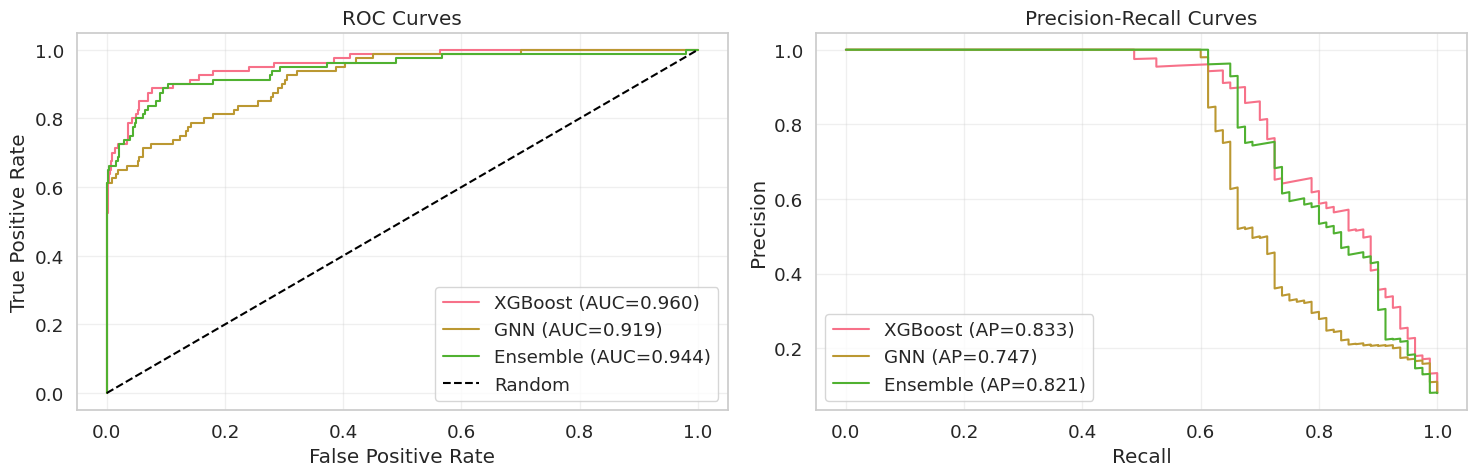

In [ ]:
# ============================================================================
# COMPLETAR df_resultados CON LABELS Y ENSEMBLE
# ============================================================================

# 1. Agregar labels reales (asegurar alineación)
print("="*70)
print("📊 COMPLETANDO df_resultados")
print("="*70)

# Verificar alineación de índices
assert df_resultados.index.equals(X_concat.index), "❌ Índices no coinciden"

# Agregar fraude_label
df_resultados['fraude_label'] = df_fraude.loc[X_concat.index, 'fraude_label']

print(f"\n✅ Labels agregados:")
print(f"   - Total registros: {len(df_resultados)}")
print(f"   - Fraudes (1): {df_resultados['fraude_label'].sum()}")
print(f"   - No fraudes (0): {(df_resultados['fraude_label'] == 0).sum()}")
print(f"   - Ratio fraude: {df_resultados['fraude_label'].mean():.2%}")

# Verificar que no haya NaN
assert not df_resultados.isna().any().any(), "❌ Hay valores NaN"


# 2. Método heurístico de ensemble (20% NLP, 40% GNN, 40% XGB)
print(f"\n🔄 Calculando ensemble heurístico...")

# Score combinado (ponderado)
df_resultados['score_ensemble'] = (
    0.20 * df_resultados['score_conc'] +
    0.40 * df_resultados['score_gnn'] +
    0.40 * df_resultados['xgb_prob_fraude']
)

print(f"✅ Score ensemble calculado:")
print(f"   - Min/Max: {df_resultados['score_ensemble'].min():.4f} / {df_resultados['score_ensemble'].max():.4f}")
print(f"   - Media: {df_resultados['score_ensemble'].mean():.4f}")


# 3. Encontrar threshold óptimo para ensemble
from sklearn.metrics import roc_curve, auc, f1_score, precision_recall_curve

y_true = df_resultados['fraude_label'].values
y_score_ensemble = df_resultados['score_ensemble'].values

# Calcular threshold óptimo usando F1-score
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_true, y_score_ensemble)
f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-10)
optimal_idx = np.argmax(f1_scores[:-1])  # Excluir último valor
threshold_ensemble = thresholds_pr[optimal_idx]

print(f"\n🎯 Threshold óptimo para ensemble: {threshold_ensemble:.4f}")

# Predicción con threshold óptimo
df_resultados['ensemble_prediccion'] = (df_resultados['score_ensemble'] >= threshold_ensemble).astype(int)

print(f"   - Predicciones positivas: {df_resultados['ensemble_prediccion'].sum()}/{len(df_resultados)}")


# 4. MÉTRICAS COMPLETAS
print("\n" + "="*70)
print("📈 EVALUACIÓN DE MODELOS")
print("="*70)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    average_precision_score
)

def evaluar_modelo(y_true, y_pred, y_score, nombre_modelo):
    """
    Evalúa un modelo y retorna métricas completas
    """
    print(f"\n{'='*70}")
    print(f"📊 {nombre_modelo}")
    print(f"{'='*70}")

    # Métricas básicas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # ROC-AUC
    try:
        roc_auc = roc_auc_score(y_true, y_score)
    except:
        roc_auc = np.nan

    # PR-AUC (mejor para datos desbalanceados)
    try:
        pr_auc = average_precision_score(y_true, y_score)
    except:
        pr_auc = np.nan

    print(f"\n📍 Métricas principales:")
    print(f"   Accuracy:       {acc:.4f}")
    print(f"   Precision:      {prec:.4f}")
    print(f"   Recall:         {rec:.4f}")
    print(f"   F1-Score:       {f1:.4f}")
    print(f"   ROC-AUC:        {roc_auc:.4f}")
    print(f"   PR-AUC:         {pr_auc:.4f}")

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n📊 Matriz de Confusión:")
    print(f"   True Negatives:  {tn}")
    print(f"   False Positives: {fp}")
    print(f"   False Negatives: {fn}")
    print(f"   True Positives:  {tp}")

    # Métricas derivadas
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0

    print(f"\n📍 Métricas adicionales:")
    print(f"   Specificity:    {specificity:.4f}")
    print(f"   NPV:            {npv:.4f}")

    # Distribución de predicciones
    print(f"\n📊 Distribución de predicciones:")
    print(f"   Predicciones = 0: {(y_pred == 0).sum()} ({(y_pred == 0).mean():.2%})")
    print(f"   Predicciones = 1: {(y_pred == 1).sum()} ({(y_pred == 1).mean():.2%})")

    # Retornar métricas como dict
    return {
        'Modelo': nombre_modelo,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Specificity': specificity,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp
    }


# Evaluar cada modelo
y_true = df_resultados['fraude_label'].values

metricas = []

# XGBoost
metricas.append(evaluar_modelo(
    y_true,
    df_resultados['xgb_prediccion'].values,
    df_resultados['xgb_prob_fraude'].values,
    "XGBoost"
))

# Ensemble Heurístico
metricas.append(evaluar_modelo(
    y_true,
    df_resultados['ensemble_prediccion'].values,
    df_resultados['score_ensemble'].values,
    "Ensemble Heurístico (20% NLP + 40% GNN + 40% XGB)"
))

# Si quieres evaluar GNN solo (necesitas calcular threshold)
# Calcular threshold para GNN
precision_gnn, recall_gnn, thresholds_gnn = precision_recall_curve(y_true, df_resultados['score_gnn'].values)
f1_gnn = 2 * (precision_gnn * recall_gnn) / (precision_gnn + recall_gnn + 1e-10)
threshold_gnn = thresholds_gnn[np.argmax(f1_gnn[:-1])]
df_resultados['gnn_prediccion'] = (df_resultados['score_gnn'] >= threshold_gnn).astype(int)

metricas.append(evaluar_modelo(
    y_true,
    df_resultados['gnn_prediccion'].values,
    df_resultados['score_gnn'].values,
    f"GNN (threshold={threshold_gnn:.4f})"
))


# 5. TABLA COMPARATIVA
print("\n" + "="*70)
print("📊 COMPARACIÓN DE MODELOS")
print("="*70)

df_metricas = pd.DataFrame(metricas)
print("\n", df_metricas.to_string(index=False))


# 6. VISUALIZACIONES (opcional)
print("\n" + "="*70)
print("📈 GENERANDO VISUALIZACIONES")
print("="*70)

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ROC Curve
ax1 = axes[0]
for modelo_name, y_score_col in [
    ('XGBoost', 'xgb_prob_fraude'),
    ('GNN', 'score_gnn'),
    ('Ensemble', 'score_ensemble')
]:
    fpr, tpr, _ = roc_curve(y_true, df_resultados[y_score_col].values)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f'{modelo_name} (AUC={roc_auc:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Precision-Recall Curve
ax2 = axes[1]
for modelo_name, y_score_col in [
    ('XGBoost', 'xgb_prob_fraude'),
    ('GNN', 'score_gnn'),
    ('Ensemble', 'score_ensemble')
]:
    precision, recall, _ = precision_recall_curve(y_true, df_resultados[y_score_col].values)
    pr_auc = average_precision_score(y_true, df_resultados[y_score_col].values)
    ax2.plot(recall, precision, label=f'{modelo_name} (AP={pr_auc:.3f})')

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=300, bbox_inches='tight')
print("\n✅ Gráficos guardados en: comparacion_modelos.png")

# 7. GUARDAR RESULTADOS
print("\n" + "="*70)
print("💾 GUARDANDO RESULTADOS")
print("="*70)

# Guardar df_resultados completo
df_resultados.to_csv('resultados_predicciones.csv', index=True)
print("✅ Predicciones guardadas en: resultados_predicciones.csv")

# Guardar métricas
df_metricas.to_csv('metricas_comparacion.csv', index=False)
print("✅ Métricas guardadas en: metricas_comparacion.csv")

# Guardar thresholds
thresholds_info = {
    'xgb_threshold': threshold,
    'gnn_threshold': threshold_gnn,
    'ensemble_threshold': threshold_ensemble
}
joblib.dump(thresholds_info, 'thresholds.joblib')
print("✅ Thresholds guardados en: thresholds.joblib")


# 8. RESUMEN FINAL
print("\n" + "="*70)
print("🎯 RESUMEN FINAL")
print("="*70)

print(f"\n📊 Datos procesados:")
print(f"   Total registros: {len(df_resultados)}")
print(f"   Fraudes reales: {y_true.sum()} ({y_true.mean():.2%})")

print(f"\n🏆 Mejor modelo por métrica:")
print(f"   Mejor F1-Score:  {df_metricas.loc[df_metricas['F1-Score'].idxmax(), 'Modelo']} ({df_metricas['F1-Score'].max():.4f})")
print(f"   Mejor ROC-AUC:   {df_metricas.loc[df_metricas['ROC-AUC'].idxmax(), 'Modelo']} ({df_metricas['ROC-AUC'].max():.4f})")
print(f"   Mejor Precision: {df_metricas.loc[df_metricas['Precision'].idxmax(), 'Modelo']} ({df_metricas['Precision'].max():.4f})")
print(f"   Mejor Recall:    {df_metricas.loc[df_metricas['Recall'].idxmax(), 'Modelo']} ({df_metricas['Recall'].max():.4f})")

print("\n✅ ANÁLISIS COMPLETADO")

📊 COMPLETANDO DF_RESULTADOS Y ENSEMBLE

📊 Evaluando: XGBoost

📊 Evaluando: Ensemble Heurístico

📊 Evaluando: GNN (th=0.55)

📈 GENERANDO DASHBOARD DE RESULTADOS

✅ Dashboard guardado como: dashboard_final_fraude.png

🏆 COMPARACIÓN FINAL:
             Modelo  F1-Score  ROC-AUC  Recall
            XGBoost  0.735484 0.959742  0.7125
Ensemble Heurístico  0.776119 0.944266  0.6500
      GNN (th=0.55)  0.753846 0.918614  0.6125


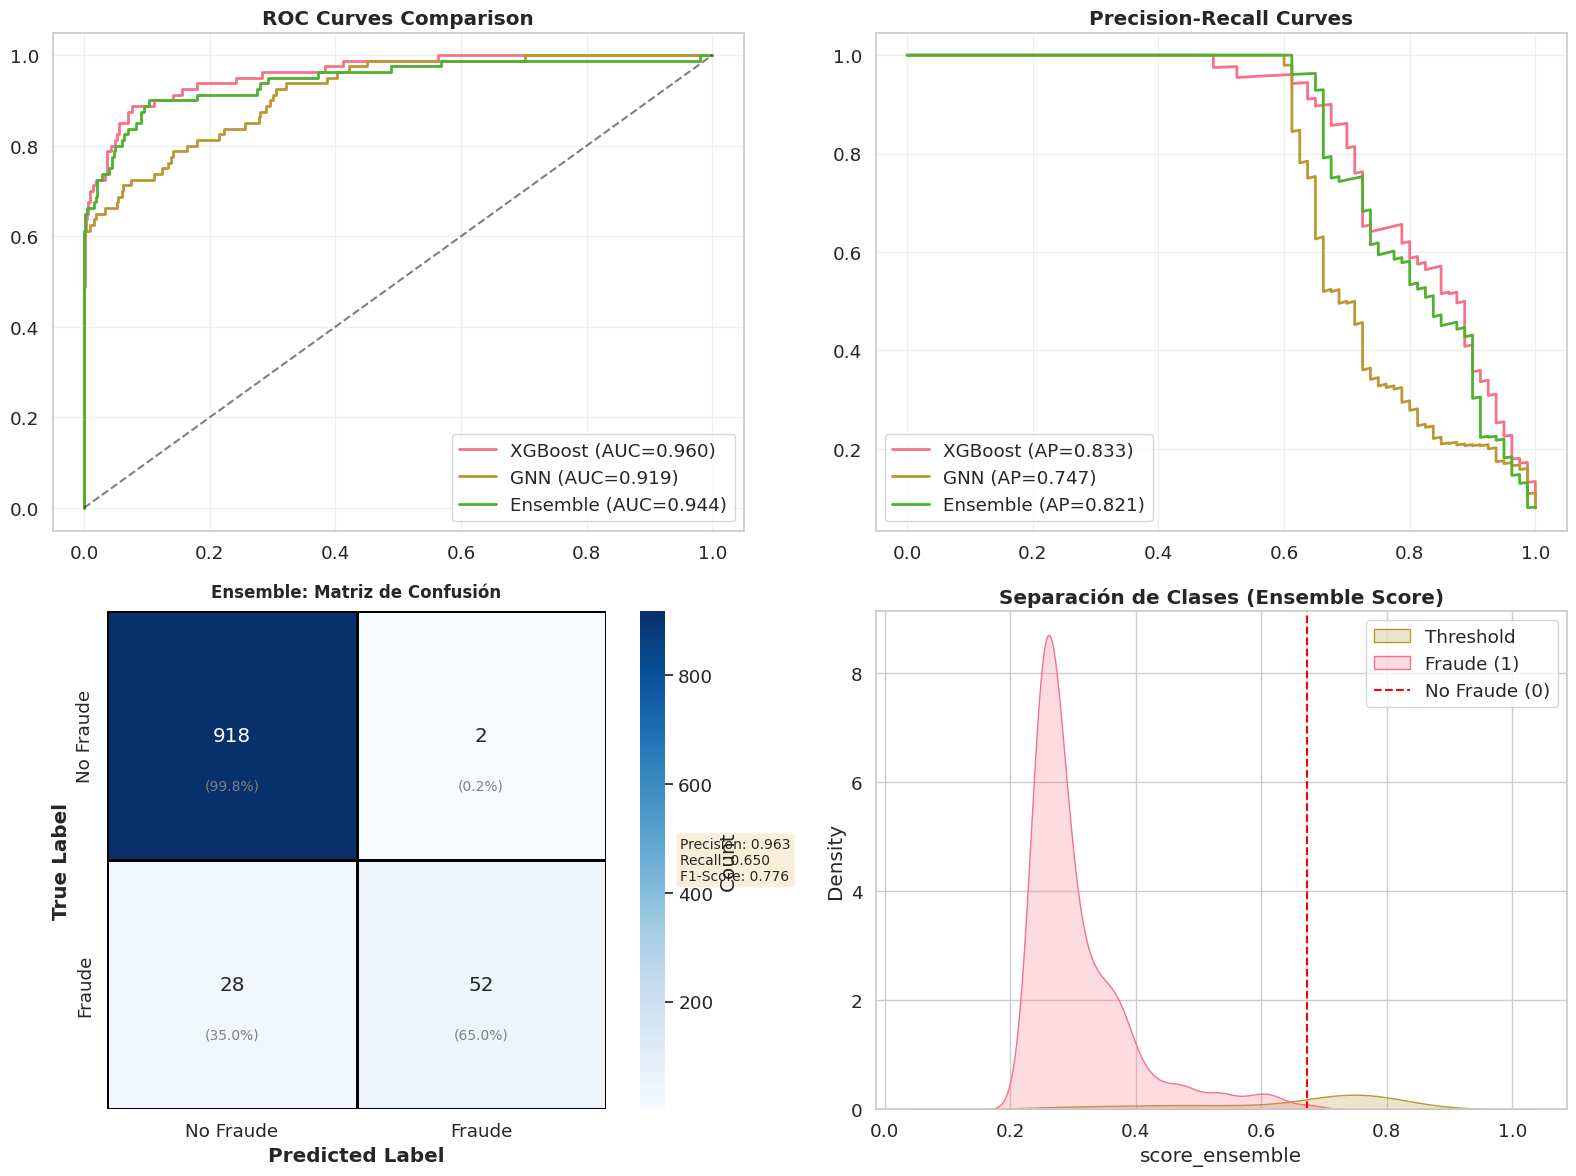

In [ ]:
# ============================================================================
# 1. FUNCIONES DE VISUALIZACIÓN (Tus nuevas rutinas)
# ============================================================================

def plot_confusion_matrix_mejorada(y_true, y_pred, ax, title='Confusion Matrix'):
    """Genera matriz de confusión con porcentajes y métricas"""
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                square=True, linewidths=2, linecolor='black',
                cbar_kws={'label': 'Count'}, ax=ax)

    for i in range(2):
        for j in range(2):
            percentage = cm[i, j] / cm[i, :].sum() * 100
            ax.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)',
                   ha='center', va='center', fontsize=10, color='gray')

    ax.set_xlabel('Predicted Label', fontweight='bold')
    ax.set_ylabel('True Label', fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=12, pad=10)
    ax.set_xticklabels(['No Fraude', 'Fraude'])
    ax.set_yticklabels(['No Fraude', 'Fraude'])

    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    metrics_text = f'Precision: {precision:.3f}\nRecall: {recall:.3f}\nF1-Score: {f1:.3f}'
    ax.text(1.15, 0.5, metrics_text, transform=ax.transAxes,
           fontsize=10, verticalalignment='center',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

def evaluar_modelo(y_true, y_pred, y_score, nombre_modelo):
    """Evalúa un modelo y retorna métricas completas"""
    print(f"\n📊 Evaluando: {nombre_modelo}")
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {
        'Modelo': nombre_modelo, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': roc_auc, 'PR-AUC': pr_auc,
        'Specificity': specificity, 'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    }

# ============================================================================
# 2. PROCESAMIENTO Y ENSEMBLE (Lógica original de prueba.py)
# ============================================================================
print("="*70)
print("📊 COMPLETANDO DF_RESULTADOS Y ENSEMBLE")
print("="*70)

# Alineación de etiquetas
assert df_resultados.index.equals(X_concat.index), "❌ Índices no coinciden"
df_resultados['fraude_label'] = df_fraude.loc[X_concat.index, 'fraude_label']

# Cálculo del Ensemble Heurístico
df_resultados['score_ensemble'] = (
    0.20 * df_resultados['score_conc'] +
    0.40 * df_resultados['score_gnn'] +
    0.40 * df_resultados['xgb_prob_fraude']
)

# Búsqueda de Threshold óptimo (F1-Score)
y_true = df_resultados['fraude_label'].values
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_true, df_resultados['score_ensemble'].values)
f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-10)
threshold_ensemble = thresholds_pr[np.argmax(f1_scores[:-1])]
df_resultados['ensemble_prediccion'] = (df_resultados['score_ensemble'] >= threshold_ensemble).astype(int)

# Umbral para GNN independiente
precision_gnn, recall_gnn, thresholds_gnn = precision_recall_curve(y_true, df_resultados['score_gnn'].values)
f1_gnn = 2 * (precision_gnn * recall_gnn) / (precision_gnn + recall_gnn + 1e-10)
threshold_gnn = thresholds_gnn[np.argmax(f1_gnn[:-1])]
df_resultados['gnn_prediccion'] = (df_resultados['score_gnn'] >= threshold_gnn).astype(int)

# ============================================================================
# 3. GENERACIÓN DE MÉTRICAS Y TABLAS
# ============================================================================
metricas = []
metricas.append(evaluar_modelo(y_true, df_resultados['xgb_prediccion'], df_resultados['xgb_prob_fraude'], "XGBoost"))
metricas.append(evaluar_modelo(y_true, df_resultados['ensemble_prediccion'], df_resultados['score_ensemble'], "Ensemble Heurístico"))
metricas.append(evaluar_modelo(y_true, df_resultados['gnn_prediccion'], df_resultados['score_gnn'], f"GNN (th={threshold_gnn:.2f})"))

df_metricas = pd.DataFrame(metricas)

# ============================================================================
# 4. DASHBOARD VISUAL (Consolidado)
# ============================================================================
print("\n" + "="*70)
print("📈 GENERANDO DASHBOARD DE RESULTADOS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: ROC Curves Comparison
ax1 = axes[0, 0]
for mod, col in [('XGBoost', 'xgb_prob_fraude'), ('GNN', 'score_gnn'), ('Ensemble', 'score_ensemble')]:
    fpr, tpr, _ = roc_curve(y_true, df_resultados[col])
    ax1.plot(fpr, tpr, label=f'{mod} (AUC={auc(fpr, tpr):.3f})', lw=2)
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_title('ROC Curves Comparison', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Precision-Recall Curves
ax2 = axes[0, 1]
for mod, col in [('XGBoost', 'xgb_prob_fraude'), ('GNN', 'score_gnn'), ('Ensemble', 'score_ensemble')]:
    p, r, _ = precision_recall_curve(y_true, df_resultados[col])
    ax2.plot(r, p, label=f'{mod} (AP={average_precision_score(y_true, df_resultados[col]):.3f})', lw=2)
ax2.set_title('Precision-Recall Curves', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Subplot 3: Matriz de Confusión Mejorada (Tu nueva función)
plot_confusion_matrix_mejorada(y_true, df_resultados['ensemble_prediccion'], axes[1, 0], title='Ensemble: Matriz de Confusión')

# Subplot 4: Distribución de Scores (Análisis de Gap/Separación)
ax4 = axes[1, 1]
sns.kdeplot(data=df_resultados, x='score_ensemble', hue='fraude_label', fill=True, ax=ax4)
ax4.axvline(threshold_ensemble, color='red', linestyle='--', label=f'Threshold: {threshold_ensemble:.2f}')
ax4.set_title('Separación de Clases (Ensemble Score)', fontweight='bold')
ax4.legend(['Threshold', 'Fraude (1)', 'No Fraude (0)'])

plt.tight_layout()
plt.savefig('dashboard_final_fraude.png', dpi=300)
print("\n✅ Dashboard guardado como: dashboard_final_fraude.png")

# ============================================================================
# 5. GUARDADO DE RESULTADOS
# ============================================================================
df_resultados.to_csv('resultados_predicciones.csv', index=True)
df_metricas.to_csv('metricas_comparacion.csv', index=False)

print("\n🏆 COMPARACIÓN FINAL:")
print(df_metricas[['Modelo', 'F1-Score', 'ROC-AUC', 'Recall']].to_string(index=False))

## Stacking (Stacked Generalization)

In [ ]:
# Creamos la matriz de "opiniones" de los modelos
X_meta = df_resultados[['score_conc', 'score_gnn', 'xgb_prob_fraude']]
y_meta = df_resultados['fraude_label']

# Entrenamos un "Juez" (Regresión Logística)
meta_model = LogisticRegression(class_weight='balanced')
meta_model.fit(X_meta, y_meta)

# Ahora el score_ensemble es una predicción inteligente del Juez
df_resultados['score_ensemble'] = meta_model.predict_proba(X_meta)[:, 1]

# Ver los pesos que el "Juez" le asignó a cada uno automáticamente
importancia = meta_model.coef_[0]
print("\n🤖 Pesos asignados por el Meta-Modelo (Stacking):")
print(f"Peso NLP: {importancia[0]:.4f}")
print(f"Peso GNN: {importancia[1]:.4f}")
print(f"Peso XGB: {importancia[2]:.4f}")


🤖 Pesos asignados por el Meta-Modelo (Stacking):
Peso NLP: -0.5979
Peso GNN: 0.7594
Peso XGB: 6.4676


## Mejorado Out-of-Fold (OOF)

In [ ]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Definimos la validación cruzada para que el "Juez" no vea datos viciados
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Escalamos los scores para que todos tengan el mismo peso visual inicial
scaler = StandardScaler()
X_meta_scaled = scaler.fit_transform(X_meta)

# 3. Entrenamos el Meta-Modelo (Juez)
# Usamos 'liblinear' o 'lbfgs' y mantenemos class_weight para el desbalance
meta_model = LogisticRegression(class_weight='balanced', C=1.0)

# El entrenamiento real debería hacerse con predicciones OOF,
# pero para obtener los pesos finales usamos el fit estándar:
meta_model.fit(X_meta_scaled, y_meta)

# 4. Extraer pesos normalizados (Importancia Relativa)
importancia = meta_model.coef_[0]
# Calculamos un porcentaje de influencia para que sea más legible
total = sum(abs(importancia))
pesos_relativos = (importancia / total) * 100

print("--- ⚖️ Análisis del Juez (Stacking) ---")
modelos = ['NLP (Conc)', 'GNN', 'XGBoost']
for i, modelo in enumerate(modelos):
    print(f"Confianza en {modelo}: {pesos_relativos[i]:.2f}%")

## Bayesiano

In [ ]:
# Definimos la función de Score Dinámico
def calcular_score_dinamico(df, w_nlp, w_gnn, w_xgb):
    # Aplicamos tu lógica: NLP solo aporta si es > 0
    # De lo contrario, su peso se redistribuye o es 0
    score = (w_gnn * df['score_gnn'] + w_xgb * df['xgb_prob_fraude'])

    # Solo sumamos NLP si supera el umbral que definas (ej. 0.1)
    mask = df['score_conc'] > 0.1
    score.loc[mask] += w_nlp * df.loc[mask, 'score_conc']

    return score

# Ejemplo de lógica para encontrar pesos con Optimización Bayesiana (usando Optuna)

def objective(trial):
    # El optimizador propone pesos
    w_nlp = trial.suggest_float('w_nlp', 0.0, 0.3)
    w_gnn = trial.suggest_float('w_gnn', 0.0, 0.5)
    w_xgb = trial.suggest_float('w_xgb', 0.4, 1.0) # XGB suele ser el más fuerte

    # Normalizar para que sumen 1
    total = w_nlp + w_gnn + w_xgb
    w_nlp, w_gnn, w_xgb = w_nlp/total, w_gnn/total, w_xgb/total

    y_score = calcular_score_dinamico(df_resultados, w_nlp, w_gnn, w_xgb)
    return average_precision_score(y_true, y_score)

# Ejecutar la búsqueda
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Mejores pesos para este cliente: {study.best_params}")

[I 2026-02-01 15:08:24,974] A new study created in memory with name: no-name-8c77fb66-51d7-48a1-a924-b8bbdb83ae6f
[I 2026-02-01 15:08:24,990] Trial 0 finished with value: 0.831641334943828 and parameters: {'w_nlp': 0.07059558509372178, 'w_gnn': 0.1113901263136039, 'w_xgb': 0.45747574664090135}. Best is trial 0 with value: 0.831641334943828.
[I 2026-02-01 15:08:24,994] Trial 1 finished with value: 0.8280224725474097 and parameters: {'w_nlp': 0.17744715465498276, 'w_gnn': 0.2897137885004659, 'w_xgb': 0.6208230998149913}. Best is trial 0 with value: 0.831641334943828.
[I 2026-02-01 15:08:24,998] Trial 2 finished with value: 0.8273996753835576 and parameters: {'w_nlp': 0.252755348005382, 'w_gnn': 0.08494209228117583, 'w_xgb': 0.8173172581467654}. Best is trial 0 with value: 0.831641334943828.
[I 2026-02-01 15:08:25,005] Trial 3 finished with value: 0.8232642237887019 and parameters: {'w_nlp': 0.2741241651706684, 'w_gnn': 0.23488228144983014, 'w_xgb': 0.6145744299820006}. Best is trial 0 wi

Mejores pesos para este cliente: {'w_nlp': 0.025414604959464356, 'w_gnn': 0.1418106766240019, 'w_xgb': 0.7606638039135843}


In [ ]:

# ============================================================================
# PARA PRODUCCIÓN (datos nuevos) GNN
# ============================================================================

def pipeline_prediccion_produccion(df_new):
    """
    Pipeline completo para predecir fraude en datos nuevos.
    """
    # Preparar features
    X_new = preparar_features(df_new)  # Tu función de preparación

    df_pred = pd.DataFrame(index=df_new.index)

    # 1. Score semántico
    detector = FraudSemanticDetector.from_export('modelo_fraude_final')
    df_pred['score_conc'] = detector.calculate_semantic_score(df_new['descripcion'])

    # 2. GNN
    df_pred['score_gnn'] = predecir_gnn_datos_nuevos(df_new)

    # 3. XGBoost
    pred = joblib.load('modelos/modelo_fraude_pipeline_xg.pkl')
    threshold = joblib.load('modelos/optimal_threshold.pkl')
    df_pred['xgb_prob_fraude'] = pred.predict_proba(X_new)[:, 1]
    df_pred['xgb_prediccion'] = (df_pred['xgb_prob_fraude'] >= threshold).astype(int)

    # 4. Predicción final combinada (opcional: ensemble)
    # Puedes combinar los 3 scores como prefieras
    df_pred['score_combinado'] = (
        0.3 * df_pred['score_conc'] +
        0.3 * df_pred['score_gnn'] +
        0.4 * df_pred['xgb_prob_fraude']
    )
    df_pred['prediccion_final'] = (df_pred['score_combinado'] >= 0.5).astype(int)

    return df_pred


# Uso
df_nuevos_reclamos = pd.read_csv('nuevos_reclamos.csv')
predicciones = pipeline_prediccion_produccion(df_nuevos_reclamos)
print(predicciones)
``

In [ ]:
# Verificar estructura del grafo
data = torch.load('Modelos_gnn/data_gnn.pt', map_location='cpu', weights_only=False)
print(f"Nodos 'reclamo' en el grafo: {data['reclamo'].x.shape[0]}")
print(f"Features por nodo: {data['reclamo'].x.shape[1]}")
print(f"Filas en X_concat: {len(X_concat)}")
print(f"Edge types: {list(data.edge_index_dict.keys())}")

Nodos 'reclamo' en el grafo: 1000
Features por nodo: 4
Filas en X_concat: 1000
Edge types: [('reclamo', 'pertenece_a', 'paciente'), ('reclamo', 'atendido_por', 'doctor'), ('reclamo', 'tiene_diagnostico', 'cie'), ('reclamo', 'tiene_procedimiento', 'cpt'), ('paciente', 'rev_pertenece_a', 'reclamo'), ('doctor', 'rev_atendido_por', 'reclamo'), ('cie', 'rev_tiene_diagnostico', 'reclamo'), ('cpt', 'rev_tiene_procedimiento', 'reclamo')]


In [ ]:
# --------------- OJO : REVISAR PARA MEJORAR XGBOOST------------
"""
# --- EN EL SCRIPT DEL GNN ---
def guardar_resultados_gnn(self, df_original, path="data/interim/gnn_features.parquet"):
    self.modelo_gnn.eval()
    with torch.no_grad():
        out = self.modelo_gnn(self.grafo_data.x_dict, self.grafo_data.edge_index_dict)
        probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()

        # Creamos un DF pequeño de mapeo: ID -> SCORE
        # Es vital usar el ID único del reclamo, no el índice de la fila
        df_scores = pd.DataFrame({
            'id_reclamo': df_original['id_reclamo'],
            'score_gnn': probs
        })

        df_scores.to_parquet(path)

# --- EN EL SCRIPT DEL XGBOOST FINAL ---
def entrenar_xgboost_final(df_fraude):
    # Cargamos el "conocimiento" del GNN
    df_gnn = pd.read_parquet("data/interim/gnn_features.parquet")

    # Unimos por ID para asegurar que cada score caiga donde corresponde
    df_final = df_fraude.merge(df_gnn, on='id_reclamo', how='left')

    NOTA : # Usando el índice como ID si no tienes una columna de Folio
    df_gnn_output = pd.DataFrame({
    'id_original': df_original.index,
    'score_gnn': prob_fraude_col
})




import pandas as pd

# Supongamos que tienes los IDs de los nodos y sus probabilidades
df_gnn = pd.DataFrame({
    'node_id': node_indices,
    'score_gnn': gnn_probabilities
})

# Guardar en la carpeta de modelos
df_gnn.to_parquet('modelos/score_gnn.parquet', index=False)


import pandas as pd
import os

path_gnn = 'modelos/score_gnn.parquet'

if os.path.exists(path_gnn):
    df_gnn_scores = pd.read_parquet(path_gnn)
    # Hacer un merge con tu dataframe principal para asegurar que los IDs coincidan
    df_final = df_original.merge(df_gnn_scores, on='node_id', how='left')
else:
    # Si no existe, creamos la columna con un valor neutro (Cold Start)
    print("Aviso: No se encontró score_gnn. Iniciando con valores base.")
    df_final = df_original.copy()
    df_final['score_gnn'] = 0.5  # O el promedio de tu target
"""

'\n# --- EN EL SCRIPT DEL GNN ---\ndef guardar_resultados_gnn(self, df_original, path="data/interim/gnn_features.parquet"):\n    self.modelo_gnn.eval()\n    with torch.no_grad():\n        out = self.modelo_gnn(self.grafo_data.x_dict, self.grafo_data.edge_index_dict)\n        probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()\n\n        # Creamos un DF pequeño de mapeo: ID -> SCORE\n        # Es vital usar el ID único del reclamo, no el índice de la fila\n        df_scores = pd.DataFrame({\n            \'id_reclamo\': df_original[\'id_reclamo\'],\n            \'score_gnn\': probs\n        })\n\n        df_scores.to_parquet(path)\n\n# --- EN EL SCRIPT DEL XGBOOST FINAL ---\ndef entrenar_xgboost_final(df_fraude):\n    # Cargamos el "conocimiento" del GNN\n    df_gnn = pd.read_parquet("data/interim/gnn_features.parquet")\n\n    # Unimos por ID para asegurar que cada score caiga donde corresponde\n    df_final = df_fraude.merge(df_gnn, on=\'id_reclamo\', how=\'left\')\n\n    NOTA : # Usando 

In [ ]:
"""
# --- NUEVO BLOQUE: EXTRACCIÓN DE SCORES PARA XGBOOST ---
    modelo.eval()
    with torch.no_grad():
        # Obtenemos las probabilidades de TODOS los nodos del grafo
        logits = modelo(data.x_dict, data.edge_index_dict)
        probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy() # Probabilidad de la clase 1 (Fraude)

    # Creamos el DataFrame df_gnn
    # Usamos el índice de df_fraude para asegurar alineación perfecta
    df_gnn = pd.DataFrame(probs, index=df_fraude.index, columns=['score_gnn'])

    print(f"✅ df_gnn creado exitosamente. Tamaño: {df_gnn.shape}")
    # -------------------------------------------------------
    """

'\n# --- NUEVO BLOQUE: EXTRACCIÓN DE SCORES PARA XGBOOST ---\n    modelo.eval()\n    with torch.no_grad():\n        # Obtenemos las probabilidades de TODOS los nodos del grafo\n        logits = modelo(data.x_dict, data.edge_index_dict)\n        probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy() # Probabilidad de la clase 1 (Fraude)\n\n    # Creamos el DataFrame df_gnn\n    # Usamos el índice de df_fraude para asegurar alineación perfecta\n    df_gnn = pd.DataFrame(probs, index=df_fraude.index, columns=[\'score_gnn\'])\n\n    print(f"✅ df_gnn creado exitosamente. Tamaño: {df_gnn.shape}")\n    # -------------------------------------------------------\n    '